## ANOMALY DETECTION DURING THE OPERATION OF A BUCKET ELEVATOR IN A CEMENT MILL

METHODOLOGY:

1.PROBLEM DEFINITION
2.DATA
3.EVALUATION
4.FEATURES
5.MODELLING
6.EXPERIMENT

### 1.PROBLEM DEFINITION
This dataset contains a 1-minutes kilowatt(KM) energy reading of a bucket elevators (BE01 and BE02) of cement mill 3 logged over 4 hours dated from (04 May 2026, 11:08-15:07) accounting to 240 rows in total

### 2.Data
The data originated from Cement Mill 3 at Lafarge Cement Mfamosing Plant

### 3.Evaluation
90-95% accuracy of predicting anomaly in the operation of the bucket elevator

### 4.Features
After successfully carried an EDA(Exploratory Data Analysis) on the dataset it has been concluded that we have four(4) different column in the dataset representing the energy reading(KW) OF four(4) different drive attached to a bucket elevator (BE) at cement mill 3 located in Lafarge Mfamosing plant each of this drive is as stated below with their unique identification tag

> MFA.362-BE01.J01:PV_AVG  (Set_Point value: 24kW)

> MFA.563-BE01.J01:PV_AVG  (Set_Point value: 40kW)

> MFA.563-BE02.J01:PV_AVG  (Set_Point value: 81kW)

> MFA.563-BE02.J02:PV_AVG  (Set_Point value: 90kW)

In [1]:
# Importing all the tools we need 
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats
from scipy.stats import zscore

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import shap

from datetime import datetime, timedelta
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.4f" % x)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (16, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 11

import sklearn
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"SHAP        : {shap.__version__}")

NumPy       : 2.3.5
Pandas      : 2.3.3
Scikit-learn: 1.7.2
SHAP        : 0.51.0


In [2]:
# Loading Dataset 
cement_mill = pd.read_csv("Data/Trend_3.Cement_Mill_3_Trend.csv")
cement_mill.head()

,Sample Location:,,.1,.2,.3,.4
0,Sort:,,,,,
1,NaN,MFA.362-BE01.J01:PV_AVG,MFA.563-BE01.J01:PV_AVG,MFA.563-BE02.J01:PV_AVG,MFA.563-BE02.J02:PV_AVG,NaN
2,04.05.2026 11:08:00,15.3600006103516,39.9360008239746,69.3760070800781,80.3840026855469,
3,04.05.2026 11:09:00,15.3600006103516,40.7040023803711,64.7680053710938,73.2160034179688,
4,04.05.2026 11:10:00,14.1740007400513,39.4240036010742,73.984001159668,83.7120056152344,


In [3]:
# Loading and describing the dataset

cement_mill = pd.read_csv("Data/Trend_3.Cement_Mill_3_Trend.csv", header=None, skiprows=3)
print("Dataset loaded successfully.")
print(f"Shape: {cement_mill.shape}")
print(f"\nColumn names:\n{cement_mill.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(f"\nLast 5 rows:")
display(cement_mill.head())
display(cement_mill.tail())
print(f"\nData types:")
print(cement_mill.dtypes)
print(f"\nMissing values:")
print(cement_mill.isnull().sum())

Dataset loaded successfully.
Shape: (240, 6)

Column names:
[0, 1, 2, 3, 4, 5]

First 5 rows:

Last 5 rows:


,0,1,2,3,4,5
0,04.05.2026 11:08:00,15.3600006103516,39.9360008239746,69.3760070800781,80.3840026855469,
1,04.05.2026 11:09:00,15.3600006103516,40.7040023803711,64.7680053710938,73.2160034179688,
2,04.05.2026 11:10:00,14.1740007400513,39.4240036010742,73.984001159668,83.7120056152344,
3,04.05.2026 11:11:00,12.3640003204346,39.9360008239746,73.984001159668,86.0160064697266,
4,04.05.2026 11:12:00,13.7440004348755,39.9360008239746,71.9360046386719,82.4320068359375,


,0,1,2,3,4,5
235,04.05.2026 15:03:00,17.9200000762939,39.9360008239746,70.4000015258789,80.3840026855469,
236,04.05.2026 15:04:00,16.3840007781982,39.1680030822754,76.8000030517578,88.3200073242188,
237,04.05.2026 15:05:00,9.95700073242188,39.1680030822754,72.9600067138672,85.5040054321289,
238,04.05.2026 15:06:00,8.70100021362305,39.4240036010742,68.6080017089844,74.2400054931641,
239,04.05.2026 15:07:00,6.97600030899048,38.6560020446777,71.6800003051758,84.224006652832,



Data types:
0    object
1    object
2    object
3    object
4    object
5    object
dtype: object

Missing values:
0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [5]:
# laoding and renaming of the dataset

cement_mill_raw = pd.read_csv("Data/Trend_3.Cement_Mill_3_Trend.csv", skiprows=2)

column_mapping = {
    cement_mill_raw.columns[0]: 'Timestamp',
    cement_mill_raw.columns[1]: 'Motor_1_MFA362_BE01_J01',
    cement_mill_raw.columns[2]: 'Motor_2_MFA563_BE01_J01',
    cement_mill_raw.columns[3]: 'Motor_3_MFA563_BE02_J01',
    cement_mill_raw.columns[4]: 'Motor_4_MFA563_BE02_J02'
}
cement_mill = cement_mill_raw.rename(columns=column_mapping)

if cement_mill.shape[1] == 6:
    cement_mill = cement_mill.iloc[:, :5]

# converting Timestrap to datetime datatype

cement_mill["Timestamp"] = pd.to_datetime(cement_mill['Timestamp'], format='%d.%m.%Y %H:%M:%S', errors='coerce')

motor_cols = ['Motor_1_MFA362_BE01_J01', 'Motor_2_MFA563_BE01_J01', 
              'Motor_3_MFA563_BE02_J01', 'Motor_4_MFA563_BE02_J02']

for col in motor_cols:
    cement_mill[col] = pd.to_numeric(cement_mill[col], errors='coerce')


print(f"Cleaned dataset shape: {cement_mill.shape}")
print(f"\nData types after conversion:")
print(cement_mill.dtypes)
print(f"\nMissing values after conversion:")
print(cement_mill.isnull().sum())
print(f"\nFirst 10 rows:")
display(cement_mill.head(10))
print(f"\nLast 10 rows:")
display(cement_mill.tail(10))
print(f"\nBasic statistics:")
display(cement_mill.describe())

Cleaned dataset shape: (240, 5)

Data types after conversion:
Timestamp                  datetime64[ns]
Motor_1_MFA362_BE01_J01           float64
Motor_2_MFA563_BE01_J01           float64
Motor_3_MFA563_BE02_J01           float64
Motor_4_MFA563_BE02_J02           float64
dtype: object

Missing values after conversion:
Timestamp                   0
Motor_1_MFA362_BE01_J01    16
Motor_2_MFA563_BE01_J01     1
Motor_3_MFA563_BE02_J01     1
Motor_4_MFA563_BE02_J02     1
dtype: int64

First 10 rows:


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
0,2026-05-04 11:08:00,15.3600,39.9360,69.3760,80.3840
1,2026-05-04 11:09:00,15.3600,40.7040,64.7680,73.2160
2,2026-05-04 11:10:00,14.1740,39.4240,73.9840,83.7120
3,2026-05-04 11:11:00,12.3640,39.9360,73.9840,86.0160
4,2026-05-04 11:12:00,13.7440,39.9360,71.9360,82.4320
5,2026-05-04 11:13:00,14.2120,39.4240,67.3280,75.2640
6,2026-05-04 11:14:00,11.8210,39.4240,72.9600,83.7120
7,2026-05-04 11:15:00,12.1320,37.8880,71.9360,82.4320
8,2026-05-04 11:16:00,13.4230,38.1440,70.1440,80.3840
9,2026-05-04 11:17:00,11.2600,38.9120,60.4160,67.5840



Last 10 rows:


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
230,2026-05-04 14:58:00,15.2200,37.8880,73.4720,82.4320
231,2026-05-04 14:59:00,13.9870,39.6800,74.4960,86.0160
232,2026-05-04 15:00:00,10.1720,NaN,NaN,NaN
233,2026-05-04 15:01:00,10.0410,39.4240,70.1440,80.8960
234,2026-05-04 15:02:00,11.3840,37.8880,62.7200,69.8880
235,2026-05-04 15:03:00,17.9200,39.9360,70.4000,80.3840
236,2026-05-04 15:04:00,16.3840,39.1680,76.8000,88.3200
237,2026-05-04 15:05:00,9.9570,39.1680,72.9600,85.5040
238,2026-05-04 15:06:00,8.7010,39.4240,68.6080,74.2400
239,2026-05-04 15:07:00,6.9760,38.6560,71.6800,84.2240



Basic statistics:


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
count,240,224.0000,239.0000,239.0000,239.0000
mean,2026-05-04 13:07:30,13.8876,36.6776,64.2914,73.2021
min,2026-05-04 11:08:00,0.0000,8.1920,33.2800,38.4000
25%,2026-05-04 12:07:45,12.3640,37.3760,59.9040,67.8400
50%,2026-05-04 13:07:30,14.1740,38.4000,65.0240,73.2160
75%,2026-05-04 14:07:15,15.3600,39.1680,70.1440,80.3840
max,2026-05-04 15:07:00,24.0640,41.7280,84.9920,101.6320
std,NaN,2.9759,6.7267,9.6886,11.4892


In [7]:
# Setting the motor configuration using a dictionary

motor_config = {
    'Motor_1_MFA362_BE01_J01': {
        'rated_power_kw': 24,
        'zone': 'MFA.362',
        'equipment': 'BE01',
        'drive': 'J01',
        'description': 'Bucket Elevator 01 - Drive 01 - Zone 362'
    },
    'Motor_2_MFA563_BE01_J01': {
        'rated_power_kw': 40,
        'zone': 'MFA.563',
        'equipment': 'BE01',
        'drive': 'J01',
        'description': 'Bucket Elevator 01 - Drive 01 - Zone 563'
    },
    'Motor_3_MFA563_BE02_J01': {
        'rated_power_kw': 81,
        'zone': 'MFA.563',
        'equipment': 'BE02',
        'drive': 'J01',
        'description': 'Bucket Elevator 02 - Drive 01 - Zone 563'
    },
    'Motor_4_MFA563_BE02_J02': {
        'rated_power_kw': 90,
        'zone': 'MFA.563',
        'equipment': 'BE02',
        'drive': 'J02',
        'description': 'Bucket Elevator 02 - Drive 02 - Zone 563'
    }
}

# Setting threshold percentage configuration

threshold_config = {
    'critical_underload_pct': 20,
    'low_load_warning_pct': 40,
    'normal_min_pct': 40,
    'normal_max_pct': 95,
    'high_load_warning_pct': 95,
    'overload_alert_pct': 100,
    'critical_overload_pct': 105
}

motor_cols = list(motor_config.keys())
rated_powers = {k: v['rated_power_kw'] for k, v in motor_config.items()}

print("Motor Configuration:")
for motor, config in motor_config.items():
    print(f"\n{motor}")
    print(f"  Rated Power : {config['rated_power_kw']} kW")
    print(f"  Description : {config['description']}")

print(f"\n\nThreshold Configuration:")
for key, val in threshold_config.items():
    print(f"  {key:30s}: {val}%")

print(f"\n\nDataset Time Range:")
print(f"  Start: {cement_mill['Timestamp'].min()}")
print(f"  End  : {cement_mill['Timestamp'].max()}")
print(f"  Duration: {cement_mill['Timestamp'].max() - cement_mill['Timestamp'].min()}")
print(f"  Total Records: {len(cement_mill)}")

Motor Configuration:

Motor_1_MFA362_BE01_J01
  Rated Power : 24 kW
  Description : Bucket Elevator 01 - Drive 01 - Zone 362

Motor_2_MFA563_BE01_J01
  Rated Power : 40 kW
  Description : Bucket Elevator 01 - Drive 01 - Zone 563

Motor_3_MFA563_BE02_J01
  Rated Power : 81 kW
  Description : Bucket Elevator 02 - Drive 01 - Zone 563

Motor_4_MFA563_BE02_J02
  Rated Power : 90 kW
  Description : Bucket Elevator 02 - Drive 02 - Zone 563


Threshold Configuration:
  critical_underload_pct        : 20%
  low_load_warning_pct          : 40%
  normal_min_pct                : 40%
  normal_max_pct                : 95%
  high_load_warning_pct         : 95%
  overload_alert_pct            : 100%
  critical_overload_pct         : 105%


Dataset Time Range:
  Start: 2026-05-04 11:08:00
  End  : 2026-05-04 15:07:00
  Duration: 0 days 03:59:00
  Total Records: 240


In [8]:
# Feature engineering and load factor status classification

cement_mill_features = cement_mill.copy()

for motor in motor_cols:
    rated_power = rated_powers[motor]
    
    cement_mill_features[f'{motor}_LoadFactor'] = (cement_mill_features[motor] / rated_power) * 100
    
    cement_mill_features[f'{motor}_Status'] = 'NORMAL'
    
    cement_mill_features.loc[cement_mill_features[motor].isna(), f'{motor}_Status'] = 'SENSOR_DROPOUT'
    
    cement_mill_features.loc[cement_mill_features[motor] == 0, f'{motor}_Status'] = 'MOTOR_STOPPED'
    
    cement_mill_features.loc[
        (cement_mill_features[f'{motor}_LoadFactor'] > 0) & 
        (cement_mill_features[f'{motor}_LoadFactor'] < threshold_config['critical_underload_pct']), 
        f'{motor}_Status'
    ] = 'CRITICAL_UNDERLOAD'
    
    cement_mill_features.loc[
        (cement_mill_features[f'{motor}_LoadFactor'] >= threshold_config['critical_underload_pct']) & 
        (cement_mill_features[f'{motor}_LoadFactor'] < threshold_config['low_load_warning_pct']), 
        f'{motor}_Status'
    ] = 'LOW_LOAD_WARNING'
    
    cement_mill_features.loc[
        (cement_mill_features[f'{motor}_LoadFactor'] >= threshold_config['high_load_warning_pct']) & 
        (cement_mill_features[f'{motor}_LoadFactor'] <= threshold_config['overload_alert_pct']), 
        f'{motor}_Status'
    ] = 'HIGH_LOAD_WARNING'
    
    cement_mill_features.loc[
        (cement_mill_features[f'{motor}_LoadFactor'] > threshold_config['overload_alert_pct']) & 
        (cement_mill_features[f'{motor}_LoadFactor'] <= threshold_config['critical_overload_pct']), 
        f'{motor}_Status'
    ] = 'OVERLOAD_ALERT'
    
    cement_mill_features.loc[
        cement_mill_features[f'{motor}_LoadFactor'] > threshold_config['critical_overload_pct'], 
        f'{motor}_Status'
    ] = 'CRITICAL_OVERLOAD'

print("Feature Engineering Complete: Load Factor and Status Classification")
print(f"\nNew columns added: {len(cement_mill_features.columns) - len(cement_mill.columns)}")
print(f"Total columns now: {len(cement_mill_features.columns)}")

print("\n\nStatus Distribution by Motor:")
for motor in motor_cols:
    print(f"\n{motor}:")
    status_counts = cement_mill_features[f'{motor}_Status'].value_counts()
    for status, count in status_counts.items():
        pct = (count / len(cement_mill_features)) * 100
        print(f"  {status:25s}: {count:3d} ({pct:5.2f}%)")

print("\n\nLoad Factor Statistics by Motor:")
load_factor_cols = [f'{motor}_LoadFactor' for motor in motor_cols]
display(cement_mill_features[load_factor_cols].describe())

print("\n\nSample of Feature Engineering Output (rows with anomalies):")
anomaly_mask = cement_mill_features[[f'{motor}_Status' for motor in motor_cols]].apply(
    lambda row: any(status != 'NORMAL' for status in row), axis=1
)
display(cement_mill_features[anomaly_mask].head(20))

Feature Engineering Complete: Load Factor and Status Classification

New columns added: 8
Total columns now: 13


Status Distribution by Motor:

Motor_1_MFA362_BE01_J01:
  NORMAL                   : 216 (90.00%)
  SENSOR_DROPOUT           :  16 ( 6.67%)
  MOTOR_STOPPED            :   3 ( 1.25%)
  OVERLOAD_ALERT           :   1 ( 0.42%)

Motor_2_MFA563_BE01_J01:
  NORMAL                   :  89 (37.08%)
  OVERLOAD_ALERT           :  17 ( 7.08%)
  SENSOR_DROPOUT           :   1 ( 0.42%)

Motor_3_MFA563_BE02_J01:
  NORMAL                   : 220 (91.67%)
  OVERLOAD_ALERT           :   9 ( 3.75%)
  SENSOR_DROPOUT           :   1 ( 0.42%)

Motor_4_MFA563_BE02_J02:
  NORMAL                   : 207 (86.25%)
  OVERLOAD_ALERT           :   8 ( 3.33%)
  CRITICAL_OVERLOAD        :   6 ( 2.50%)
  SENSOR_DROPOUT           :   1 ( 0.42%)


Load Factor Statistics by Motor:


,Motor_1_MFA362_BE01_J01_LoadFactor,Motor_2_MFA563_BE01_J01_LoadFactor,Motor_3_MFA563_BE02_J01_LoadFactor,Motor_4_MFA563_BE02_J02_LoadFactor
count,224.0000,239.0000,239.0000,239.0000
mean,57.8652,91.6941,79.3720,81.3356
std,12.3997,16.8167,11.9612,12.7658
min,0.0000,20.4800,41.0864,42.6667
25%,51.5167,93.4400,73.9556,75.3778
50%,59.0583,96.0000,80.2765,81.3511
75%,64.0000,97.9200,86.5975,89.3156
max,100.2667,104.3200,104.9284,112.9244




Sample of Feature Engineering Output (rows with anomalies):


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02,Motor_1_MFA362_BE01_J01_LoadFactor,Motor_1_MFA362_BE01_J01_Status,Motor_2_MFA563_BE01_J01_LoadFactor,Motor_2_MFA563_BE01_J01_Status,Motor_3_MFA563_BE02_J01_LoadFactor,Motor_3_MFA563_BE02_J01_Status,Motor_4_MFA563_BE02_J02_LoadFactor,Motor_4_MFA563_BE02_J02_Status
0,2026-05-04 11:08:00,15.3600,39.9360,69.3760,80.3840,64.0000,NORMAL,99.8400,HIGH_LOAD_WARNING,85.6494,NORMAL,89.3156,NORMAL
1,2026-05-04 11:09:00,15.3600,40.7040,64.7680,73.2160,64.0000,NORMAL,101.7600,OVERLOAD_ALERT,79.9605,NORMAL,81.3511,NORMAL
2,2026-05-04 11:10:00,14.1740,39.4240,73.9840,83.7120,59.0583,NORMAL,98.5600,HIGH_LOAD_WARNING,91.3383,NORMAL,93.0133,NORMAL
3,2026-05-04 11:11:00,12.3640,39.9360,73.9840,86.0160,51.5167,NORMAL,99.8400,HIGH_LOAD_WARNING,91.3383,NORMAL,95.5733,HIGH_LOAD_WARNING
4,2026-05-04 11:12:00,13.7440,39.9360,71.9360,82.4320,57.2667,NORMAL,99.8400,HIGH_LOAD_WARNING,88.8099,NORMAL,91.5911,NORMAL
5,2026-05-04 11:13:00,14.2120,39.4240,67.3280,75.2640,59.2167,NORMAL,98.5600,HIGH_LOAD_WARNING,83.1210,NORMAL,83.6267,NORMAL
6,2026-05-04 11:14:00,11.8210,39.4240,72.9600,83.7120,49.2542,NORMAL,98.5600,HIGH_LOAD_WARNING,90.0741,NORMAL,93.0133,NORMAL
8,2026-05-04 11:16:00,13.4230,38.1440,70.1440,80.3840,55.9292,NORMAL,95.3600,HIGH_LOAD_WARNING,86.5975,NORMAL,89.3156,NORMAL
9,2026-05-04 11:17:00,11.2600,38.9120,60.4160,67.5840,46.9167,NORMAL,97.2800,HIGH_LOAD_WARNING,74.5877,NORMAL,75.0933,NORMAL
10,2026-05-04 11:18:00,11.2600,39.1680,66.5600,76.0320,46.9167,NORMAL,97.9200,HIGH_LOAD_WARNING,82.1728,NORMAL,84.4800,NORMAL


In [12]:
# preprocessing and filling of the NaN values and introducing a 5_mins_rolling_mean to the dataset

cement_mill_processed = cement_mill_features.copy()

for motor in motor_cols:
    cement_mill_processed[motor].fillna(method='bfill', limit=1, inplace=True)
    cement_mill_processed[motor].fillna(method='ffill', inplace=True)

print(f"Missing values after treatment:")
print(cement_mill_processed[motor_cols].isnull().sum())

for motor in motor_cols:
    cement_mill_processed[f'{motor}_RollingMean_5min'] = cement_mill_processed[motor].rolling(
        window=5, center=False, min_periods=1
    ).mean()
    
    cement_mill_processed[f'{motor}_RollingStd_5min'] = cement_mill_processed[motor].rolling(
        window=5, center=False, min_periods=1
    ).std()
    
    cement_mill_processed[f'{motor}_RateOfChange'] = cement_mill_processed[motor].diff()
    
    cement_mill_processed[f'{motor}_RateOfChange_MA'] = cement_mill_processed[f'{motor}_RateOfChange'].rolling(
        window=3, center=False, min_periods=1
    ).mean()

print(f"\nRolling statistics added.")
print(f"Total columns now: {len(cement_mill_processed.columns)}")

print(f"\nFirst 15 rows with rolling statistics:")
cols_to_display = ['Timestamp', 'Motor_1_MFA362_BE01_J01', 
                   'Motor_1_MFA362_BE01_J01_RollingMean_5min',
                   'Motor_1_MFA362_BE01_J01_RollingStd_5min',
                   'Motor_1_MFA362_BE01_J01_RateOfChange']
display(cement_mill_processed[cols_to_display].head(15))

print(f"\nRate of Change Statistics (Power Change per Minute):")
rate_of_change_cols = [f'{motor}_RateOfChange' for motor in motor_cols]
display(cement_mill_processed[rate_of_change_cols].describe())

Missing values after treatment:
Motor_1_MFA362_BE01_J01    0
Motor_2_MFA563_BE01_J01    0
Motor_3_MFA563_BE02_J01    0
Motor_4_MFA563_BE02_J02    0
dtype: int64

Rolling statistics added.
Total columns now: 29

First 15 rows with rolling statistics:


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_1_MFA362_BE01_J01_RollingMean_5min,Motor_1_MFA362_BE01_J01_RollingStd_5min,Motor_1_MFA362_BE01_J01_RateOfChange
0,2026-05-04 11:08:00,15.3600,15.3600,NaN,NaN
1,2026-05-04 11:09:00,15.3600,15.3600,0.0000,0.0000
2,2026-05-04 11:10:00,14.1740,14.9647,0.6847,-1.1860
3,2026-05-04 11:11:00,12.3640,14.3145,1.4154,-1.8100
4,2026-05-04 11:12:00,13.7440,14.2004,1.2521,1.3800
5,2026-05-04 11:13:00,14.2120,13.9708,1.0797,0.4680
6,2026-05-04 11:14:00,11.8210,13.2630,1.1011,-2.3910
7,2026-05-04 11:15:00,12.1320,12.8546,1.0565,0.3110
8,2026-05-04 11:16:00,13.4230,13.0664,1.0396,1.2910
9,2026-05-04 11:17:00,11.2600,12.5696,1.2137,-2.1630



Rate of Change Statistics (Power Change per Minute):


,Motor_1_MFA362_BE01_J01_RateOfChange,Motor_2_MFA563_BE01_J01_RateOfChange,Motor_3_MFA563_BE02_J01_RateOfChange,Motor_4_MFA563_BE02_J02_RateOfChange
count,239.0000,239.0000,239.0000,239.0000
mean,-0.0351,-0.0054,0.0096,0.0161
std,2.1720,2.2424,6.9089,8.5837
min,-14.8580,-19.7120,-17.1520,-19.9680
25%,-0.8065,-0.7680,-4.3520,-5.7600
50%,0.0000,0.0000,0.0000,0.0000
75%,0.6970,0.7680,4.4800,5.5040
max,15.6160,13.3120,26.1120,32.2560


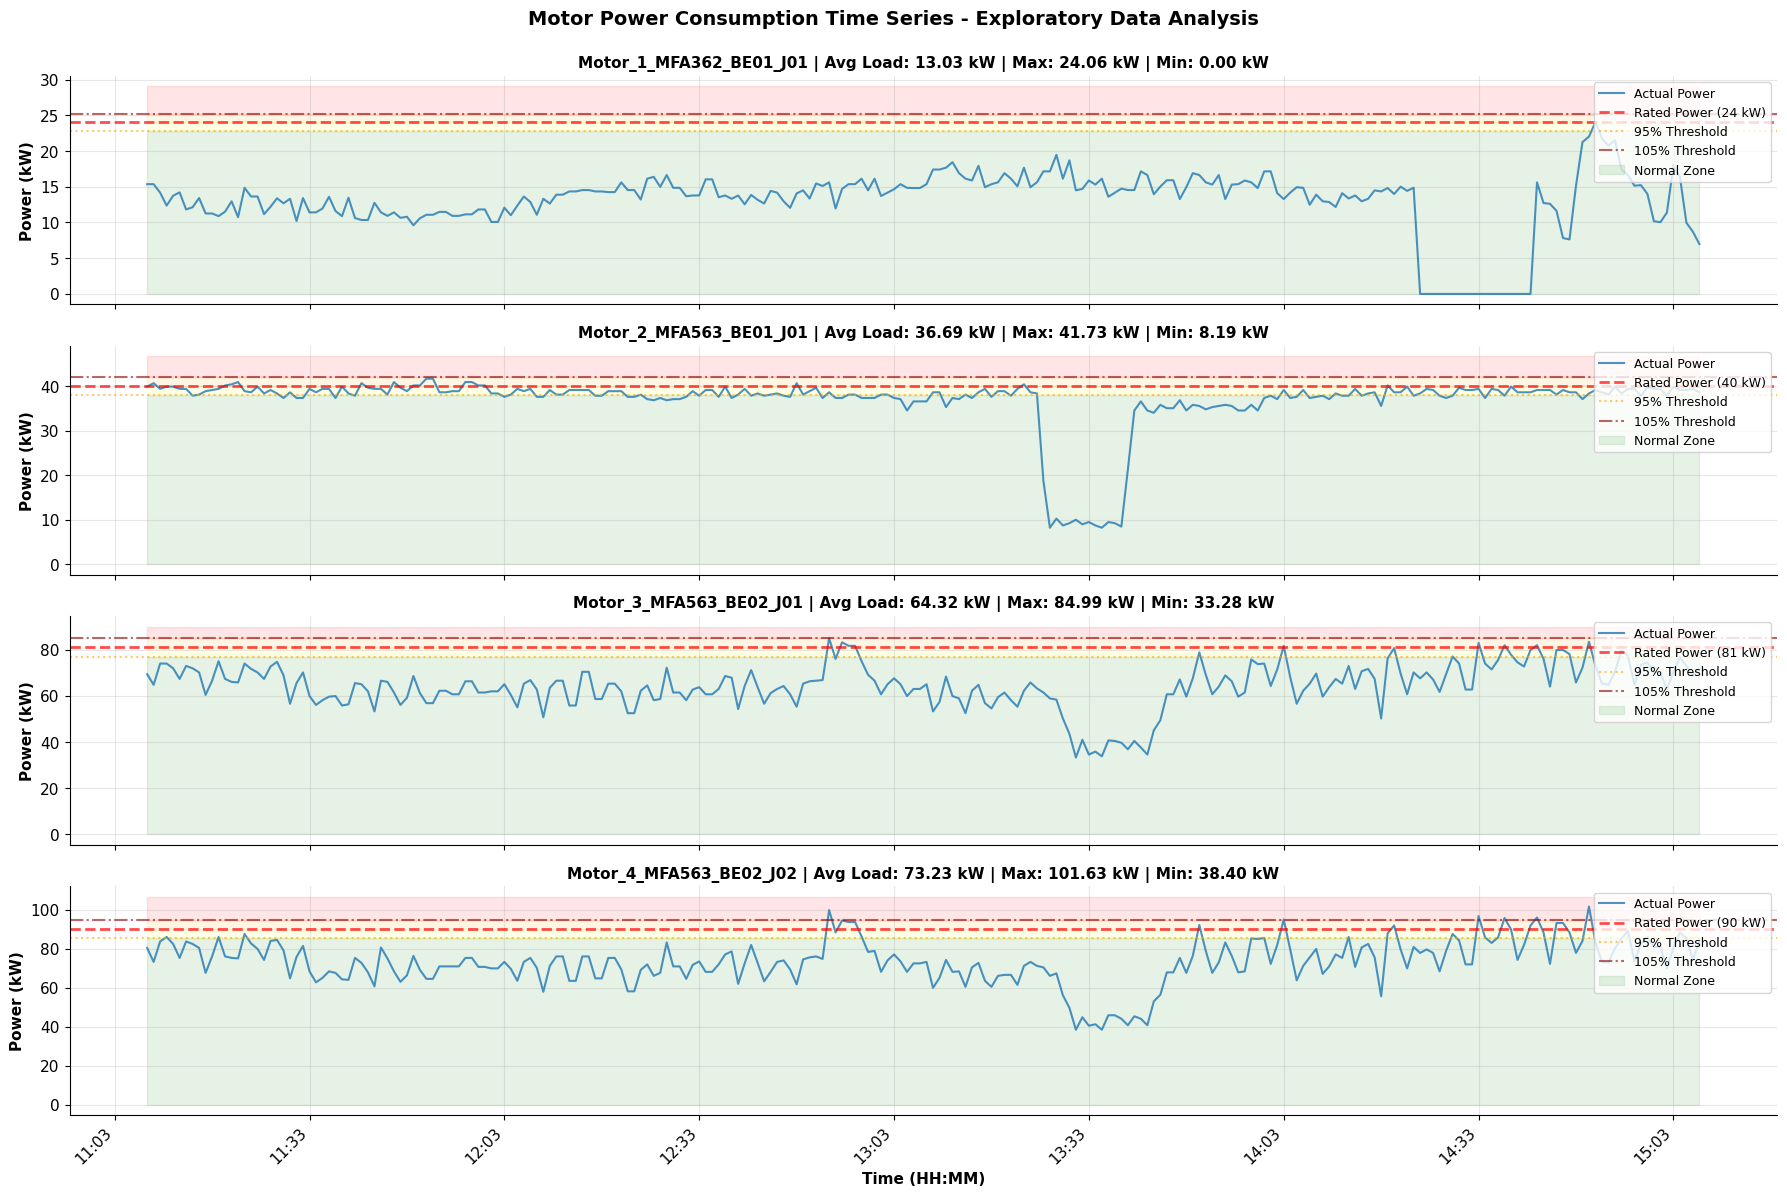

Time series visualization complete.


In [14]:
# Motor power consumption time-series graph (Exploratory Data Analysis)

fig, axes = plt.subplots(4, 1, figsize=(18, 12))
fig.suptitle('Motor Power Consumption Time Series - Exploratory Data Analysis', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, motor in enumerate(motor_cols):
    ax = axes[idx]
    
    rated_power = rated_powers[motor]
    
    ax.plot(cement_mill_processed['Timestamp'], cement_mill_processed[motor], 
            linewidth=1.5, label='Actual Power', color='#1f77b4', alpha=0.8)
    
    ax.axhline(y=rated_power, color='red', linestyle='--', linewidth=2, 
               label=f'Rated Power ({rated_power} kW)', alpha=0.7)
    
    ax.axhline(y=rated_power * 0.95, color='orange', linestyle=':', linewidth=1.5, 
               label='95% Threshold', alpha=0.6)
    
    ax.axhline(y=rated_power * 1.05, color='darkred', linestyle='-.', linewidth=1.5, 
               label='105% Threshold', alpha=0.6)
    
    ax.fill_between(cement_mill_processed['Timestamp'], 0, rated_power * 0.95, 
                     alpha=0.1, color='green', label='Normal Zone')
    ax.fill_between(cement_mill_processed['Timestamp'], rated_power * 0.95, rated_power, 
                     alpha=0.1, color='yellow')
    ax.fill_between(cement_mill_processed['Timestamp'], rated_power, rated_power * 1.05, 
                     alpha=0.1, color='orange')
    ax.fill_between(cement_mill_processed['Timestamp'], rated_power * 1.05, 
                     cement_mill_processed[motor].max() + 5, alpha=0.1, color='red')
    
    ax.set_ylabel('Power (kW)', fontweight='bold')
    ax.set_title(f'{motor} | Avg Load: {cement_mill_processed[motor].mean():.2f} kW | '
                 f'Max: {cement_mill_processed[motor].max():.2f} kW | Min: {cement_mill_processed[motor].min():.2f} kW',
                 fontweight='bold', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    
    if idx == 3:
        ax.set_xlabel('Time (HH:MM)', fontweight='bold')
    
    if idx < 3:
        ax.set_xticklabels([])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Time series visualization complete.")

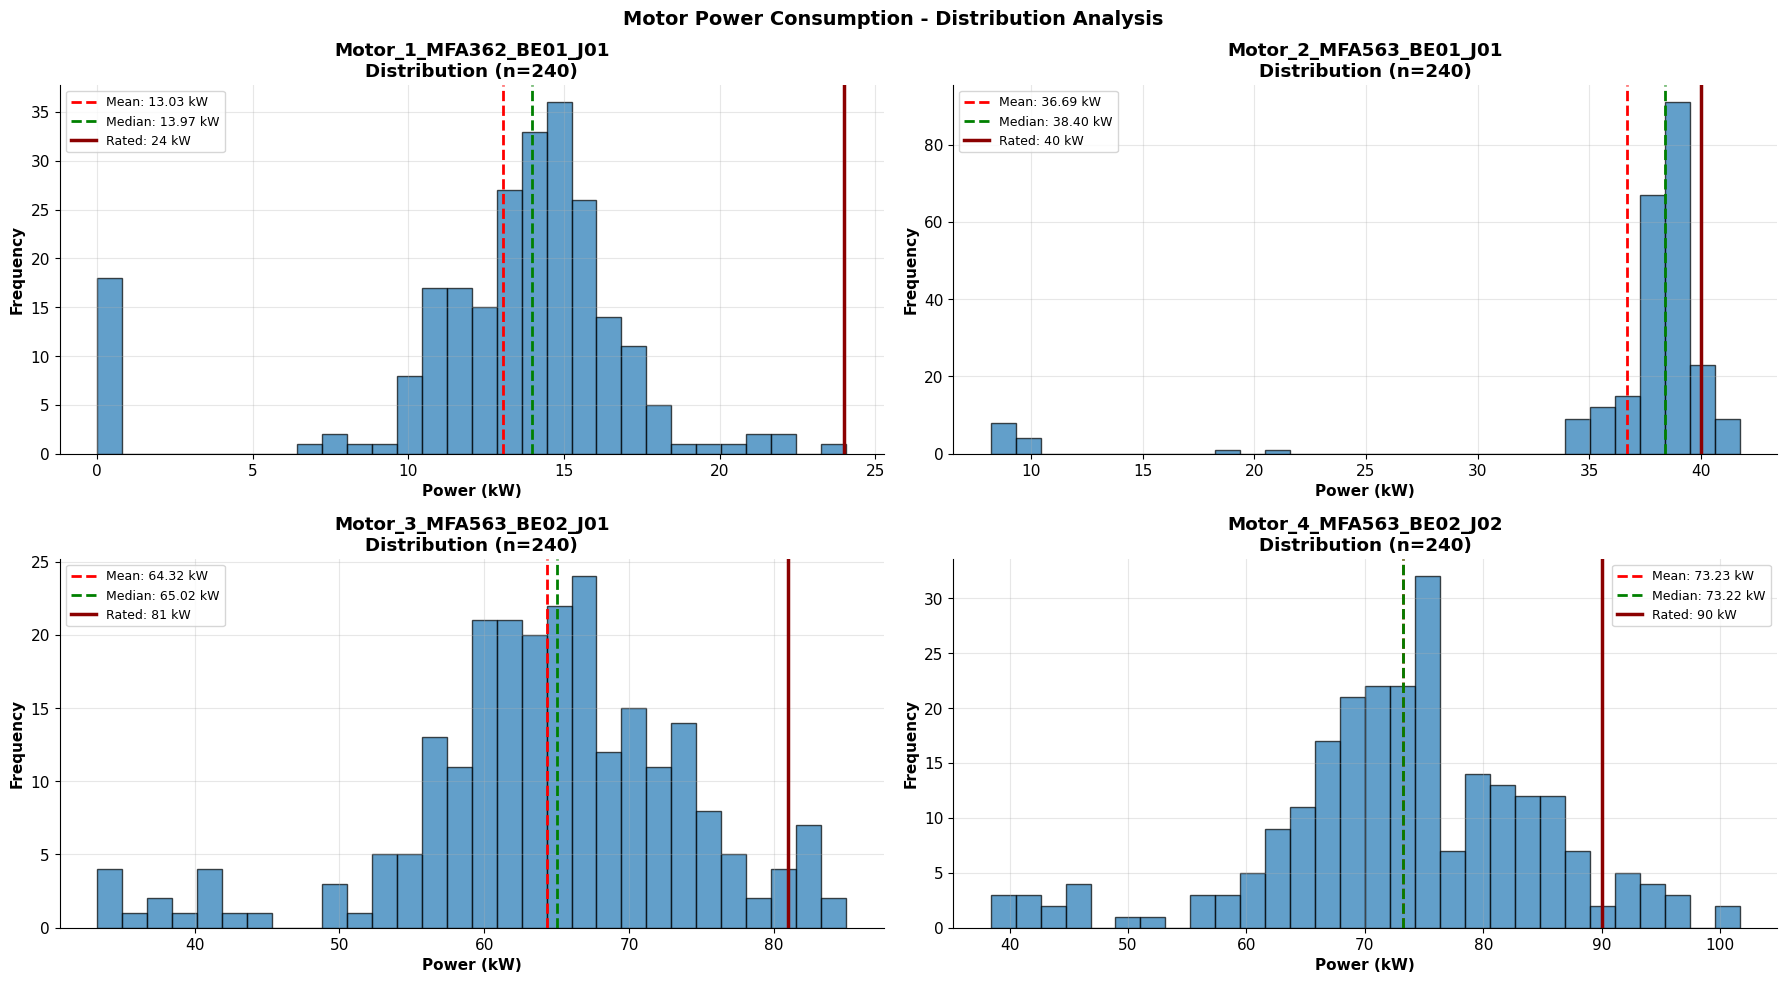

Distribution visualization complete.



In [15]:
# Motor power consumption distribution analysis graph
 
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Motor Power Consumption - Distribution Analysis', 
             fontsize=14, fontweight='bold')

for idx, motor in enumerate(motor_cols):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    data = cement_mill_processed[motor].dropna()
    
    ax.hist(data, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f} kW')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f} kW')
    ax.axvline(rated_powers[motor], color='darkred', linestyle='-', linewidth=2.5, label=f'Rated: {rated_powers[motor]} kW')
    
    ax.set_xlabel('Power (kW)', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(f'{motor}\nDistribution (n={len(data)})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Distribution visualization complete.\n")

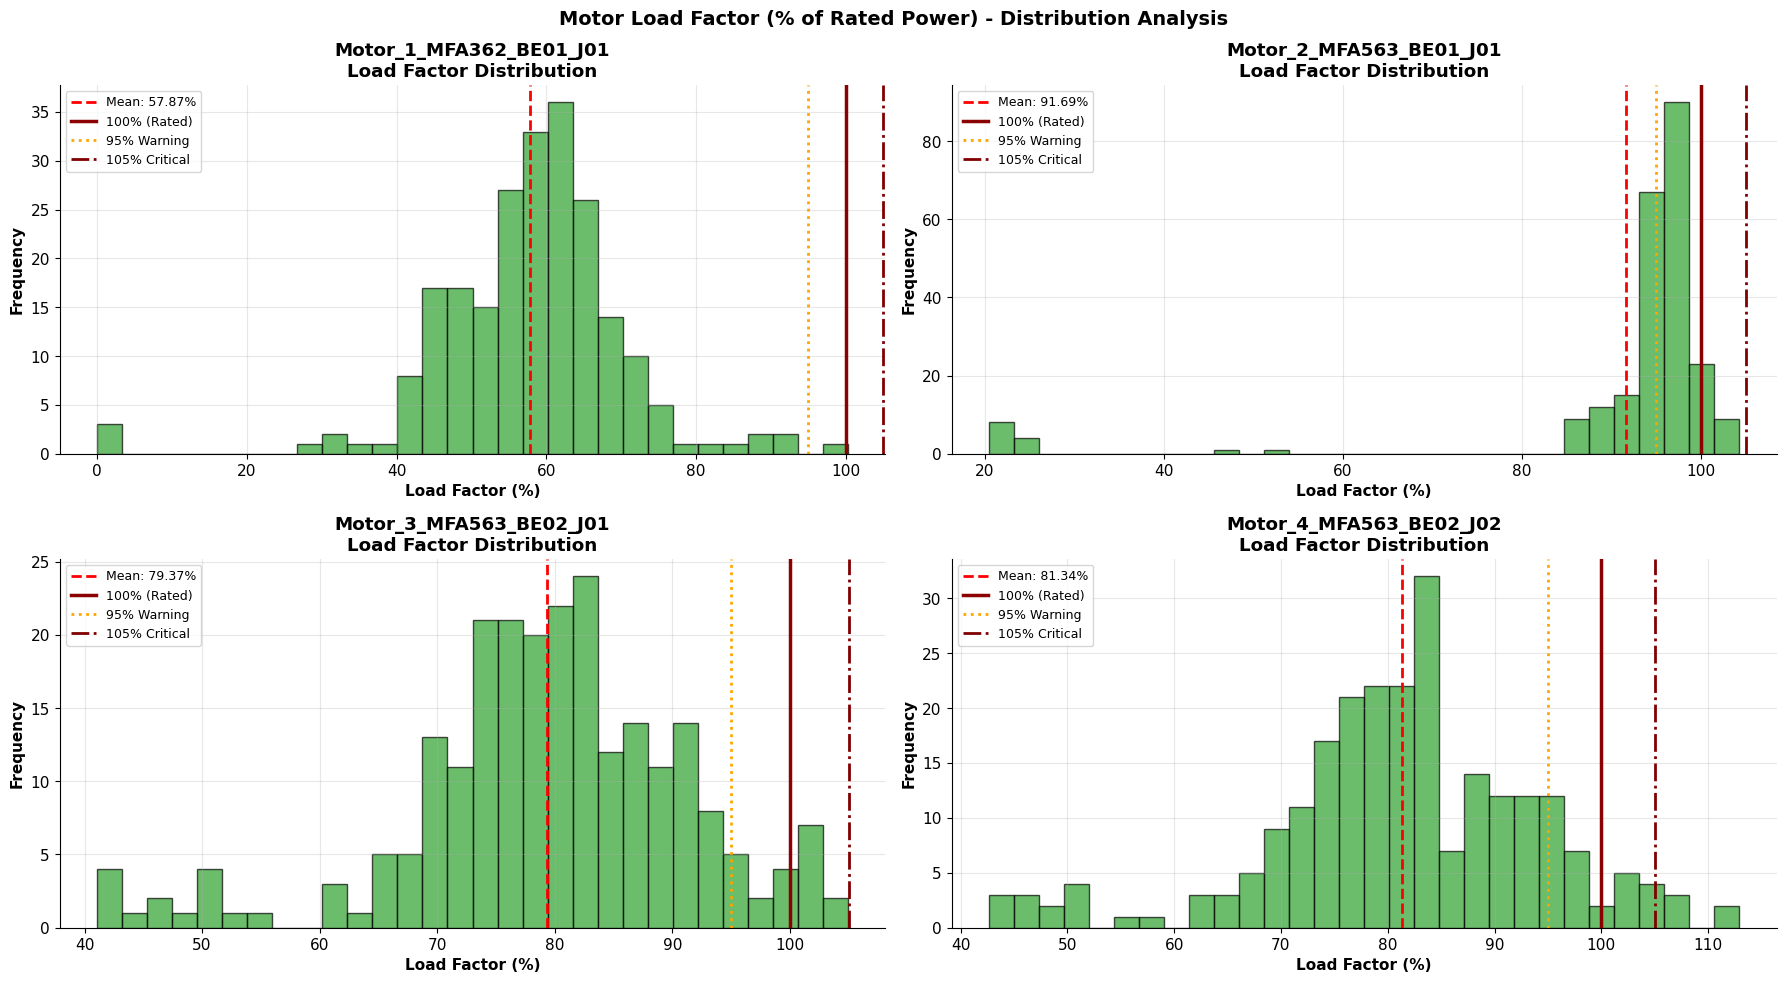

Load factor distribution visualization complete.



In [18]:
# Load factor distribution analysis graph

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Motor Load Factor (% of Rated Power) - Distribution Analysis', 
             fontsize=14, fontweight='bold')

for idx, motor in enumerate(motor_cols):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    load_factor_col = f'{motor}_LoadFactor'
    data = cement_mill_processed[load_factor_col].dropna()
    
    ax.hist(data, bins=30, color='#2ca02c', alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}%')
    ax.axvline(100, color='darkred', linestyle='-', linewidth=2.5, label='100% (Rated)')
    ax.axvline(95, color='orange', linestyle=':', linewidth=2, label='95% Warning')
    ax.axvline(105, color='maroon', linestyle='-.', linewidth=2, label='105% Critical')
    
    ax.set_xlabel('Load Factor (%)', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(f'{motor}\nLoad Factor Distribution', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Load factor distribution visualization complete.\n")

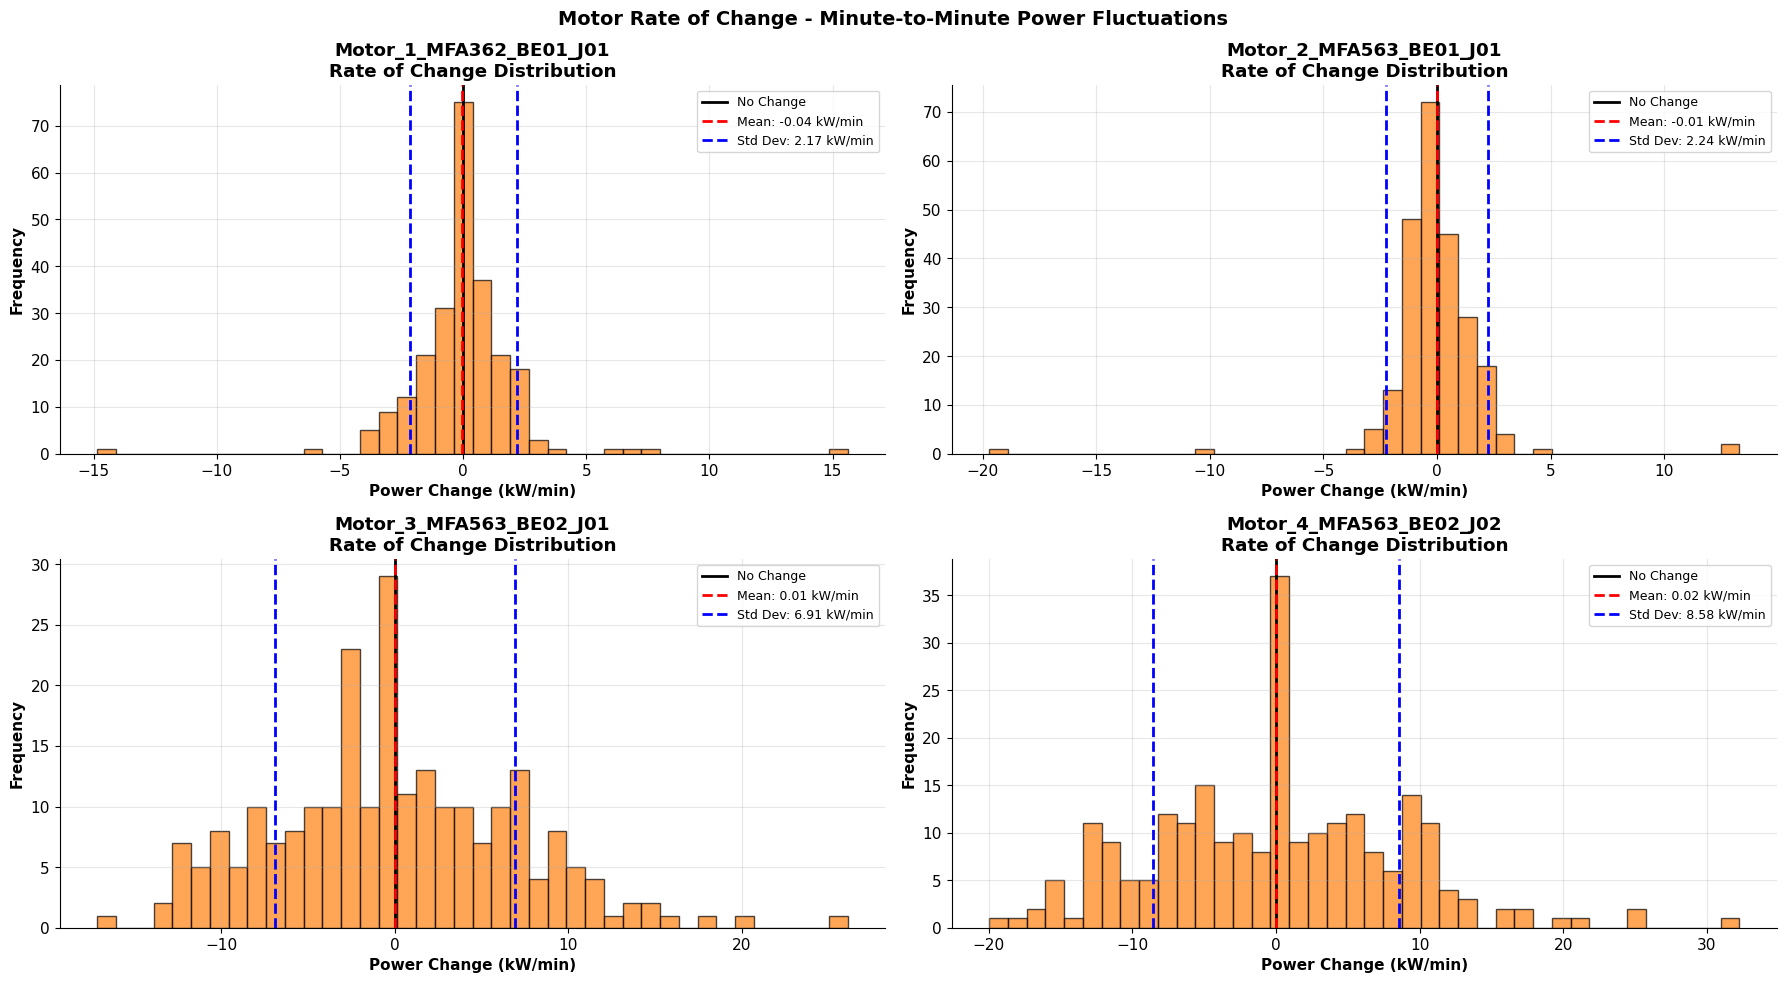

Rate of change visualization complete.



In [19]:
# Motor rate of change minute to minutes energy fluctuation graph

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Motor Rate of Change - Minute-to-Minute Power Fluctuations', 
             fontsize=14, fontweight='bold')

for idx, motor in enumerate(motor_cols):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    roc_col = f'{motor}_RateOfChange'
    data = cement_mill_processed[roc_col].dropna()
    
    ax.hist(data, bins=40, color='#ff7f0e', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', linestyle='-', linewidth=2, label='No Change')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f} kW/min')
    ax.axvline(data.std(), color='blue', linestyle='--', linewidth=2, label=f'Std Dev: {data.std():.2f} kW/min')
    ax.axvline(-data.std(), color='blue', linestyle='--', linewidth=2)
    
    ax.set_xlabel('Power Change (kW/min)', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(f'{motor}\nRate of Change Distribution', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Rate of change visualization complete.\n")

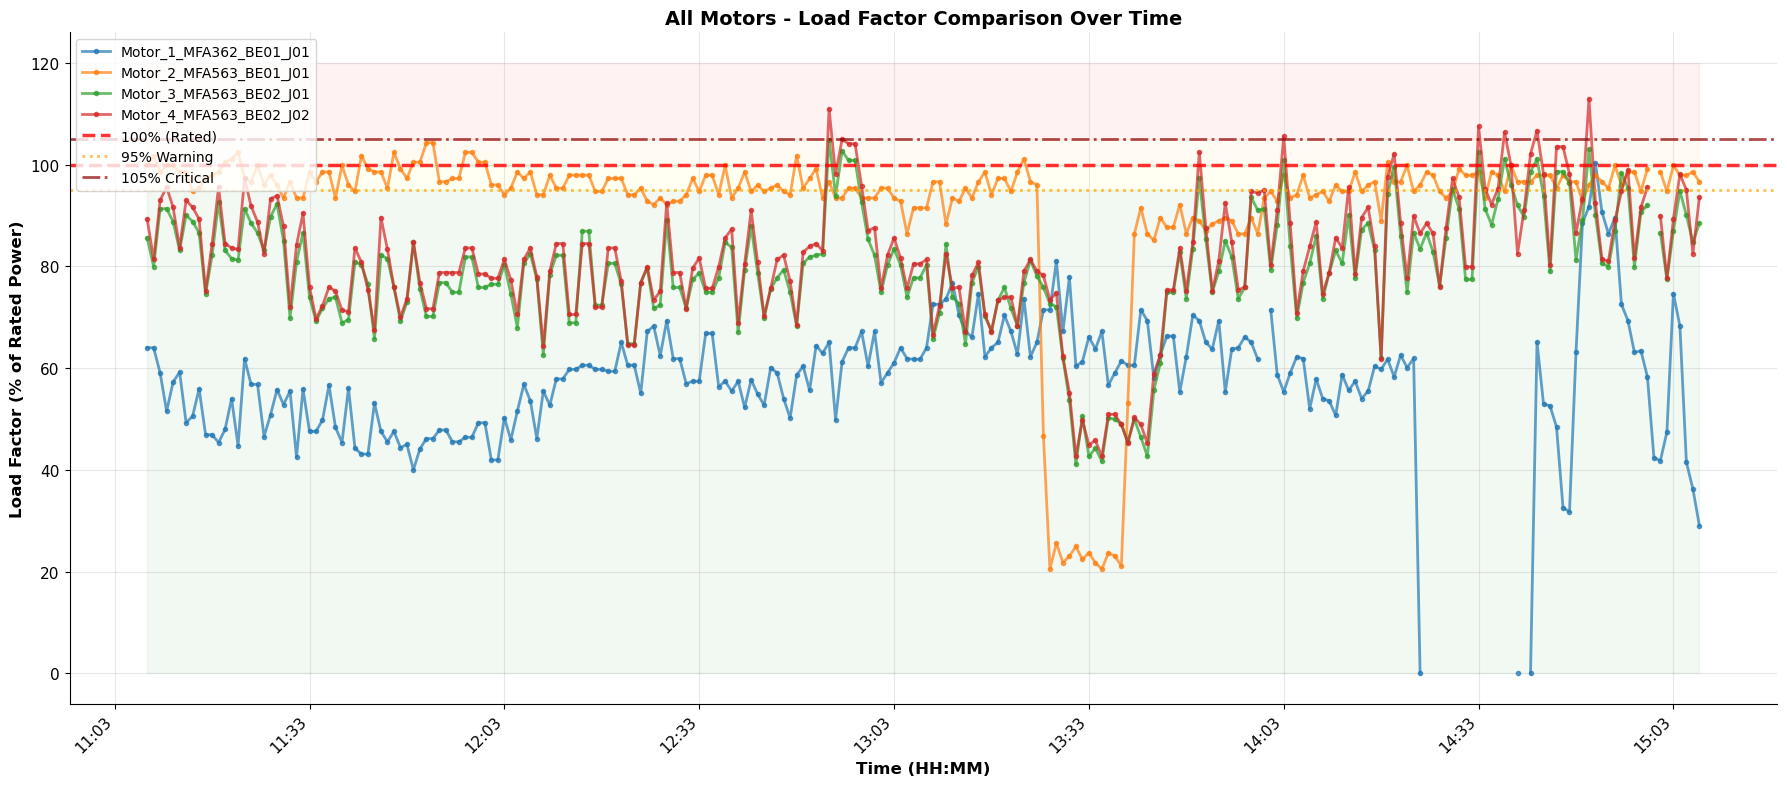

Load factor comparison visualization complete.



In [20]:
# comparing the load factor for all the motors 

fig, ax = plt.subplots(figsize=(18, 8))

for motor in motor_cols:
    ax.plot(cement_mill_processed['Timestamp'], cement_mill_processed[f'{motor}_LoadFactor'], 
            linewidth=2, marker='o', markersize=3, label=motor, alpha=0.7)

ax.axhline(y=100, color='red', linestyle='--', linewidth=2.5, label='100% (Rated)', alpha=0.8)
ax.axhline(y=95, color='orange', linestyle=':', linewidth=2, label='95% Warning', alpha=0.7)
ax.axhline(y=105, color='darkred', linestyle='-.', linewidth=2, label='105% Critical', alpha=0.7)

ax.fill_between(cement_mill_processed['Timestamp'], 0, 95, alpha=0.05, color='green')
ax.fill_between(cement_mill_processed['Timestamp'], 95, 100, alpha=0.05, color='yellow')
ax.fill_between(cement_mill_processed['Timestamp'], 100, 105, alpha=0.05, color='orange')
ax.fill_between(cement_mill_processed['Timestamp'], 105, 120, alpha=0.05, color='red')

ax.set_xlabel('Time (HH:MM)', fontweight='bold', fontsize=12)
ax.set_ylabel('Load Factor (% of Rated Power)', fontweight='bold', fontsize=12)
ax.set_title('All Motors - Load Factor Comparison Over Time', fontweight='bold', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Load factor comparison visualization complete.\n")

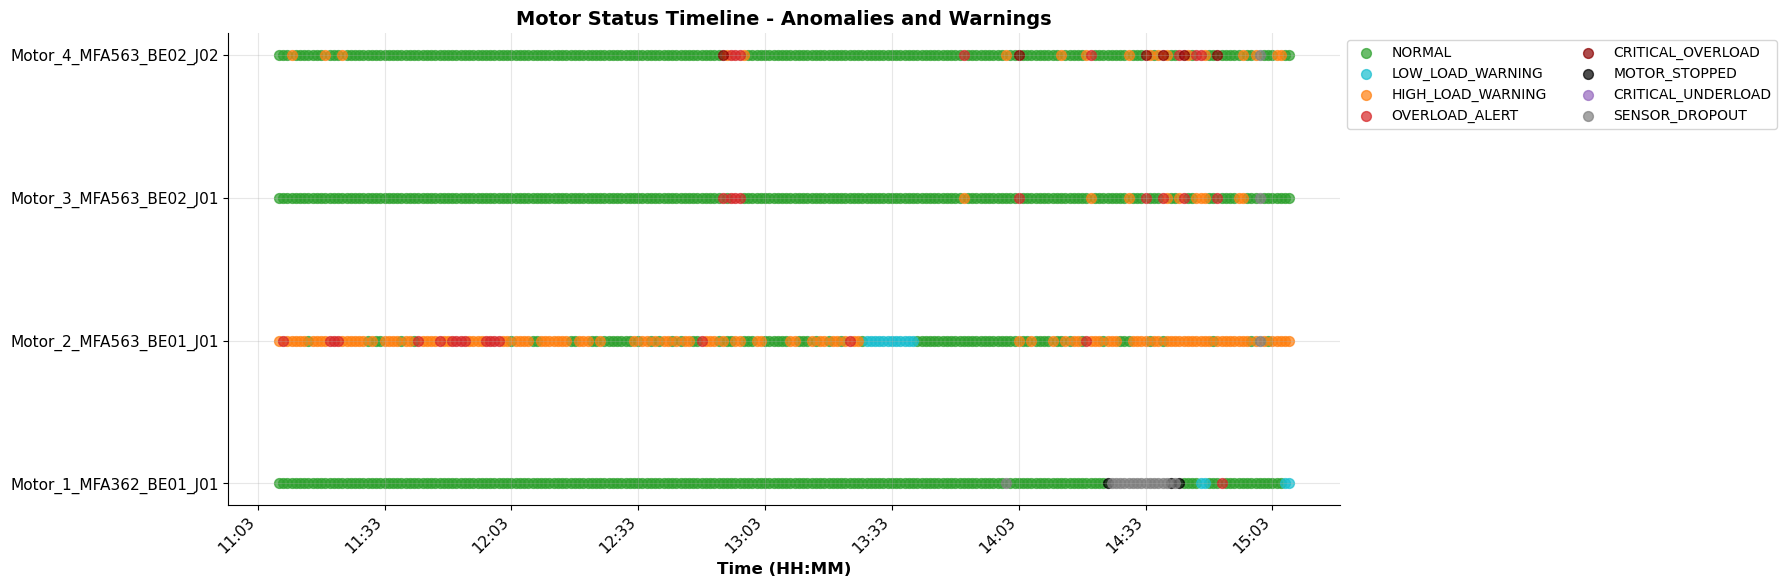

Status timeline visualization complete.



In [22]:
# Motor status timeline for both anomalies and warning messages

fig, ax = plt.subplots(figsize=(18, 6))

motor_statuses = cement_mill_processed[[f'{motor}_Status' for motor in motor_cols]]

status_mapping = {
    'NORMAL': 0,
    'LOW_LOAD_WARNING': 1,
    'HIGH_LOAD_WARNING': 2,
    'OVERLOAD_ALERT': 3,
    'CRITICAL_OVERLOAD': 4,
    'MOTOR_STOPPED': 5,
    'CRITICAL_UNDERLOAD': 6,
    'SENSOR_DROPOUT': 7
}

color_mapping = {
    'NORMAL': '#2ca02c',
    'LOW_LOAD_WARNING': '#17becf',
    'HIGH_LOAD_WARNING': '#ff7f0e',
    'OVERLOAD_ALERT': '#d62728',
    'CRITICAL_OVERLOAD': '#8b0000',
    'MOTOR_STOPPED': '#000000',
    'CRITICAL_UNDERLOAD': '#9467bd',
    'SENSOR_DROPOUT': '#7f7f7f'
}

for idx, motor in enumerate(motor_cols):
    status_col = f'{motor}_Status'
    
    for status in status_mapping.keys():
        mask = cement_mill_processed[status_col] == status
        timestamps = cement_mill_processed[mask]['Timestamp']
        y_positions = [idx] * len(timestamps)
        
        ax.scatter(timestamps, y_positions, c=color_mapping[status], 
                  s=50, alpha=0.7, label=status if idx == 0 else '')

ax.set_yticks(range(len(motor_cols)))
ax.set_yticklabels(motor_cols)
ax.set_xlabel('Time (HH:MM)', fontweight='bold', fontsize=12)
ax.set_title('Motor Status Timeline - Anomalies and Warnings', fontweight='bold', fontsize=14)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
ax.grid(True, alpha=0.3, axis='x')
plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), loc='upper left', 
         fontsize=10, ncol=2, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

print("Status timeline visualization complete.\n")

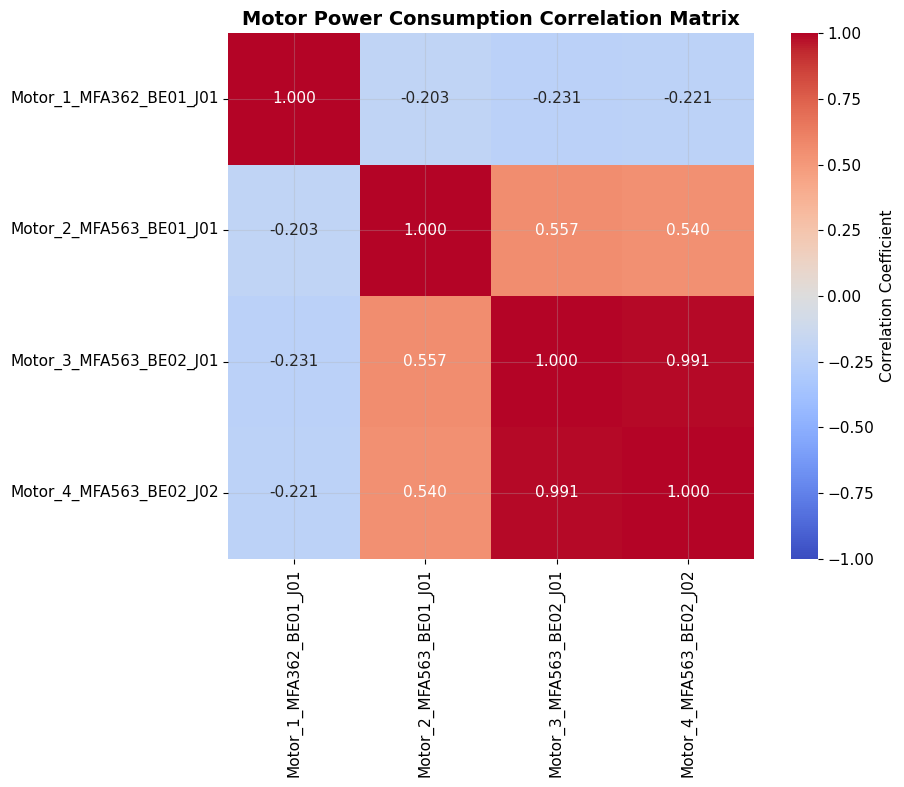

Correlation matrix:
                         Motor_1_MFA362_BE01_J01  Motor_2_MFA563_BE01_J01  Motor_3_MFA563_BE02_J01  Motor_4_MFA563_BE02_J02
Motor_1_MFA362_BE01_J01                   1.0000                  -0.2027                  -0.2313                  -0.2211
Motor_2_MFA563_BE01_J01                  -0.2027                   1.0000                   0.5574                   0.5399
Motor_3_MFA563_BE02_J01                  -0.2313                   0.5574                   1.0000                   0.9906
Motor_4_MFA563_BE02_J02                  -0.2211                   0.5399                   0.9906                   1.0000




In [24]:
# Correlation matrix for motor power consumption

correlation_data = cement_mill_processed[motor_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(correlation_data, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, ax=ax, 
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Motor Power Consumption Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(correlation_data)
print("\n")

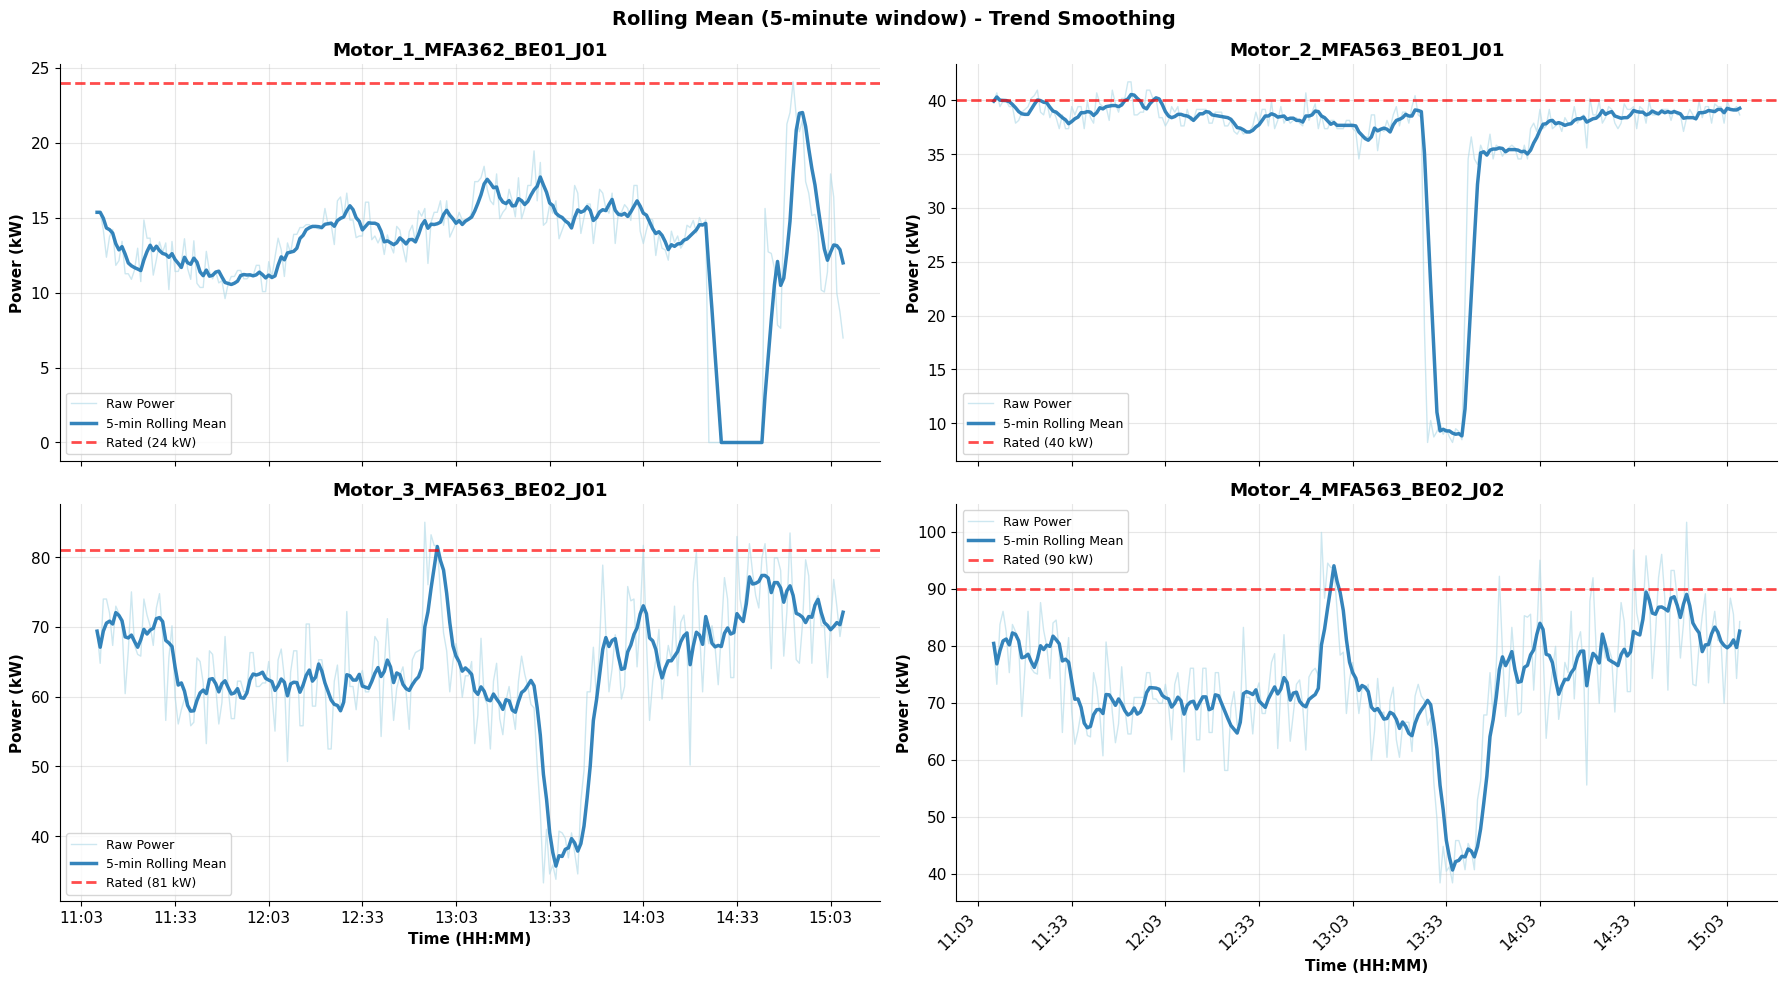

Rolling mean visualization complete.



In [27]:
# Rolling mean for every (5-Minutes window)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Rolling Mean (5-minute window) - Trend Smoothing', 
             fontsize=14, fontweight='bold')

for idx, motor in enumerate(motor_cols):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    rated_power = rated_powers[motor]
    
    ax.plot(cement_mill_processed['Timestamp'], cement_mill_processed[motor], 
            linewidth=1, label='Raw Power', color='lightblue', alpha=0.6)
    ax.plot(cement_mill_processed['Timestamp'], cement_mill_processed[f'{motor}_RollingMean_5min'], 
            linewidth=2.5, label='5-min Rolling Mean', color='#1f77b4', alpha=0.9)
    
    ax.axhline(y=rated_power, color='red', linestyle='--', linewidth=2, 
               label=f'Rated ({rated_power} kW)', alpha=0.7)
    
    ax.set_ylabel('Power (kW)', fontweight='bold')
    ax.set_title(f'{motor}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    
    if idx > 1:
        ax.set_xlabel('Time (HH:MM)', fontweight='bold')
    else:
        ax.set_xticklabels([])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Rolling mean visualization complete.\n")

In [28]:
# Statistical process control (SPC)

cement_mill_spc = cement_mill_processed.copy()

spc_summary = {}

for motor in motor_cols:
    mean = cement_mill_spc[motor].mean()
    std = cement_mill_spc[motor].std()
    
    ucl_3sigma = mean + (3 * std)
    lcl_3sigma = mean - (3 * std)
    ucl_2sigma = mean + (2 * std)
    lcl_2sigma = mean - (2 * std)
    
    cement_mill_spc[f'{motor}_SPC_Violation'] = 'IN_CONTROL'
    
    cement_mill_spc.loc[
        (cement_mill_spc[motor] > ucl_3sigma) | (cement_mill_spc[motor] < lcl_3sigma),
        f'{motor}_SPC_Violation'
    ] = 'OUT_OF_CONTROL_3SIGMA'
    
    cement_mill_spc.loc[
        (cement_mill_spc[f'{motor}_SPC_Violation'] == 'IN_CONTROL') &
        ((cement_mill_spc[motor] > ucl_2sigma) | (cement_mill_spc[motor] < lcl_2sigma)),
        f'{motor}_SPC_Violation'
    ] = 'WARNING_2SIGMA'
    
    cement_mill_spc[f'{motor}_ZScore'] = zscore(cement_mill_spc[motor], nan_policy='omit')
    
    spc_summary[motor] = {
        'mean': mean,
        'std': std,
        'lcl_3sigma': lcl_3sigma,
        'ucl_3sigma': ucl_3sigma,
        'lcl_2sigma': lcl_2sigma,
        'ucl_2sigma': ucl_2sigma
    }
    
    print(f"\n{motor} - Statistical Process Control Baseline:")
    print(f"  Mean                : {mean:.4f} kW")
    print(f"  Std Dev             : {std:.4f} kW")
    print(f"  LCL (3-sigma)       : {lcl_3sigma:.4f} kW")
    print(f"  UCL (3-sigma)       : {ucl_3sigma:.4f} kW")
    print(f"  LCL (2-sigma)       : {lcl_2sigma:.4f} kW")
    print(f"  UCL (2-sigma)       : {ucl_2sigma:.4f} kW")
    
    violations = cement_mill_spc[f'{motor}_SPC_Violation'].value_counts()
    print(f"  Control Status:")
    for status, count in violations.items():
        pct = (count / len(cement_mill_spc)) * 100
        print(f"    {status:25s}: {count:3d} ({pct:5.2f}%)")

print(f"\n\nDetailed 3-sigma Out of Control Violations:")
spc_violation_cols = [f'{motor}_SPC_Violation' for motor in motor_cols]
violation_mask = cement_mill_spc[spc_violation_cols].apply(
    lambda row: any('OUT_OF_CONTROL' in str(status) for status in row), axis=1
)

if violation_mask.sum() > 0:
    violation_data = cement_mill_spc[violation_mask][['Timestamp'] + motor_cols + spc_violation_cols]
    display(violation_data)
    print(f"\nTotal 3-sigma violations: {violation_mask.sum()}")
else:
    print("No 3-sigma violations detected.")

print(f"\n\nDetailed 2-sigma Warning Violations:")
warning_mask = cement_mill_spc[spc_violation_cols].apply(
    lambda row: any('WARNING' in str(status) for status in row), axis=1
)
print(f"Total 2-sigma warnings: {warning_mask.sum()}")

if warning_mask.sum() > 0:
    warning_data = cement_mill_spc[warning_mask][['Timestamp'] + motor_cols + spc_violation_cols]
    display(warning_data.head(15))
    


Motor_1_MFA362_BE01_J01 - Statistical Process Control Baseline:
  Mean                : 13.0333 kW
  Std Dev             : 4.4362 kW
  LCL (3-sigma)       : -0.2752 kW
  UCL (3-sigma)       : 26.3417 kW
  LCL (2-sigma)       : 4.1610 kW
  UCL (2-sigma)       : 21.9056 kW
  Control Status:
    IN_CONTROL               : 220 (91.67%)
    WARNING_2SIGMA           :  20 ( 8.33%)

Motor_2_MFA563_BE01_J01 - Statistical Process Control Baseline:
  Mean                : 36.6891 kW
  Std Dev             : 6.7149 kW
  LCL (3-sigma)       : 16.5443 kW
  UCL (3-sigma)       : 56.8339 kW
  LCL (2-sigma)       : 23.2592 kW
  UCL (2-sigma)       : 50.1189 kW
  Control Status:
    IN_CONTROL               : 226 (94.17%)
    OUT_OF_CONTROL_3SIGMA    :  12 ( 5.00%)
    WARNING_2SIGMA           :   2 ( 0.83%)

Motor_3_MFA563_BE02_J01 - Statistical Process Control Baseline:
  Mean                : 64.3157 kW
  Std Dev             : 9.6756 kW
  LCL (3-sigma)       : 35.2888 kW
  UCL (3-sigma)       : 93.3

,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02,Motor_1_MFA362_BE01_J01_SPC_Violation,Motor_2_MFA563_BE01_J01_SPC_Violation,Motor_3_MFA563_BE02_J01_SPC_Violation,Motor_4_MFA563_BE02_J02_SPC_Violation
139,2026-05-04 13:27:00,17.1520,8.1920,58.8800,66.0480,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,IN_CONTROL,IN_CONTROL
140,2026-05-04 13:28:00,19.4560,10.2400,58.3680,67.3280,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,IN_CONTROL,IN_CONTROL
141,2026-05-04 13:29:00,16.1280,8.7040,50.1760,56.0640,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,IN_CONTROL,IN_CONTROL
142,2026-05-04 13:30:00,18.6880,9.2160,43.5200,49.6640,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
143,2026-05-04 13:31:00,14.4960,9.9840,33.2800,38.4000,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA
144,2026-05-04 13:32:00,14.7010,8.9600,40.9600,44.8000,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
145,2026-05-04 13:33:00,15.8720,9.4720,34.5600,40.4480,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA
146,2026-05-04 13:34:00,15.3000,8.7040,35.8400,41.2160,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
147,2026-05-04 13:35:00,16.1280,8.1920,33.7920,38.4000,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA
148,2026-05-04 13:36:00,13.5960,9.4720,40.7040,45.8240,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA



Total 3-sigma violations: 13


Detailed 2-sigma Warning Violations:
Total 2-sigma warnings: 33


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02,Motor_1_MFA362_BE01_J01_SPC_Violation,Motor_2_MFA563_BE01_J01_SPC_Violation,Motor_3_MFA563_BE02_J01_SPC_Violation,Motor_4_MFA563_BE02_J02_SPC_Violation
105,2026-05-04 12:53:00,15.6160,38.6560,84.9920,99.8400,IN_CONTROL,IN_CONTROL,WARNING_2SIGMA,WARNING_2SIGMA
138,2026-05-04 13:26:00,17.1520,18.6880,61.4400,70.4000,IN_CONTROL,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL
142,2026-05-04 13:30:00,18.6880,9.2160,43.5200,49.6640,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
144,2026-05-04 13:32:00,14.7010,8.9600,40.9600,44.8000,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
145,2026-05-04 13:33:00,15.8720,9.4720,34.5600,40.4480,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA
146,2026-05-04 13:34:00,15.3000,8.7040,35.8400,41.2160,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
148,2026-05-04 13:36:00,13.5960,9.4720,40.7040,45.8240,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
149,2026-05-04 13:37:00,14.1740,9.2160,40.4480,45.8240,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
150,2026-05-04 13:38:00,14.7400,8.4480,39.6800,44.0320,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
151,2026-05-04 13:39:00,14.5350,21.2480,36.8640,40.7040,IN_CONTROL,WARNING_2SIGMA,WARNING_2SIGMA,WARNING_2SIGMA


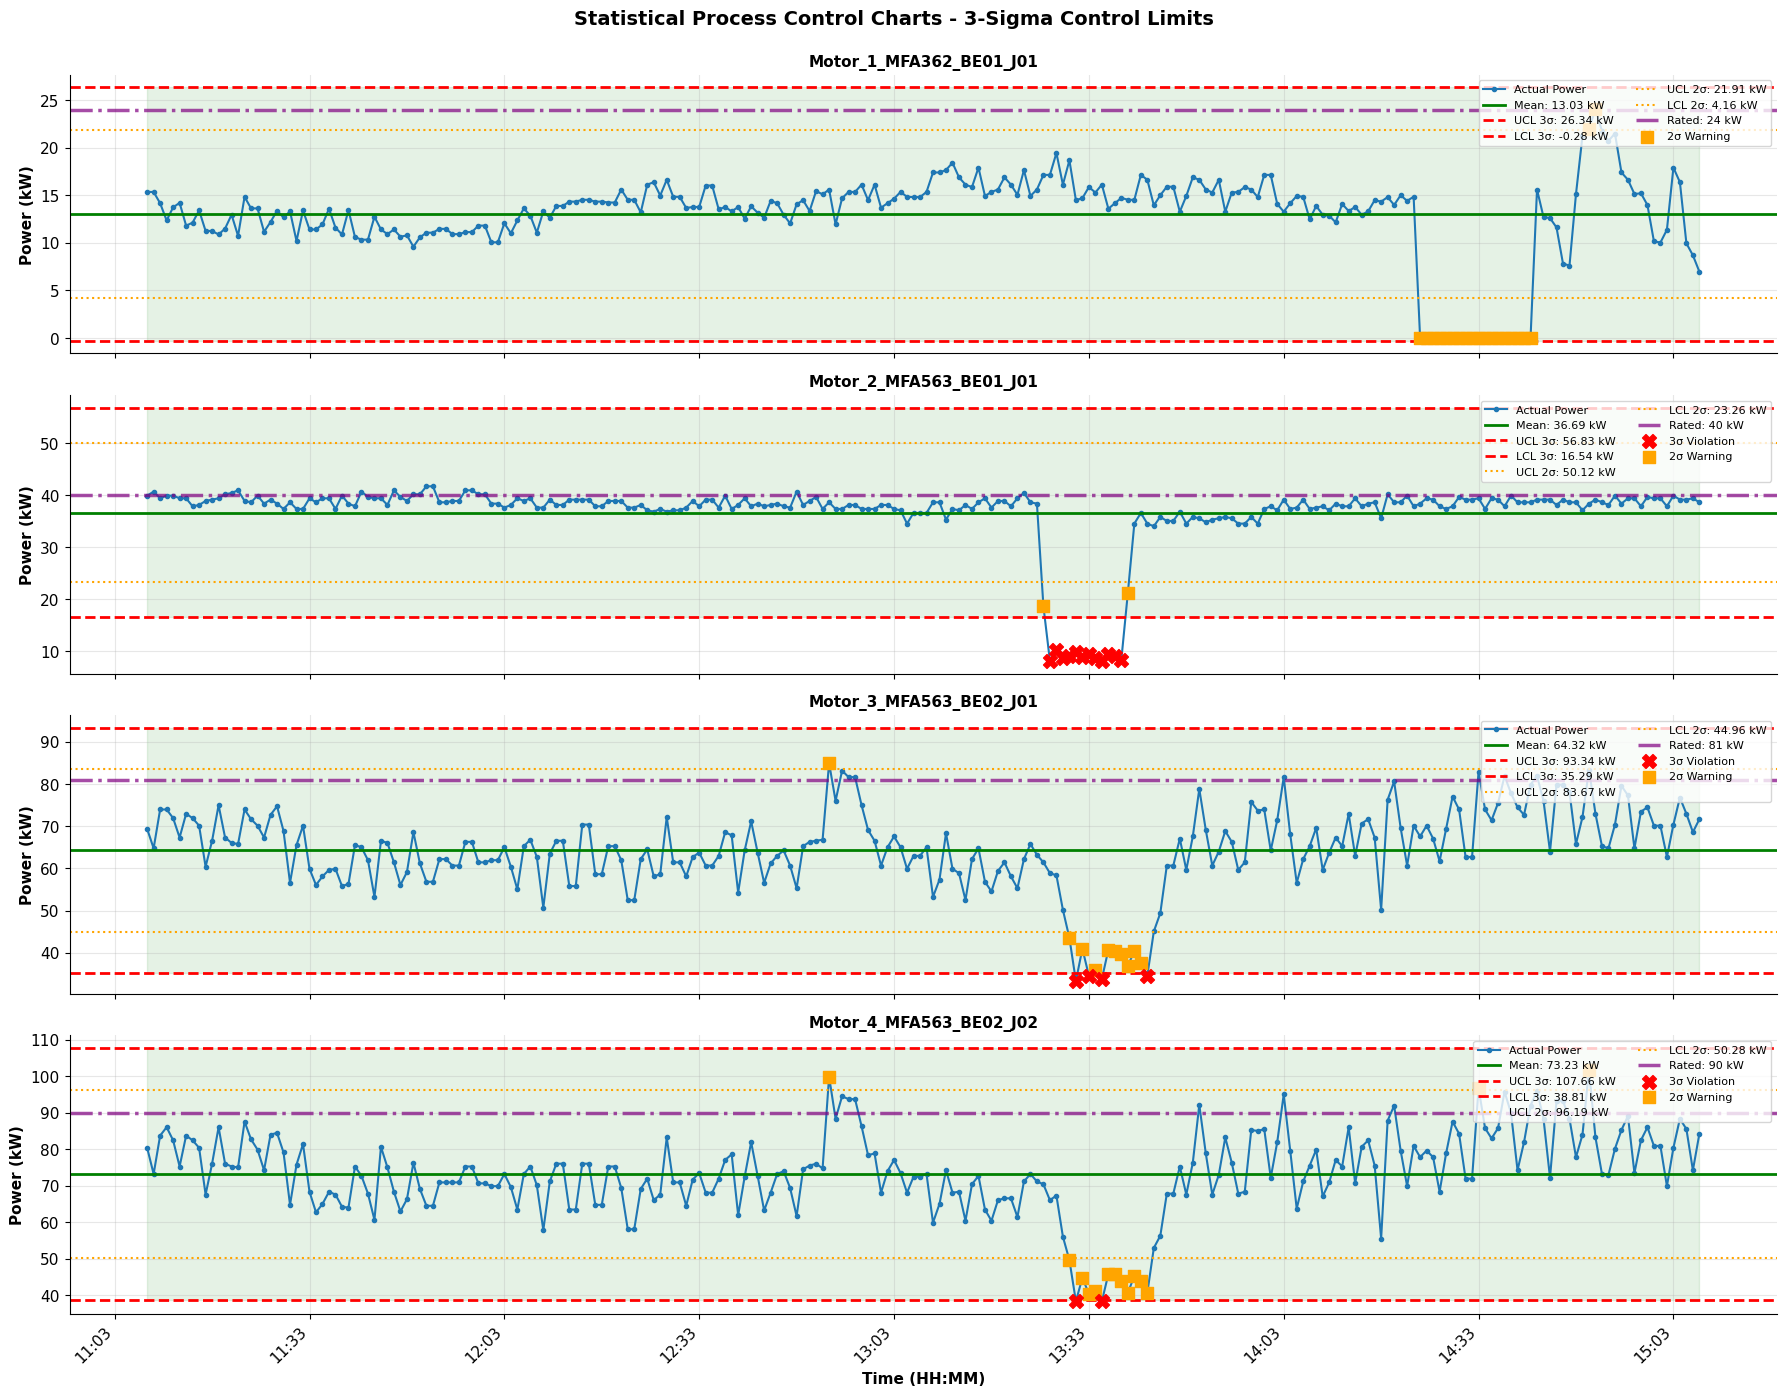

SPC Control Charts visualization complete.


In [32]:
# Statistical process control chart

fig, axes = plt.subplots(4, 1, figsize=(18, 14))
fig.suptitle('Statistical Process Control Charts - 3-Sigma Control Limits', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, motor in enumerate(motor_cols):
    ax = axes[idx]
    
    mean = spc_summary[motor]['mean']
    std = spc_summary[motor]['std']
    ucl_3 = spc_summary[motor]['ucl_3sigma']
    lcl_3 = spc_summary[motor]['lcl_3sigma']
    ucl_2 = spc_summary[motor]['ucl_2sigma']
    lcl_2 = spc_summary[motor]['lcl_2sigma']
    
    ax.plot(cement_mill_spc['Timestamp'], cement_mill_spc[motor], 
            linewidth=1.5, color='#1f77b4', label='Actual Power', marker='o', markersize=3)
    
    ax.axhline(y=mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f} kW')
    
    ax.axhline(y=ucl_3, color='red', linestyle='--', linewidth=2, label=f'UCL 3σ: {ucl_3:.2f} kW')
    ax.axhline(y=lcl_3, color='red', linestyle='--', linewidth=2, label=f'LCL 3σ: {lcl_3:.2f} kW')
    
    ax.axhline(y=ucl_2, color='orange', linestyle=':', linewidth=1.5, label=f'UCL 2σ: {ucl_2:.2f} kW')
    ax.axhline(y=lcl_2, color='orange', linestyle=':', linewidth=1.5, label=f'LCL 2σ: {lcl_2:.2f} kW')
    
    rated_power = rated_powers[motor]
    ax.axhline(y=rated_power, color='purple', linestyle='-.', linewidth=2.5, 
               label=f'Rated: {rated_power} kW', alpha=0.7)
    
    violations_3sigma = cement_mill_spc[cement_mill_spc[f'{motor}_SPC_Violation'] == 'OUT_OF_CONTROL_3SIGMA']
    if len(violations_3sigma) > 0:
        ax.scatter(violations_3sigma['Timestamp'], violations_3sigma[motor], 
                  color='red', s=100, marker='X', zorder=5, label='3σ Violation')
    
    warnings_2sigma = cement_mill_spc[cement_mill_spc[f'{motor}_SPC_Violation'] == 'WARNING_2SIGMA']
    if len(warnings_2sigma) > 0:
        ax.scatter(warnings_2sigma['Timestamp'], warnings_2sigma[motor], 
                  color='orange', s=80, marker='s', zorder=4, label='2σ Warning')
    
    ax.fill_between(cement_mill_spc['Timestamp'], lcl_3, ucl_3, alpha=0.1, color='green')
    
    ax.set_ylabel('Power (kW)', fontweight='bold')
    ax.set_title(f'{motor}', fontweight='bold', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    
    if idx == 3:
        ax.set_xlabel('Time (HH:MM)', fontweight='bold')
    else:
        ax.set_xticklabels([])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("SPC Control Charts visualization complete.")

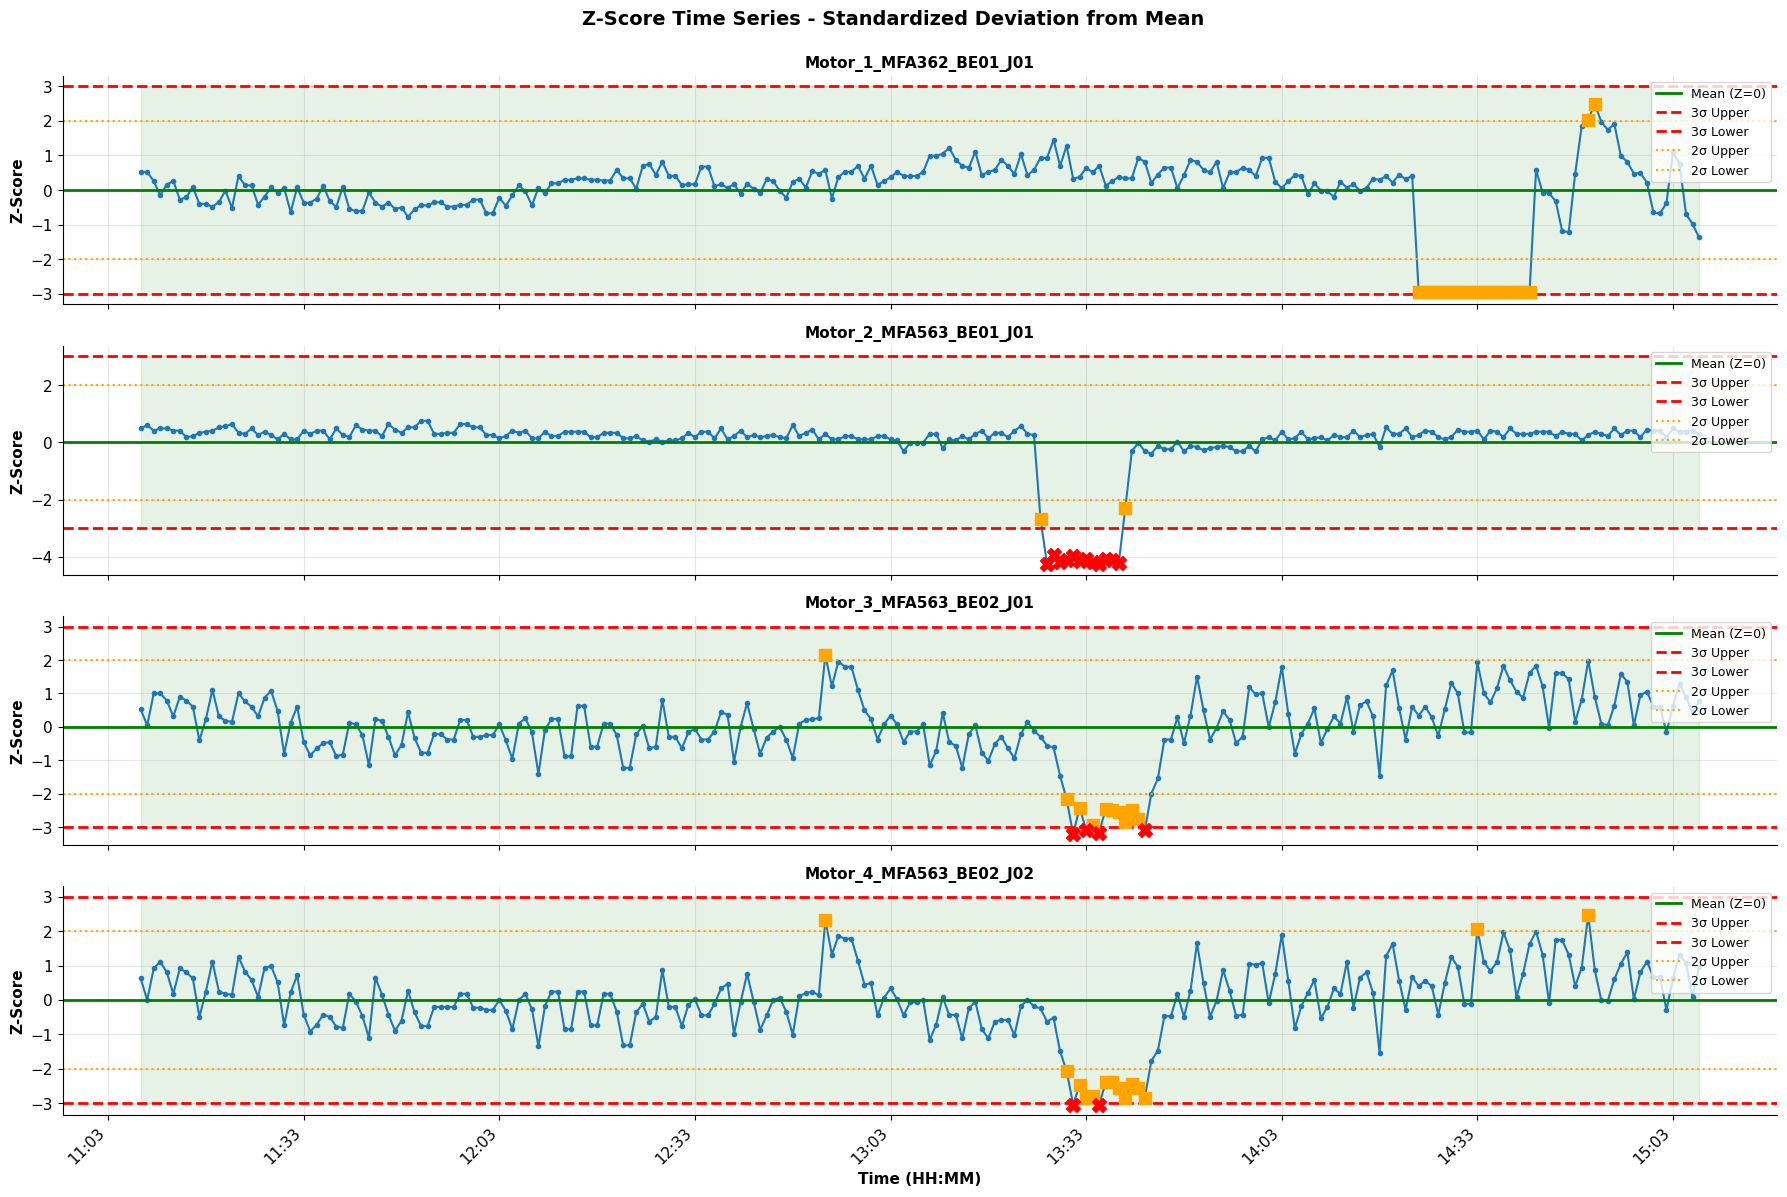

In [34]:
# Z-score time series representing the standardized deviation from the mean value

fig, axes = plt.subplots(4, 1, figsize=(18, 12))
fig.suptitle('Z-Score Time Series - Standardized Deviation from Mean', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, motor in enumerate(motor_cols):
    ax = axes[idx]
    
    z_score_col = f'{motor}_ZScore'
    
    ax.plot(cement_mill_spc['Timestamp'], cement_mill_spc[z_score_col], 
            linewidth=1.5, color='#1f77b4', marker='o', markersize=3)
    
    ax.axhline(y=0, color='green', linestyle='-', linewidth=2, label='Mean (Z=0)')
    ax.axhline(y=3, color='red', linestyle='--', linewidth=2, label='3σ Upper')
    ax.axhline(y=-3, color='red', linestyle='--', linewidth=2, label='3σ Lower')
    ax.axhline(y=2, color='orange', linestyle=':', linewidth=1.5, label='2σ Upper')
    ax.axhline(y=-2, color='orange', linestyle=':', linewidth=1.5, label='2σ Lower')
    
    ax.fill_between(cement_mill_spc['Timestamp'], -3, 3, alpha=0.1, color='green')
    
    violations = cement_mill_spc[cement_mill_spc[f'{motor}_SPC_Violation'] == 'OUT_OF_CONTROL_3SIGMA']
    if len(violations) > 0:
        ax.scatter(violations['Timestamp'], violations[z_score_col], 
                  color='red', s=100, marker='X', zorder=5)
    
    warnings = cement_mill_spc[cement_mill_spc[f'{motor}_SPC_Violation'] == 'WARNING_2SIGMA']
    if len(warnings) > 0:
        ax.scatter(warnings['Timestamp'], warnings[z_score_col], 
                  color='orange', s=80, marker='s', zorder=4)
    
    ax.set_ylabel('Z-Score', fontweight='bold')
    ax.set_title(f'{motor}', fontweight='bold', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    
    if idx == 3:
        ax.set_xlabel('Time (HH:MM)', fontweight='bold')
    else:
        ax.set_xticklabels([])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
from scipy.stats import shapiro, normaltest

print("Normality Tests for Motor Power Distributions")
print("=" * 80)

for motor in motor_cols:
    data = cement_mill_spc[motor].dropna()
    
    shapiro_stat, shapiro_p = shapiro(data)
    
    dagostino_stat, dagostino_p = normaltest(data)
    
    print(f"\n{motor}:")
    print(f"  Sample size: {len(data)}")
    print(f"  Shapiro-Wilk Test:")
    print(f"    Statistic: {shapiro_stat:.6f}")
    print(f"    P-value  : {shapiro_p:.6f}")
    print(f"    Result   : {'Normal distribution' if shapiro_p > 0.05 else 'NOT normal distribution'} (α=0.05)")
    
    print(f"  D'Agostino K-squared Test:")
    print(f"    Statistic: {dagostino_stat:.6f}")
    print(f"    P-value  : {dagostino_p:.6f}")
    print(f"    Result   : {'Normal distribution' if dagostino_p > 0.05 else 'NOT normal distribution'} (α=0.05)")
    
    skewness = data.skew()
    kurtosis = data.kurtosis()
    print(f"  Skewness : {skewness:.4f} ({'Right-skewed' if skewness > 0 else 'Left-skewed'})")
    print(f"  Kurtosis : {kurtosis:.4f} ({'Heavy-tailed' if kurtosis > 0 else 'Light-tailed'})")

Normality Tests for Motor Power Distributions

Motor_1_MFA362_BE01_J01:
  Sample size: 240
  Shapiro-Wilk Test:
    Statistic: 0.805185
    P-value  : 0.000000
    Result   : NOT normal distribution (α=0.05)
  D'Agostino K-squared Test:
    Statistic: 83.637030
    P-value  : 0.000000
    Result   : NOT normal distribution (α=0.05)
  Skewness : -1.6213 (Left-skewed)
  Kurtosis : 3.3467 (Heavy-tailed)

Motor_2_MFA563_BE01_J01:
  Sample size: 240
  Shapiro-Wilk Test:
    Statistic: 0.435016
    P-value  : 0.000000
    Result   : NOT normal distribution (α=0.05)
  D'Agostino K-squared Test:
    Statistic: 202.040590
    P-value  : 0.000000
    Result   : NOT normal distribution (α=0.05)
  Skewness : -3.6240 (Left-skewed)
  Kurtosis : 12.1116 (Heavy-tailed)

Motor_3_MFA563_BE02_J01:
  Sample size: 240
  Shapiro-Wilk Test:
    Statistic: 0.948129
    P-value  : 0.000000
    Result   : NOT normal distribution (α=0.05)
  D'Agostino K-squared Test:
    Statistic: 30.920216
    P-value  : 0.000

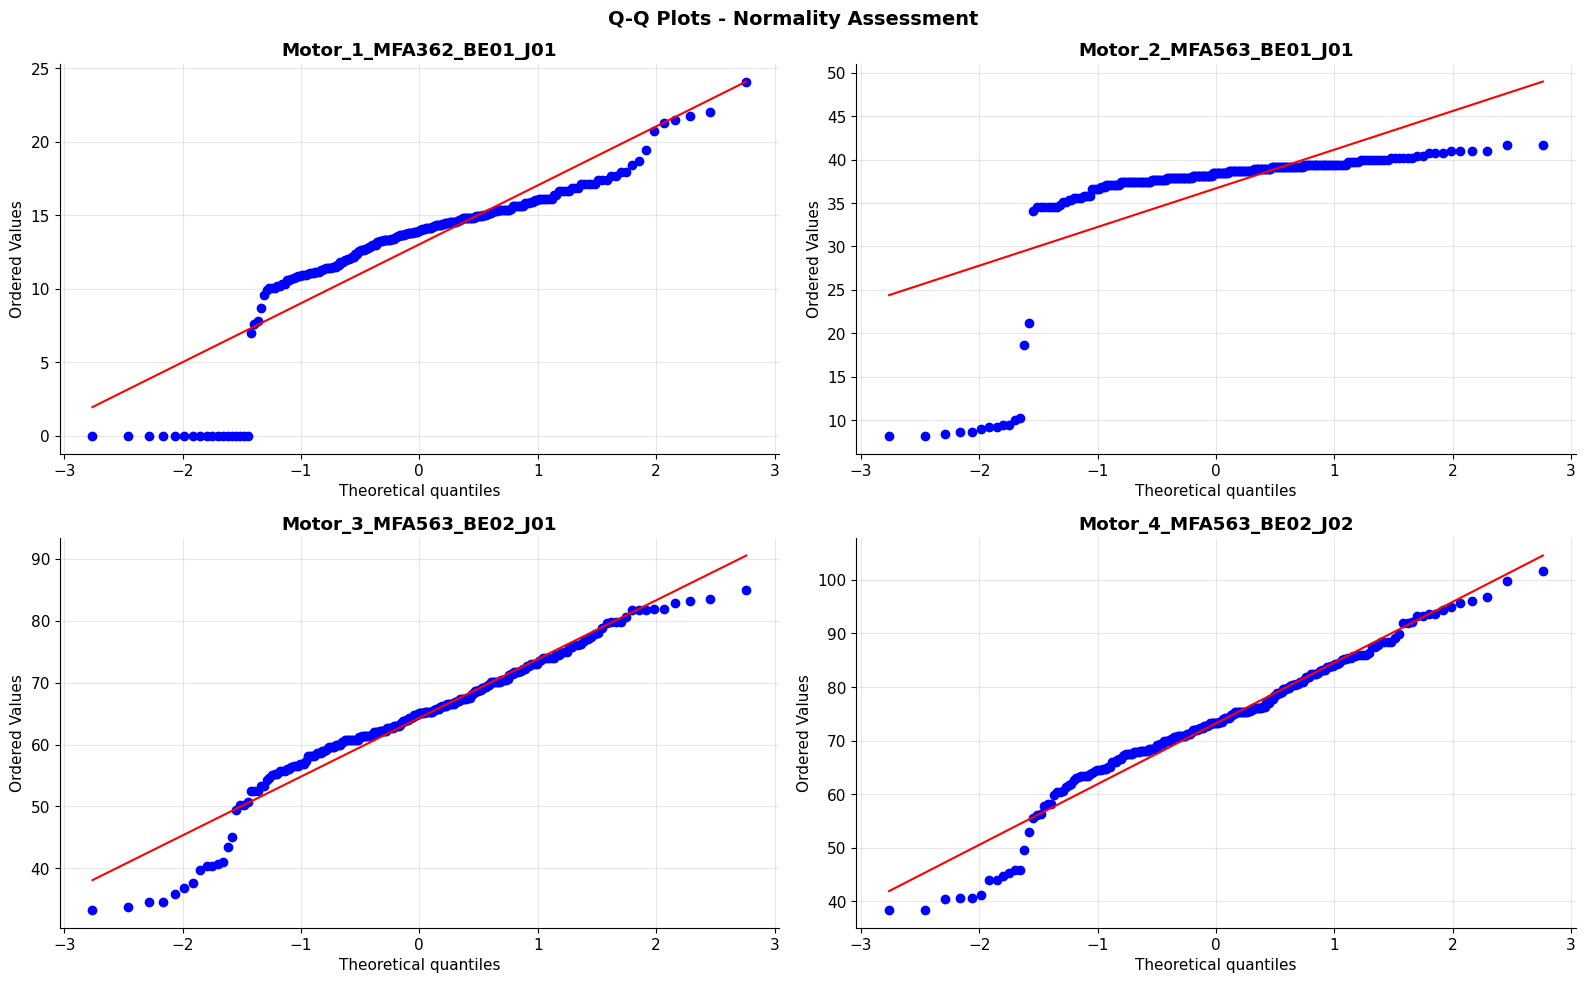

In [36]:
# Q-Q Plots for Normality assessment

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Q-Q Plots - Normality Assessment', fontsize=14, fontweight='bold')

for idx, motor in enumerate(motor_cols):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    data = cement_mill_spc[motor].dropna()
    
    stats.probplot(data, dist="norm", plot=ax)
    
    ax.set_title(f'{motor}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
violation_timeline = cement_mill_spc[['Timestamp'] + [f'{motor}_SPC_Violation' for motor in motor_cols]].copy()

for motor in motor_cols:
    violation_timeline[f'{motor}_Violation_Binary'] = violation_timeline[f'{motor}_SPC_Violation'].apply(
        lambda x: 1 if 'OUT_OF_CONTROL' in x else 0
    )
    violation_timeline[f'{motor}_Warning_Binary'] = violation_timeline[f'{motor}_SPC_Violation'].apply(
        lambda x: 1 if 'WARNING' in x else 0
    )

violation_timeline['Total_Violations'] = sum([violation_timeline[f'{motor}_Violation_Binary'] for motor in motor_cols])
violation_timeline['Total_Warnings'] = sum([violation_timeline[f'{motor}_Warning_Binary'] for motor in motor_cols])

print("Violation Timeline Summary")
print("=" * 80)

print(f"\nTotal 3-sigma violations across all motors: {violation_timeline['Total_Violations'].sum()}")
print(f"Total 2-sigma warnings across all motors: {violation_timeline['Total_Warnings'].sum()}")

print(f"\nTime periods with violations:")
violation_periods = violation_timeline[violation_timeline['Total_Violations'] > 0][
    ['Timestamp', 'Total_Violations'] + [f'{motor}_SPC_Violation' for motor in motor_cols]
]
display(violation_periods)

print(f"\n\nViolation Clustering Analysis:")
violation_timeline['Violation_Event'] = (violation_timeline['Total_Violations'] > 0).astype(int)
violation_timeline['Event_Group'] = (violation_timeline['Violation_Event'] != violation_timeline['Violation_Event'].shift()).cumsum()

violation_clusters = violation_timeline[violation_timeline['Violation_Event'] == 1].groupby('Event_Group').agg({
    'Timestamp': ['first', 'last', 'count']
})

violation_clusters.columns = ['Start_Time', 'End_Time', 'Duration_Minutes']
violation_clusters['Duration_Minutes'] = violation_clusters['Duration_Minutes']

print("\nViolation Event Clusters:")
display(violation_clusters)

Violation Timeline Summary

Total 3-sigma violations across all motors: 18
Total 2-sigma warnings across all motors: 46

Time periods with violations:


,Timestamp,Total_Violations,Motor_1_MFA362_BE01_J01_SPC_Violation,Motor_2_MFA563_BE01_J01_SPC_Violation,Motor_3_MFA563_BE02_J01_SPC_Violation,Motor_4_MFA563_BE02_J02_SPC_Violation
139,2026-05-04 13:27:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,IN_CONTROL,IN_CONTROL
140,2026-05-04 13:28:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,IN_CONTROL,IN_CONTROL
141,2026-05-04 13:29:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,IN_CONTROL,IN_CONTROL
142,2026-05-04 13:30:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
143,2026-05-04 13:31:00,3,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA
144,2026-05-04 13:32:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
145,2026-05-04 13:33:00,2,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA
146,2026-05-04 13:34:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
147,2026-05-04 13:35:00,3,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA,OUT_OF_CONTROL_3SIGMA
148,2026-05-04 13:36:00,1,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA




Violation Clustering Analysis:

Violation Event Clusters:


,Start_Time,End_Time,Duration_Minutes
Event_Group,,,
2,2026-05-04 13:27:00,2026-05-04 13:38:00,12
4,2026-05-04 13:42:00,2026-05-04 13:42:00,1


In [39]:
# SPC VS Load Factor Engineering Thresholds comparison

comparison_data = []

for motor in motor_cols:
    spc_violations = cement_mill_spc[f'{motor}_SPC_Violation'].value_counts()
    load_status = cement_mill_spc[f'{motor}_Status'].value_counts()
    
    comparison_data.append({
        'Motor': motor,
        'SPC_InControl': spc_violations.get('IN_CONTROL', 0),
        'SPC_2Sigma': spc_violations.get('WARNING_2SIGMA', 0),
        'SPC_3Sigma': spc_violations.get('OUT_OF_CONTROL_3SIGMA', 0),
        'LoadFactor_Normal': load_status.get('NORMAL', 0),
        'LoadFactor_HighLoad': load_status.get('HIGH_LOAD_WARNING', 0),
        'LoadFactor_Overload': load_status.get('OVERLOAD_ALERT', 0) + load_status.get('CRITICAL_OVERLOAD', 0),
        'LoadFactor_LowLoad': load_status.get('LOW_LOAD_WARNING', 0) + load_status.get('CRITICAL_UNDERLOAD', 0),
        'LoadFactor_Stopped': load_status.get('MOTOR_STOPPED', 0) + load_status.get('SENSOR_DROPOUT', 0)
    })

comparison_df = pd.DataFrame(comparison_data)

print("SPC vs Load Factor Engineering Thresholds - Comparison")
print("=" * 100)
display(comparison_df)

print("\n\nKey Insights:")
for idx, row in comparison_df.iterrows():
    print(f"\n{row['Motor']}:")
    
    spc_anomaly_rate = (row['SPC_2Sigma'] + row['SPC_3Sigma']) / 240 * 100
    load_anomaly_rate = (row['LoadFactor_HighLoad'] + row['LoadFactor_Overload'] + 
                         row['LoadFactor_LowLoad'] + row['LoadFactor_Stopped']) / 240 * 100
    
    print(f"  SPC Anomaly Rate        : {spc_anomaly_rate:.2f}%")
    print(f"  Load Factor Anomaly Rate: {load_anomaly_rate:.2f}%")
    print(f"  Difference              : {abs(spc_anomaly_rate - load_anomaly_rate):.2f}%")
    
    if row['LoadFactor_Overload'] > 0 and row['SPC_3Sigma'] < row['LoadFactor_Overload']:
        print(f"  ALERT: SPC missed {row['LoadFactor_Overload'] - row['SPC_3Sigma']} overload events")

SPC vs Load Factor Engineering Thresholds - Comparison


,Motor,SPC_InControl,SPC_2Sigma,SPC_3Sigma,LoadFactor_Normal,LoadFactor_HighLoad,LoadFactor_Overload,LoadFactor_LowLoad,LoadFactor_Stopped
0,Motor_1_MFA362_BE01_J01,220,20,0,216,0,1,4,19
1,Motor_2_MFA563_BE01_J01,226,2,12,89,121,17,12,1
2,Motor_3_MFA563_BE02_J01,226,10,4,220,10,9,0,1
3,Motor_4_MFA563_BE02_J02,224,14,2,207,18,14,0,1




Key Insights:

Motor_1_MFA362_BE01_J01:
  SPC Anomaly Rate        : 8.33%
  Load Factor Anomaly Rate: 10.00%
  Difference              : 1.67%
  ALERT: SPC missed 1 overload events

Motor_2_MFA563_BE01_J01:
  SPC Anomaly Rate        : 5.83%
  Load Factor Anomaly Rate: 62.92%
  Difference              : 57.08%
  ALERT: SPC missed 5 overload events

Motor_3_MFA563_BE02_J01:
  SPC Anomaly Rate        : 5.83%
  Load Factor Anomaly Rate: 8.33%
  Difference              : 2.50%
  ALERT: SPC missed 5 overload events

Motor_4_MFA563_BE02_J02:
  SPC Anomaly Rate        : 6.67%
  Load Factor Anomaly Rate: 13.75%
  Difference              : 7.08%
  ALERT: SPC missed 12 overload events


Z-Score Statistical Summary


,Motor_1_MFA362_BE01_J01_ZScore,Motor_2_MFA563_BE01_J01_ZScore,Motor_3_MFA563_BE02_J01_ZScore,Motor_4_MFA563_BE02_J02_ZScore
count,240.0000,240.0000,240.0000,240.0000
mean,-0.0000,0.0000,-0.0000,0.0000
std,1.0021,1.0021,1.0021,1.0021
min,-2.9441,-4.2527,-3.2143,-3.0418
25%,-0.2847,0.1025,-0.4569,-0.4710
50%,0.2113,0.2553,0.0734,-0.0016
75%,0.5256,0.3699,0.6036,0.6299
max,2.4918,0.7520,2.1414,2.4797




Extreme Z-Score Events (|Z| > 2.5):

Motor_1_MFA362_BE01_J01:


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_1_MFA362_BE01_J01_ZScore,Motor_1_MFA362_BE01_J01_SPC_Violation
196,2026-05-04 14:24:00,0.0000,-2.9441,WARNING_2SIGMA
197,2026-05-04 14:25:00,0.0000,-2.9441,WARNING_2SIGMA
198,2026-05-04 14:26:00,0.0000,-2.9441,WARNING_2SIGMA
199,2026-05-04 14:27:00,0.0000,-2.9441,WARNING_2SIGMA
200,2026-05-04 14:28:00,0.0000,-2.9441,WARNING_2SIGMA
201,2026-05-04 14:29:00,0.0000,-2.9441,WARNING_2SIGMA
202,2026-05-04 14:30:00,0.0000,-2.9441,WARNING_2SIGMA
203,2026-05-04 14:31:00,0.0000,-2.9441,WARNING_2SIGMA
204,2026-05-04 14:32:00,0.0000,-2.9441,WARNING_2SIGMA
205,2026-05-04 14:33:00,0.0000,-2.9441,WARNING_2SIGMA



Motor_2_MFA563_BE01_J01:


...

,Timestamp,Motor_3_MFA563_BE02_J01,Motor_3_MFA563_BE02_J01_ZScore,Motor_3_MFA563_BE02_J01_SPC_Violation
143,2026-05-04 13:31:00,33.2800,-3.2143,OUT_OF_CONTROL_3SIGMA
145,2026-05-04 13:33:00,34.5600,-3.0818,OUT_OF_CONTROL_3SIGMA
146,2026-05-04 13:34:00,35.8400,-2.9492,WARNING_2SIGMA
147,2026-05-04 13:35:00,33.7920,-3.1613,OUT_OF_CONTROL_3SIGMA
150,2026-05-04 13:38:00,39.6800,-2.5515,WARNING_2SIGMA
151,2026-05-04 13:39:00,36.8640,-2.8431,WARNING_2SIGMA
153,2026-05-04 13:41:00,37.6320,-2.7636,WARNING_2SIGMA
154,2026-05-04 13:42:00,34.5600,-3.0818,OUT_OF_CONTROL_3SIGMA



Motor_4_MFA563_BE02_J02:


,Timestamp,Motor_4_MFA563_BE02_J02,Motor_4_MFA563_BE02_J02_ZScore,Motor_4_MFA563_BE02_J02_SPC_Violation
143,2026-05-04 13:31:00,38.4000,-3.0418,OUT_OF_CONTROL_3SIGMA
145,2026-05-04 13:33:00,40.4480,-2.8629,WARNING_2SIGMA
146,2026-05-04 13:34:00,41.2160,-2.7959,WARNING_2SIGMA
147,2026-05-04 13:35:00,38.4000,-3.0418,OUT_OF_CONTROL_3SIGMA
150,2026-05-04 13:38:00,44.0320,-2.5500,WARNING_2SIGMA
151,2026-05-04 13:39:00,40.7040,-2.8406,WARNING_2SIGMA
153,2026-05-04 13:41:00,44.0320,-2.5500,WARNING_2SIGMA
154,2026-05-04 13:42:00,40.7040,-2.8406,WARNING_2SIGMA




Cross-Motor Z-Score Correlation Matrix:


,Motor_1_MFA362_BE01_J01_ZScore,Motor_2_MFA563_BE01_J01_ZScore,Motor_3_MFA563_BE02_J01_ZScore,Motor_4_MFA563_BE02_J02_ZScore
Motor_1_MFA362_BE01_J01_ZScore,1.0000,-0.2027,-0.2313,-0.2211
Motor_2_MFA563_BE01_J01_ZScore,-0.2027,1.0000,0.5574,0.5399
Motor_3_MFA563_BE02_J01_ZScore,-0.2313,0.5574,1.0000,0.9906
Motor_4_MFA563_BE02_J02_ZScore,-0.2211,0.5399,0.9906,1.0000


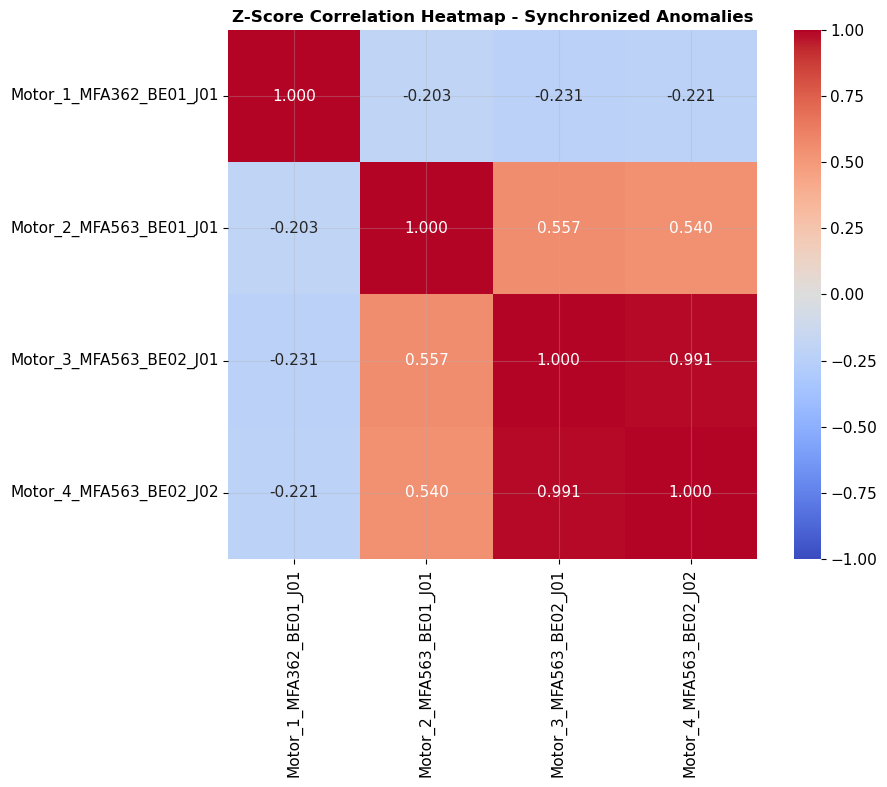

In [41]:
# Z-score statistical summary

z_score_stats = cement_mill_spc[[f'{motor}_ZScore' for motor in motor_cols]].describe()

print("Z-Score Statistical Summary")
print("=" * 80)
display(z_score_stats)

print("\n\nExtreme Z-Score Events (|Z| > 2.5):")
for motor in motor_cols:
    z_col = f'{motor}_ZScore'
    extreme_events = cement_mill_spc[abs(cement_mill_spc[z_col]) > 2.5][['Timestamp', motor, z_col, f'{motor}_SPC_Violation']]
    
    if len(extreme_events) > 0:
        print(f"\n{motor}:")
        display(extreme_events)
    else:
        print(f"\n{motor}: No extreme Z-score events")

print("\n\nCross-Motor Z-Score Correlation Matrix:")
z_score_cols = [f'{motor}_ZScore' for motor in motor_cols]
z_correlation = cement_mill_spc[z_score_cols].corr()
display(z_correlation)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(z_correlation, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=motor_cols, yticklabels=motor_cols)
ax.set_title('Z-Score Correlation Heatmap - Synchronized Anomalies', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [45]:
# Preparing and stating the required features to be considered in the dataset for the training of the isolationforest model

feature_columns = []

for motor in motor_cols:
    feature_columns.append(motor)
    feature_columns.append(f'{motor}_LoadFactor')
    feature_columns.append(f'{motor}_RollingMean_5min')
    feature_columns.append(f'{motor}_RollingStd_5min')
    feature_columns.append(f'{motor}_RateOfChange')

cement_mill_ml = cement_mill_spc.copy()

cement_mill_ml_features = cement_mill_ml[['Timestamp'] + feature_columns].copy()

cement_mill_ml_features = cement_mill_ml_features.fillna(method='bfill').fillna(method='ffill')

print(f"Feature Matrix for Isolation Forest")
print("=" * 80)
print(f"Total features: {len(feature_columns)}")
print(f"Total samples: {len(cement_mill_ml_features)}")
print(f"\nFeature categories:")
print(f"  Raw power readings      : {len(motor_cols)}")
print(f"  Load factors            : {len(motor_cols)}")
print(f"  Rolling means (5-min)   : {len(motor_cols)}")
print(f"  Rolling std dev (5-min) : {len(motor_cols)}")
print(f"  Rate of change          : {len(motor_cols)}")

print(f"\n\nFeature list:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n\nMissing values after imputation:")
print(cement_mill_ml_features[feature_columns].isnull().sum().sum())

print(f"\n\nFeature matrix summary statistics:")
display(cement_mill_ml_features[feature_columns].describe())

Feature Matrix for Isolation Forest
Total features: 20
Total samples: 240

Feature categories:
  Raw power readings      : 4
  Load factors            : 4
  Rolling means (5-min)   : 4
  Rolling std dev (5-min) : 4
  Rate of change          : 4


Feature list:
   1. Motor_1_MFA362_BE01_J01
   2. Motor_1_MFA362_BE01_J01_LoadFactor
   3. Motor_1_MFA362_BE01_J01_RollingMean_5min
   4. Motor_1_MFA362_BE01_J01_RollingStd_5min
   5. Motor_1_MFA362_BE01_J01_RateOfChange
   6. Motor_2_MFA563_BE01_J01
   7. Motor_2_MFA563_BE01_J01_LoadFactor
   8. Motor_2_MFA563_BE01_J01_RollingMean_5min
   9. Motor_2_MFA563_BE01_J01_RollingStd_5min
  10. Motor_2_MFA563_BE01_J01_RateOfChange
  11. Motor_3_MFA563_BE02_J01
  12. Motor_3_MFA563_BE02_J01_LoadFactor
  13. Motor_3_MFA563_BE02_J01_RollingMean_5min
  14. Motor_3_MFA563_BE02_J01_RollingStd_5min
  15. Motor_3_MFA563_BE02_J01_RateOfChange
  16. Motor_4_MFA563_BE02_J02
  17. Motor_4_MFA563_BE02_J02_LoadFactor
  18. Motor_4_MFA563_BE02_J02_RollingMean_5min


,Motor_1_MFA362_BE01_J01,Motor_1_MFA362_BE01_J01_LoadFactor,Motor_1_MFA362_BE01_J01_RollingMean_5min,Motor_1_MFA362_BE01_J01_RollingStd_5min,Motor_1_MFA362_BE01_J01_RateOfChange,Motor_2_MFA563_BE01_J01,Motor_2_MFA563_BE01_J01_LoadFactor,Motor_2_MFA563_BE01_J01_RollingMean_5min,Motor_2_MFA563_BE01_J01_RollingStd_5min,Motor_2_MFA563_BE01_J01_RateOfChange,Motor_3_MFA563_BE02_J01,Motor_3_MFA563_BE02_J01_LoadFactor,Motor_3_MFA563_BE02_J01_RollingMean_5min,Motor_3_MFA563_BE02_J01_RollingStd_5min,Motor_3_MFA563_BE02_J01_RateOfChange,Motor_4_MFA563_BE02_J02,Motor_4_MFA563_BE02_J02_LoadFactor,Motor_4_MFA563_BE02_J02_RollingMean_5min,Motor_4_MFA563_BE02_J02_RollingStd_5min,Motor_4_MFA563_BE02_J02_RateOfChange
count,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000
mean,13.0333,54.3053,13.0845,1.3417,-0.0349,36.6891,91.7227,36.6977,1.2291,-0.0021,64.3157,79.4021,64.2930,5.1723,-0.0096,73.2341,81.3713,73.2108,6.3578,-0.0139
std,4.4362,18.4840,4.0508,1.4442,2.1674,6.7149,16.7873,6.3592,2.0883,2.2383,9.6756,11.9452,8.2726,2.0917,6.9009,11.4759,12.7510,9.6812,2.5452,8.5783
min,0.0000,0.0000,0.0000,0.0000,-14.8580,8.1920,20.4800,8.8064,0.2142,-19.7120,33.2800,41.0864,35.6864,1.4068,-17.1520,38.4000,42.6667,40.6528,1.3715,-19.9680
25%,11.7728,49.0531,12.0241,0.6756,-0.8023,37.3760,93.4400,37.6832,0.6413,-0.7680,59.9040,73.9556,61.0816,3.6841,-4.4160,67.8400,75.3778,69.1712,4.6217,-5.8880
50%,13.9685,58.2021,14.0764,1.0371,0.0000,38.4000,96.0000,38.4512,0.7994,0.0000,65.0240,80.2765,63.9744,5.0276,0.0000,73.2160,81.3511,72.6784,6.1541,0.0000
75%,15.3600,64.0000,15.2136,1.3680,0.6900,39.1680,97.9200,38.9632,1.0304,0.7680,70.1440,86.5975,69.6576,6.5653,4.4160,80.4480,89.3867,79.6288,7.7526,5.4400
max,24.0640,100.2667,22.0160,8.0895,15.6160,41.7280,104.3200,40.5504,14.8562,13.3120,84.9920,104.9284,81.5104,12.2594,26.1120,101.6320,112.9244,94.0032,14.6319,32.2560


In [46]:
# Fitting the training dataset with the preferred ML model

X = cement_mill_ml_features[feature_columns].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature Scaling Complete")
print("=" * 80)
print(f"Original feature matrix shape: {X.shape}")
print(f"Scaled feature matrix shape  : {X_scaled.shape}")

print(f"\n\nScaling parameters (first 5 features):")
for i in range(min(5, len(feature_columns))):
    print(f"\n{feature_columns[i]}:")
    print(f"  Mean : {scaler.mean_[i]:.4f}")
    print(f"  Std  : {scaler.scale_[i]:.4f}")

print(f"\n\nScaled data sample (first 5 rows, first 5 features):")
print(X_scaled[:5, :5])

Feature Scaling Complete
Original feature matrix shape: (240, 20)
Scaled feature matrix shape  : (240, 20)


Scaling parameters (first 5 features):

Motor_1_MFA362_BE01_J01:
  Mean : 13.0333
  Std  : 4.4269

Motor_1_MFA362_BE01_J01_LoadFactor:
  Mean : 54.3053
  Std  : 18.4454

Motor_1_MFA362_BE01_J01_RollingMean_5min:
  Mean : 13.0845
  Std  : 4.0423

Motor_1_MFA362_BE01_J01_RollingStd_5min:
  Mean : 1.3417
  Std  : 1.4411

Motor_1_MFA362_BE01_J01_RateOfChange:
  Mean : -0.0349
  Std  : 2.1629


Scaled data sample (first 5 rows, first 5 features):
[[ 0.52558951  0.52558951  0.56292292 -0.93102337  0.0161512 ]
 [ 0.52558951  0.52558951  0.56292292 -0.93102337  0.0161512 ]
 [ 0.25768211  0.25768211  0.46512444 -0.45588739 -0.53218802]
 [-0.15118177 -0.15118177  0.30428466  0.05113723 -0.82069056]
 [ 0.16054866  0.16054866  0.27605832 -0.06221858  0.65418515]]


In [48]:
# preparation and training of the IsolationForest model based on the given/stated hyperparameters

contamination_rate = 0.10

iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=contamination_rate,
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print(f"Isolation Forest Model Configuration")
print("=" * 80)
print(f"Number of trees (n_estimators)  : {iso_forest.n_estimators}")
print(f"Contamination rate              : {iso_forest.contamination}")
print(f"Max samples per tree            : {iso_forest.max_samples}")
print(f"Max features per split          : {iso_forest.max_features}")
print(f"Bootstrap sampling              : {iso_forest.bootstrap}")
print(f"Random state (reproducibility)  : {iso_forest.random_state}")

print(f"\n\nTraining Isolation Forest...")
iso_forest.fit(X_scaled)

print(f"Training complete.")
print(f"Model trained on {X_scaled.shape[0]} samples with {X_scaled.shape[1]} features.")


Isolation Forest Model Configuration
Number of trees (n_estimators)  : 100
Contamination rate              : 0.1
Max samples per tree            : auto
Max features per split          : 1.0
Bootstrap sampling              : False
Random state (reproducibility)  : 42


Training Isolation Forest...
Training complete.
Model trained on 240 samples with 20 features.


In [51]:
# Testing the isolation forest model on both Normal and Anormaly detection 

cement_mill_ml_features['IF_Prediction'] = iso_forest.predict(X_scaled)

cement_mill_ml_features['IF_AnomalyScore'] = iso_forest.score_samples(X_scaled)

cement_mill_ml_features['IF_Anomaly'] = cement_mill_ml_features['IF_Prediction'].apply(
    lambda x: 'ANOMALY' if x == -1 else 'NORMAL'
)

anomaly_count = (cement_mill_ml_features['IF_Anomaly'] == 'ANOMALY').sum()
normal_count = (cement_mill_ml_features['IF_Anomaly'] == 'NORMAL').sum()

print(f"Isolation Forest Anomaly Detection Results")
print("=" * 80)
print(f"\nPrediction Distribution:")
print(f"  NORMAL   : {normal_count:3d} ({normal_count/len(cement_mill_ml_features)*100:.2f}%)")
print(f"  ANOMALY  : {anomaly_count:3d} ({anomaly_count/len(cement_mill_ml_features)*100:.2f}%)")

print(f"\n\nAnomaly Score Statistics:")
print(f"  Min score  : {cement_mill_ml_features['IF_AnomalyScore'].min():.6f}")
print(f"  Max score  : {cement_mill_ml_features['IF_AnomalyScore'].max():.6f}")
print(f"  Mean score : {cement_mill_ml_features['IF_AnomalyScore'].mean():.6f}")
print(f"  Median     : {cement_mill_ml_features['IF_AnomalyScore'].median():.6f}")

threshold = cement_mill_ml_features[cement_mill_ml_features['IF_Anomaly'] == 'ANOMALY']['IF_AnomalyScore'].max()
print(f"  Anomaly threshold: {threshold:.6f}")

print(f"\n\nTop 10 Most Anomalous Events (lowest anomaly scores):")
top_anomalies = cement_mill_ml_features.nsmallest(10, 'IF_AnomalyScore')[
    ['Timestamp', 'IF_AnomalyScore', 'IF_Anomaly'] + motor_cols[:4]
]
display(top_anomalies)

print(f"\n\nAll Detected Anomalies:")
all_anomalies = cement_mill_ml_features[cement_mill_ml_features['IF_Anomaly'] == 'ANOMALY'][
    ['Timestamp', 'IF_AnomalyScore'] + motor_cols
]
display(all_anomalies)

Isolation Forest Anomaly Detection Results

Prediction Distribution:
  NORMAL   : 216 (90.00%)
  ANOMALY  :  24 (10.00%)


Anomaly Score Statistics:
  Min score  : -0.637788
  Max score  : -0.343998
  Mean score : -0.416120
  Median     : -0.390132
  Anomaly threshold: -0.523684


Top 10 Most Anomalous Events (lowest anomaly scores):


,Timestamp,IF_AnomalyScore,IF_Anomaly,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
143,2026-05-04 13:31:00,-0.6378,ANOMALY,14.4960,9.9840,33.2800,38.4000
152,2026-05-04 13:40:00,-0.6073,ANOMALY,14.5350,34.5600,40.4480,45.3120
144,2026-05-04 13:32:00,-0.5954,ANOMALY,14.7010,8.9600,40.9600,44.8000
154,2026-05-04 13:42:00,-0.5787,ANOMALY,16.6400,34.5600,34.5600,40.7040
205,2026-05-04 14:33:00,-0.5761,ANOMALY,0.0000,39.4240,82.9440,96.7680
147,2026-05-04 13:35:00,-0.5736,ANOMALY,16.1280,8.1920,33.7920,38.4000
142,2026-05-04 13:30:00,-0.5704,ANOMALY,18.6880,9.2160,43.5200,49.6640
191,2026-05-04 14:19:00,-0.5701,ANOMALY,14.8180,40.1920,76.2880,87.8080
148,2026-05-04 13:36:00,-0.5694,ANOMALY,13.5960,9.4720,40.7040,45.8240
140,2026-05-04 13:28:00,-0.5687,ANOMALY,19.4560,10.2400,58.3680,67.3280




All Detected Anomalies:


,Timestamp,IF_AnomalyScore,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
105,2026-05-04 12:53:00,-0.5246,15.6160,38.6560,84.9920,99.8400
139,2026-05-04 13:27:00,-0.5575,17.1520,8.1920,58.8800,66.0480
140,2026-05-04 13:28:00,-0.5687,19.4560,10.2400,58.3680,67.3280
141,2026-05-04 13:29:00,-0.5612,16.1280,8.7040,50.1760,56.0640
142,2026-05-04 13:30:00,-0.5704,18.6880,9.2160,43.5200,49.6640
143,2026-05-04 13:31:00,-0.6378,14.4960,9.9840,33.2800,38.4000
144,2026-05-04 13:32:00,-0.5954,14.7010,8.9600,40.9600,44.8000
145,2026-05-04 13:33:00,-0.5495,15.8720,9.4720,34.5600,40.4480
146,2026-05-04 13:34:00,-0.5492,15.3000,8.7040,35.8400,41.2160
147,2026-05-04 13:35:00,-0.5736,16.1280,8.1920,33.7920,38.4000


In [53]:
# Detection method and comparism between IsolationForest an (SPC) Statistical Process Control

cement_mill_comparison = cement_mill_ml_features.copy()

for motor in motor_cols:
    cement_mill_comparison[f'{motor}_SPC'] = cement_mill_spc[f'{motor}_SPC_Violation']
    cement_mill_comparison[f'{motor}_LoadStatus'] = cement_mill_spc[f'{motor}_Status']

spc_anomaly_count = 0
for motor in motor_cols:
    spc_anomaly_count += (cement_mill_comparison[f'{motor}_SPC'] != 'IN_CONTROL').sum()

load_anomaly_count = 0
for motor in motor_cols:
    load_anomaly_count += (cement_mill_comparison[f'{motor}_LoadStatus'] != 'NORMAL').sum()

if_anomaly_count = (cement_mill_comparison['IF_Anomaly'] == 'ANOMALY').sum()

print(f"Detection Method Comparison")
print("=" * 80)
print(f"\nTotal anomalies detected by each method:")
print(f"  Isolation Forest         : {if_anomaly_count:3d} records")
print(f"  SPC (any motor violation): {spc_anomaly_count:3d} violations (across all motors)")
print(f"  Load Factor Thresholds   : {load_anomaly_count:3d} violations (across all motors)")

print(f"\n\nPer-Motor SPC vs Isolation Forest:")
for motor in motor_cols:
    spc_violations = (cement_mill_comparison[f'{motor}_SPC'] != 'IN_CONTROL').sum()
    if_at_spc_violation = cement_mill_comparison[
        (cement_mill_comparison[f'{motor}_SPC'] != 'IN_CONTROL') & 
        (cement_mill_comparison['IF_Anomaly'] == 'ANOMALY')
    ].shape[0]
    
    print(f"\n{motor}:")
    print(f"  SPC violations          : {spc_violations}")
    print(f"  IF detected at SPC times: {if_at_spc_violation}")
    if spc_violations > 0:
        print(f"  IF recall on SPC events : {if_at_spc_violation/spc_violations*100:.2f}%")

print(f"\n\nEvents detected by IF but not by SPC:")
if_only = cement_mill_comparison[
    (cement_mill_comparison['IF_Anomaly'] == 'ANOMALY') & 
    (cement_mill_comparison[[f'{m}_SPC' for m in motor_cols]].apply(
        lambda row: all(status == 'IN_CONTROL' for status in row), axis=1
    ))
][['Timestamp', 'IF_AnomalyScore'] + motor_cols]

print(f"Count: {len(if_only)}")
if len(if_only) > 0:
    display(if_only)
else:
    print("None")

print(f"\n\nEvents detected by SPC but not by IF:")
spc_only = cement_mill_comparison[
    (cement_mill_comparison['IF_Anomaly'] == 'NORMAL') & 
    (cement_mill_comparison[[f'{m}_SPC' for m in motor_cols]].apply(
        lambda row: any(status != 'IN_CONTROL' for status in row), axis=1
    ))
][['Timestamp'] + motor_cols + [f'{m}_SPC' for m in motor_cols]]

print(f"Count: {len(spc_only)}")
if len(spc_only) > 0:
    display(spc_only.head(10))
else:
    print("None")

Detection Method Comparison

Total anomalies detected by each method:
  Isolation Forest         :  24 records
  SPC (any motor violation):  64 violations (across all motors)
  Load Factor Thresholds   : 228 violations (across all motors)


Per-Motor SPC vs Isolation Forest:

Motor_1_MFA362_BE01_J01:
  SPC violations          : 20
  IF detected at SPC times: 6
  IF recall on SPC events : 30.00%

Motor_2_MFA563_BE01_J01:
  SPC violations          : 14
  IF detected at SPC times: 11
  IF recall on SPC events : 78.57%

Motor_3_MFA563_BE02_J01:
  SPC violations          : 14
  IF detected at SPC times: 12
  IF recall on SPC events : 85.71%

Motor_4_MFA563_BE02_J02:
  SPC violations          : 16
  IF detected at SPC times: 14
  IF recall on SPC events : 87.50%


Events detected by IF but not by SPC:
Count: 3


,Timestamp,IF_AnomalyScore,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
155,2026-05-04 13:43:00,-0.5438,13.9500,34.0480,45.0560,52.9920
191,2026-05-04 14:19:00,-0.5701,14.8180,40.1920,76.2880,87.8080
214,2026-05-04 14:42:00,-0.5261,15.6160,39.1680,81.9200,96.0000




Events detected by SPC but not by IF:
Count: 17


,Timestamp,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02,Motor_1_MFA362_BE01_J01_SPC,Motor_2_MFA563_BE01_J01_SPC,Motor_3_MFA563_BE02_J01_SPC,Motor_4_MFA563_BE02_J02_SPC
138,2026-05-04 13:26:00,17.1520,18.6880,61.4400,70.4000,IN_CONTROL,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL
149,2026-05-04 13:37:00,14.1740,9.2160,40.4480,45.8240,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
150,2026-05-04 13:38:00,14.7400,8.4480,39.6800,44.0320,IN_CONTROL,OUT_OF_CONTROL_3SIGMA,WARNING_2SIGMA,WARNING_2SIGMA
196,2026-05-04 14:24:00,0.0000,38.4000,67.5840,77.8240,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL
197,2026-05-04 14:25:00,0.0000,39.4240,70.1440,79.6160,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL
198,2026-05-04 14:26:00,0.0000,39.1680,67.0720,77.8240,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL
199,2026-05-04 14:27:00,0.0000,37.8880,61.6960,68.3520,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL
200,2026-05-04 14:28:00,0.0000,37.3760,69.3760,78.8480,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL
201,2026-05-04 14:29:00,0.0000,37.8880,77.0560,87.5520,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL
202,2026-05-04 14:30:00,0.0000,39.6800,73.9840,84.2240,WARNING_2SIGMA,IN_CONTROL,IN_CONTROL,IN_CONTROL


In [54]:
contamination_rates = [0.05, 0.08, 0.10, 0.12, 0.15]

known_critical_events = {
    'Motor_2_Crash': list(range(139, 155)),
    'Overload_Spike_1253': [105],
    'Motor_1_Dropout': list(range(196, 212)),
    'Overload_Spike_1450': [222],
    'Overload_Spike_1451': [223]
}

total_known_events = set()
for events in known_critical_events.values():
    total_known_events.update(events)

contamination_results = []

for cont_rate in contamination_rates:
    
    iso_forest_test = IsolationForest(
        n_estimators=100,
        max_samples='auto',
        contamination=cont_rate,
        max_features=1.0,
        bootstrap=False,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    iso_forest_test.fit(X_scaled)
    
    predictions = iso_forest_test.predict(X_scaled)
    anomaly_scores = iso_forest_test.score_samples(X_scaled)
    
    anomalies_detected = np.where(predictions == -1)[0]
    
    true_positives = len(set(anomalies_detected).intersection(total_known_events))
    false_positives = len(set(anomalies_detected) - total_known_events)
    false_negatives = len(total_known_events - set(anomalies_detected))
    
    precision = true_positives / len(anomalies_detected) if len(anomalies_detected) > 0 else 0
    recall = true_positives / len(total_known_events) if len(total_known_events) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    event_detection = {}
    for event_name, event_indices in known_critical_events.items():
        detected = len(set(anomalies_detected).intersection(set(event_indices)))
        total = len(event_indices)
        event_detection[event_name] = f"{detected}/{total}"
    
    contamination_results.append({
        'Contamination_Rate': cont_rate,
        'Total_Anomalies': len(anomalies_detected),
        'True_Positives': true_positives,
        'False_Positives': false_positives,
        'False_Negatives': false_negatives,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1_score,
        'Motor_2_Crash': event_detection['Motor_2_Crash'],
        'Overload_1253': event_detection['Overload_Spike_1253'],
        'Motor_1_Dropout': event_detection['Motor_1_Dropout'],
        'Overload_1450': event_detection['Overload_Spike_1450'],
        'Overload_1451': event_detection['Overload_Spike_1451']
    })

results_df = pd.DataFrame(contamination_results)

print("Contamination Rate Optimization - Performance Comparison")
print("=" * 100)
print(f"\nTotal known critical events in dataset: {len(total_known_events)}")
print(f"Event breakdown:")
for event_name, event_indices in known_critical_events.items():
    print(f"  {event_name:25s}: {len(event_indices)} timestamps")

print(f"\n\nPerformance Metrics Across Contamination Rates:")
display(results_df)

print(f"\n\nDetailed Analysis by Contamination Rate:")
for idx, row in results_df.iterrows():
    print(f"\n{'='*80}")
    print(f"Contamination Rate: {row['Contamination_Rate']:.2f}")
    print(f"{'='*80}")
    print(f"  Total Anomalies Flagged : {row['Total_Anomalies']}")
    print(f"  True Positives          : {row['True_Positives']} (correctly identified known events)")
    print(f"  False Positives         : {row['False_Positives']} (flagged but not in known events)")
    print(f"  False Negatives         : {row['False_Negatives']} (missed known events)")
    print(f"  Precision               : {row['Precision']:.4f}")
    print(f"  Recall                  : {row['Recall']:.4f}")
    print(f"  F1 Score                : {row['F1_Score']:.4f}")
    print(f"\n  Event Detection:")
    print(f"    Motor 2 Crash (13:27-13:42)  : {row['Motor_2_Crash']}")
    print(f"    Overload Spike (12:53)       : {row['Overload_1253']}")
    print(f"    Motor 1 Dropout (14:24-14:38): {row['Motor_1_Dropout']}")
    print(f"    Overload Spike (14:50)       : {row['Overload_1450']}")
    print(f"    Overload Spike (14:51)       : {row['Overload_1451']}")

best_f1_idx = results_df['F1_Score'].idxmax()
best_recall_idx = results_df['Recall'].idxmax()

print(f"\n\n{'='*100}")
print(f"RECOMMENDATION")
print(f"{'='*100}")
print(f"Best F1 Score     : {results_df.loc[best_f1_idx, 'Contamination_Rate']:.2f} "
      f"(F1={results_df.loc[best_f1_idx, 'F1_Score']:.4f})")
print(f"Best Recall       : {results_df.loc[best_recall_idx, 'Contamination_Rate']:.2f} "
      f"(Recall={results_df.loc[best_recall_idx, 'Recall']:.4f})")

Contamination Rate Optimization - Performance Comparison

Total known critical events in dataset: 35
Event breakdown:
  Motor_2_Crash            : 16 timestamps
  Overload_Spike_1253      : 1 timestamps
  Motor_1_Dropout          : 16 timestamps
  Overload_Spike_1450      : 1 timestamps
  Overload_Spike_1451      : 1 timestamps


Performance Metrics Across Contamination Rates:


,Contamination_Rate,Total_Anomalies,True_Positives,False_Positives,False_Negatives,Precision,Recall,F1_Score,Motor_2_Crash,Overload_1253,Motor_1_Dropout,Overload_1450,Overload_1451
0,0.0500,12,11,1,24,0.9167,0.3143,0.4681,10/16,0/1,1/16,0/1,0/1
1,0.0800,20,18,2,17,0.9000,0.5143,0.6545,14/16,0/1,2/16,1/1,1/1
2,0.1000,24,21,3,14,0.8750,0.6000,0.7119,14/16,1/1,4/16,1/1,1/1
3,0.1200,29,26,3,9,0.8966,0.7429,0.8125,16/16,1/1,7/16,1/1,1/1
4,0.1500,36,27,9,8,0.7500,0.7714,0.7606,16/16,1/1,8/16,1/1,1/1




Detailed Analysis by Contamination Rate:

Contamination Rate: 0.05
  Total Anomalies Flagged : 12
  True Positives          : 11 (correctly identified known events)
  False Positives         : 1 (flagged but not in known events)
  False Negatives         : 24 (missed known events)
  Precision               : 0.9167
  Recall                  : 0.3143
  F1 Score                : 0.4681

  Event Detection:
    Motor 2 Crash (13:27-13:42)  : 10/16
    Overload Spike (12:53)       : 0/1
    Motor 1 Dropout (14:24-14:38): 1/16
    Overload Spike (14:50)       : 0/1
    Overload Spike (14:51)       : 0/1

Contamination Rate: 0.08
  Total Anomalies Flagged : 20
  True Positives          : 18 (correctly identified known events)
  False Positives         : 2 (flagged but not in known events)
  False Negatives         : 17 (missed known events)
  Precision               : 0.9000
  Recall                  : 0.5143
  F1 Score                : 0.6545

  Event Detection:
    Motor 2 Crash (13:27-13

In [59]:
optimal_contamination = 0.12

iso_forest_final = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=optimal_contamination,
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print(f"Final Isolation Forest Model - Training with Optimal Parameters")
print("=" * 80)
print(f"Contamination rate (optimized): {optimal_contamination}")
print(f"Expected anomalies            : {int(optimal_contamination * len(X_scaled))}")
print(f"\nTraining model...")

iso_forest_final.fit(X_scaled)

cement_mill_ml_features['IF_Final_Prediction'] = iso_forest_final.predict(X_scaled)
cement_mill_ml_features['IF_Final_AnomalyScore'] = iso_forest_final.score_samples(X_scaled)
cement_mill_ml_features['IF_Final_Anomaly'] = cement_mill_ml_features['IF_Final_Prediction'].apply(
    lambda x: 'ANOMALY' if x == -1 else 'NORMAL'
)

anomaly_count_final = (cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY').sum()
normal_count_final = (cement_mill_ml_features['IF_Final_Anomaly'] == 'NORMAL').sum()

print(f"\nTraining complete.")
print(f"\nFinal Model Results:")
print(f"  NORMAL   : {normal_count_final:3d} ({normal_count_final/len(cement_mill_ml_features)*100:.2f}%)")
print(f"  ANOMALY  : {anomaly_count_final:3d} ({anomaly_count_final/len(cement_mill_ml_features)*100:.2f}%)")

print(f"\nAnomaly Score Statistics:")
print(f"  Min score       : {cement_mill_ml_features['IF_Final_AnomalyScore'].min():.6f}")
print(f"  Max score       : {cement_mill_ml_features['IF_Final_AnomalyScore'].max():.6f}")
print(f"  Mean score      : {cement_mill_ml_features['IF_Final_AnomalyScore'].mean():.6f}")
print(f"  Median score    : {cement_mill_ml_features['IF_Final_AnomalyScore'].median():.6f}")
print(f"  Std deviation   : {cement_mill_ml_features['IF_Final_AnomalyScore'].std():.6f}")

threshold_final = cement_mill_ml_features[cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY']['IF_Final_AnomalyScore'].max()
print(f"  Anomaly threshold: {threshold_final:.6f}")

print(f"\n\nAll Detected Anomalies (Final Model):")
final_anomalies = cement_mill_ml_features[cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY'][
    ['Timestamp', 'IF_Final_AnomalyScore'] + motor_cols
].sort_values('IF_Final_AnomalyScore')

display(final_anomalies)

print(f"\n\nKnown Event Detection Validation:")
for event_name, event_indices in known_critical_events.items():
    detected_indices = cement_mill_ml_features[
        (cement_mill_ml_features.index.isin(event_indices)) & 
        (cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY')
    ].index.tolist()
    
    detected_count = len(detected_indices)
    total_count = len(event_indices)
    detection_rate = (detected_count / total_count * 100) if total_count > 0 else 0
    
    print(f"\n{event_name:30s}: {detected_count:2d}/{total_count:2d} ({detection_rate:5.1f}%)")
    
    if detected_count < total_count:
        missed = set(event_indices) - set(detected_indices)
        print(f"  Missed timestamps: {sorted(list(missed))}")

print(f"\n\nModel successfully trained and validated.")
print(f"Ready for visualization and hybrid system integration.")

Final Isolation Forest Model - Training with Optimal Parameters
Contamination rate (optimized): 0.12
Expected anomalies            : 28

Training model...

Training complete.

Final Model Results:
  NORMAL   : 211 (87.92%)
  ANOMALY  :  29 (12.08%)

Anomaly Score Statistics:
  Min score       : -0.637788
  Max score       : -0.343998
  Mean score      : -0.416120
  Median score    : -0.390132
  Std deviation   : 0.064796
  Anomaly threshold: -0.510212


All Detected Anomalies (Final Model):


,Timestamp,IF_Final_AnomalyScore,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
143,2026-05-04 13:31:00,-0.6378,14.4960,9.9840,33.2800,38.4000
152,2026-05-04 13:40:00,-0.6073,14.5350,34.5600,40.4480,45.3120
144,2026-05-04 13:32:00,-0.5954,14.7010,8.9600,40.9600,44.8000
154,2026-05-04 13:42:00,-0.5787,16.6400,34.5600,34.5600,40.7040
205,2026-05-04 14:33:00,-0.5761,0.0000,39.4240,82.9440,96.7680
147,2026-05-04 13:35:00,-0.5736,16.1280,8.1920,33.7920,38.4000
142,2026-05-04 13:30:00,-0.5704,18.6880,9.2160,43.5200,49.6640
191,2026-05-04 14:19:00,-0.5701,14.8180,40.1920,76.2880,87.8080
148,2026-05-04 13:36:00,-0.5694,13.5960,9.4720,40.7040,45.8240
140,2026-05-04 13:28:00,-0.5687,19.4560,10.2400,58.3680,67.3280




Known Event Detection Validation:

Motor_2_Crash                 : 16/16 (100.0%)

Overload_Spike_1253           :  1/ 1 (100.0%)

Motor_1_Dropout               :  7/16 ( 43.8%)
  Missed timestamps: [197, 198, 200, 201, 202, 203, 204, 207, 208]

Overload_Spike_1450           :  1/ 1 (100.0%)

Overload_Spike_1451           :  1/ 1 (100.0%)


Model successfully trained and validated.
Ready for visualization and hybrid system integration.


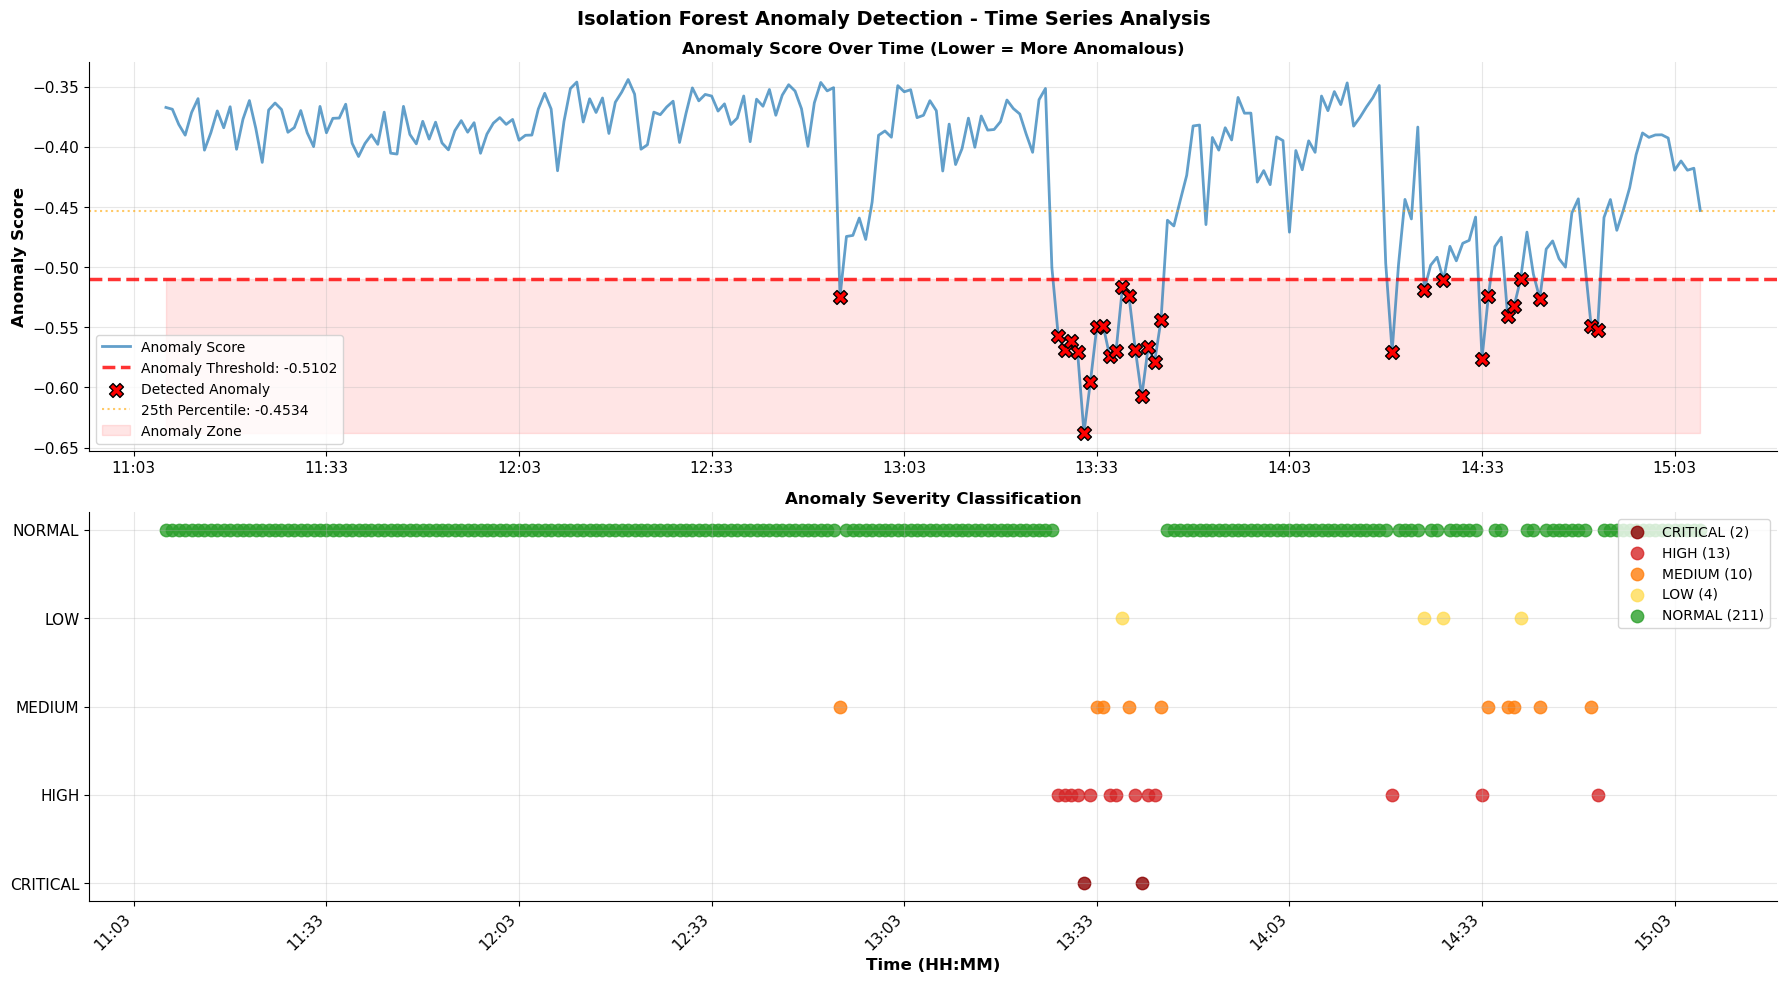

Anomaly severity distribution:
Severity_Band
CRITICAL      2
HIGH         13
LOW           4
MEDIUM       10
NORMAL      211
Name: count, dtype: int64


Critical and High Severity Events:


,Timestamp,IF_Final_AnomalyScore,Severity_Band,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
143,2026-05-04 13:31:00,-0.6378,CRITICAL,14.4960,9.9840,33.2800,38.4000
152,2026-05-04 13:40:00,-0.6073,CRITICAL,14.5350,34.5600,40.4480,45.3120
144,2026-05-04 13:32:00,-0.5954,HIGH,14.7010,8.9600,40.9600,44.8000
154,2026-05-04 13:42:00,-0.5787,HIGH,16.6400,34.5600,34.5600,40.7040
205,2026-05-04 14:33:00,-0.5761,HIGH,0.0000,39.4240,82.9440,96.7680
147,2026-05-04 13:35:00,-0.5736,HIGH,16.1280,8.1920,33.7920,38.4000
142,2026-05-04 13:30:00,-0.5704,HIGH,18.6880,9.2160,43.5200,49.6640
191,2026-05-04 14:19:00,-0.5701,HIGH,14.8180,40.1920,76.2880,87.8080
148,2026-05-04 13:36:00,-0.5694,HIGH,13.5960,9.4720,40.7040,45.8240
140,2026-05-04 13:28:00,-0.5687,HIGH,19.4560,10.2400,58.3680,67.3280


In [63]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Isolation Forest Anomaly Detection - Time Series Analysis', 
             fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(cement_mill_ml_features['Timestamp'], cement_mill_ml_features['IF_Final_AnomalyScore'], 
         linewidth=2, color='#1f77b4', alpha=0.7, label='Anomaly Score')

threshold = cement_mill_ml_features[cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY']['IF_Final_AnomalyScore'].max()
ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=2.5, 
           label=f'Anomaly Threshold: {threshold:.4f}', alpha=0.8)

anomalies = cement_mill_ml_features[cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY']
ax1.scatter(anomalies['Timestamp'], anomalies['IF_Final_AnomalyScore'], 
           color='red', s=100, marker='X', zorder=5, label='Detected Anomaly', edgecolors='black')

percentile_25 = cement_mill_ml_features['IF_Final_AnomalyScore'].quantile(0.25)
ax1.axhline(y=percentile_25, color='orange', linestyle=':', linewidth=1.5, 
           label=f'25th Percentile: {percentile_25:.4f}', alpha=0.6)

ax1.fill_between(cement_mill_ml_features['Timestamp'], 
                 cement_mill_ml_features['IF_Final_AnomalyScore'].min(), 
                 threshold, alpha=0.1, color='red', label='Anomaly Zone')

ax1.set_ylabel('Anomaly Score', fontweight='bold', fontsize=12)
ax1.set_title('Anomaly Score Over Time (Lower = More Anomalous)', fontweight='bold', fontsize=12)
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

ax2 = axes[1]

severity_bands = []
for idx, row in cement_mill_ml_features.iterrows():
    score = row['IF_Final_AnomalyScore']
    if row['IF_Final_Anomaly'] == 'ANOMALY':
        if score < -0.60:
            severity_bands.append('CRITICAL')
        elif score < -0.55:
            severity_bands.append('HIGH')
        elif score < -0.52:
            severity_bands.append('MEDIUM')
        else:
            severity_bands.append('LOW')
    else:
        severity_bands.append('NORMAL')

cement_mill_ml_features['Severity_Band'] = severity_bands

severity_colors = {
    'CRITICAL': '#8b0000',
    'HIGH': '#d62728',
    'MEDIUM': '#ff7f0e',
    'LOW': '#ffdd57',
    'NORMAL': '#2ca02c'
}

for severity, color in severity_colors.items():
    mask = cement_mill_ml_features['Severity_Band'] == severity
    if mask.sum() > 0:
        ax2.scatter(cement_mill_ml_features[mask]['Timestamp'], 
                   [severity] * mask.sum(),
                   c=color, s=80, alpha=0.8, label=f'{severity} ({mask.sum()})')

ax2.set_yticks(range(len(severity_colors)))
ax2.set_yticklabels(list(severity_colors.keys()))
ax2.set_xlabel('Time (HH:MM)', fontweight='bold', fontsize=12)
ax2.set_title('Anomaly Severity Classification', fontweight='bold', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Anomaly severity distribution:")
print(cement_mill_ml_features['Severity_Band'].value_counts().sort_index())

print("\n\nCritical and High Severity Events:")
critical_high = cement_mill_ml_features[cement_mill_ml_features['Severity_Band'].isin(['CRITICAL', 'HIGH'])][
    ['Timestamp', 'IF_Final_AnomalyScore', 'Severity_Band'] + motor_cols
]
display(critical_high.sort_values('IF_Final_AnomalyScore'))

In [69]:
cement_mill_hybrid = cement_mill_ml_features.copy()

for motor in motor_cols:
    cement_mill_hybrid[f'{motor}_SPC_Violation'] = cement_mill_spc[f'{motor}_SPC_Violation']
    cement_mill_hybrid[f'{motor}_Status'] = cement_mill_spc[f'{motor}_Status']
    cement_mill_hybrid[f'{motor}_LoadFactor'] = cement_mill_spc[f'{motor}_LoadFactor']
    cement_mill_hybrid[f'{motor}_ZScore'] = cement_mill_spc[f'{motor}_ZScore']

def compute_load_factor_score(row):
    score = 0
    for motor in motor_cols:
        status = row[f'{motor}_Status']
        if status == 'CRITICAL_OVERLOAD':
            score += 1.0
        elif status == 'OVERLOAD_ALERT':
            score += 0.75
        elif status == 'HIGH_LOAD_WARNING':
            score += 0.35
        elif status == 'LOW_LOAD_WARNING':
            score += 0.50
        elif status == 'CRITICAL_UNDERLOAD':
            score += 0.85
        elif status == 'MOTOR_STOPPED':
            score += 0.90
        elif status == 'SENSOR_DROPOUT':
            score += 0.70
        else:
            score += 0.0
    return score / len(motor_cols)

def compute_spc_score(row):
    score = 0
    for motor in motor_cols:
        violation = row[f'{motor}_SPC_Violation']
        if violation == 'OUT_OF_CONTROL_3SIGMA':
            score += 1.0
        elif violation == 'WARNING_2SIGMA':
            score += 0.50
        else:
            score += 0.0
    return score / len(motor_cols)

def compute_if_score(anomaly_score):
    min_score = cement_mill_hybrid['IF_Final_AnomalyScore'].min()
    max_score = cement_mill_hybrid['IF_Final_AnomalyScore'].max()
    normalized = (anomaly_score - max_score) / (min_score - max_score)
    return float(np.clip(normalized, 0, 1))

cement_mill_hybrid['LF_Score'] = cement_mill_hybrid.apply(compute_load_factor_score, axis=1)
cement_mill_hybrid['SPC_Score'] = cement_mill_hybrid.apply(compute_spc_score, axis=1)
cement_mill_hybrid['IF_Score'] = cement_mill_hybrid['IF_Final_AnomalyScore'].apply(compute_if_score)

weight_if = 0.45
weight_lf = 0.35
weight_spc = 0.20

cement_mill_hybrid['Hybrid_Score'] = (
    (weight_if * cement_mill_hybrid['IF_Score']) +
    (weight_lf * cement_mill_hybrid['LF_Score']) +
    (weight_spc * cement_mill_hybrid['SPC_Score'])
)

def classify_hybrid_severity(score):
    if score >= 0.75:
        return 'CRITICAL'
    elif score >= 0.50:
        return 'HIGH'
    elif score >= 0.30:
        return 'MEDIUM'
    elif score >= 0.10:
        return 'LOW'
    else:
        return 'NORMAL'

cement_mill_hybrid['Hybrid_Severity'] = cement_mill_hybrid['Hybrid_Score'].apply(classify_hybrid_severity)

print(f"Hybrid Anomaly Scoring System Results")
print("=" * 80)
print(f"\nWeighting Configuration:")
print(f"  Isolation Forest (multivariate process detection) : {weight_if:.0%}")
print(f"  Load Factor (engineering threshold violations)    : {weight_lf:.0%}")
print(f"  SPC (statistical process control)                 : {weight_spc:.0%}")

print(f"\n\nHybrid Severity Distribution:")
hybrid_dist = cement_mill_hybrid['Hybrid_Severity'].value_counts()
for severity in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'NORMAL']:
    count = hybrid_dist.get(severity, 0)
    pct = count / len(cement_mill_hybrid) * 100
    print(f"  {severity:10s}: {count:3d} ({pct:5.2f}%)")

print(f"\n\nComponent Score Statistics:")
score_summary = cement_mill_hybrid[['IF_Score', 'LF_Score', 'SPC_Score', 'Hybrid_Score']].describe()
display(score_summary)

print(f"\n\nAll Non-Normal Events - Hybrid Scoring:")
hybrid_anomalies = cement_mill_hybrid[cement_mill_hybrid['Hybrid_Severity'] != 'NORMAL'][
    ['Timestamp', 'IF_Score', 'LF_Score', 'SPC_Score', 
     'Hybrid_Score', 'Hybrid_Severity'] + motor_cols
].sort_values('Hybrid_Score', ascending=False)
display(hybrid_anomalies)

print(f"\n\nKnown Event Coverage Validation:")
for event_name, event_indices in known_critical_events.items():
    detected = cement_mill_hybrid[
        (cement_mill_hybrid.index.isin(event_indices)) &
        (cement_mill_hybrid['Hybrid_Severity'] != 'NORMAL')
    ]
    detected_count = len(detected)
    total_count = len(event_indices)
    pct = detected_count / total_count * 100
    print(f"\n{event_name:30s}: {detected_count:2d}/{total_count:2d} ({pct:5.1f}%)")
    if detected_count < total_count:
        missed_idx = set(event_indices) - set(detected.index.tolist())
        print(f"  Missed timestamps: {sorted(list(missed_idx))}")
    
    severity_breakdown = detected['Hybrid_Severity'].value_counts()
    for sev, cnt in severity_breakdown.items():
        print(f"  {sev:10s}: {cnt} events")

Hybrid Anomaly Scoring System Results

Weighting Configuration:
  Isolation Forest (multivariate process detection) : 45%
  Load Factor (engineering threshold violations)    : 35%
  SPC (statistical process control)                 : 20%


Hybrid Severity Distribution:
  CRITICAL  :   0 ( 0.00%)
  HIGH      :   7 ( 2.92%)
  MEDIUM    :  39 (16.25%)
  LOW       :  69 (28.75%)
  NORMAL    : 125 (52.08%)


Component Score Statistics:


,IF_Score,LF_Score,SPC_Score,Hybrid_Score
count,240.0000,240.0000,240.0000,240.0000
mean,0.2455,0.1129,0.0427,0.1585
std,0.2206,0.1313,0.1237,0.1445
min,-0.0000,0.0000,0.0000,0.0043
25%,0.0888,0.0000,0.0000,0.0600
50%,0.1570,0.0875,0.0000,0.0954
75%,0.3724,0.1750,0.0000,0.2234
max,1.0000,0.7000,0.7500,0.6505




All Non-Normal Events - Hybrid Scoring:


,Timestamp,IF_Score,LF_Score,SPC_Score,Hybrid_Score,Hybrid_Severity,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
205,2026-05-04 14:33:00,0.7900,0.7000,0.2500,0.6505,HIGH,0.0000,39.4240,82.9440,96.7680
143,2026-05-04 13:31:00,1.0000,0.1250,0.7500,0.6438,HIGH,14.4960,9.9840,33.2800,38.4000
222,2026-05-04 14:50:00,0.6970,0.5250,0.2500,0.5474,HIGH,22.0160,38.4000,83.4560,101.6320
147,2026-05-04 13:35:00,0.7816,0.1250,0.7500,0.5454,HIGH,16.1280,8.1920,33.7920,38.4000
209,2026-05-04 14:37:00,0.6694,0.6125,0.1250,0.5406,HIGH,0.0000,37.8880,81.9200,95.7440
...,...,...,...,...,...,...,...,...,...,...
1,2026-05-04 11:09:00,0.0841,0.1875,0.0000,0.1035,LOW,15.3600,40.7040,64.7680,73.2160
56,2026-05-04 12:04:00,0.1578,0.0875,0.0000,0.1016,LOW,11.0160,38.1440,60.4160,69.6320
57,2026-05-04 12:05:00,0.1572,0.0875,0.0000,0.1014,LOW,12.3640,39.4240,55.0400,63.4880
233,2026-05-04 15:01:00,0.1564,0.0875,0.0000,0.1010,LOW,10.0410,39.4240,70.1440,80.8960




Known Event Coverage Validation:

Motor_2_Crash                 : 16/16 (100.0%)
  MEDIUM    : 13 events
  HIGH      : 3 events

Overload_Spike_1253           :  1/ 1 (100.0%)
  HIGH      : 1 events

Motor_1_Dropout               : 16/16 (100.0%)
  MEDIUM    : 12 events
  LOW       : 2 events
  HIGH      : 2 events

Overload_Spike_1450           :  1/ 1 (100.0%)
  HIGH      : 1 events

Overload_Spike_1451           :  1/ 1 (100.0%)
  MEDIUM    : 1 events


In [72]:
cement_mill_hybrid['LF_Score'] = cement_mill_hybrid.apply(compute_load_factor_score, axis=1)

def compute_load_factor_score_v2(row):
    score = 0
    for motor in motor_cols:
        status = row[f'{motor}_Status']
        if status == 'CRITICAL_OVERLOAD':
            score += 1.00
        elif status == 'MOTOR_STOPPED':
            score += 1.00
        elif status == 'CRITICAL_UNDERLOAD':
            score += 1.00
        elif status == 'OVERLOAD_ALERT':
            score += 0.80
        elif status == 'SENSOR_DROPOUT':
            score += 0.75
        elif status == 'LOW_LOAD_WARNING':
            score += 0.65
        elif status == 'HIGH_LOAD_WARNING':
            score += 0.20
        else:
            score += 0.00
    return score / len(motor_cols)

cement_mill_hybrid['LF_Score_v2'] = cement_mill_hybrid.apply(compute_load_factor_score_v2, axis=1)

weight_if = 0.45
weight_lf = 0.35
weight_spc = 0.20

cement_mill_hybrid['Hybrid_Score_v2'] = (
    (weight_if * cement_mill_hybrid['IF_Score']) +
    (weight_lf * cement_mill_hybrid['LF_Score_v2']) +
    (weight_spc * cement_mill_hybrid['SPC_Score'])
)

score_distribution = cement_mill_hybrid['Hybrid_Score_v2'].describe(
    percentiles=[0.80, 0.88, 0.95, 0.98]
)
print("Hybrid Score v2 Distribution:")
display(score_distribution)

p98 = cement_mill_hybrid['Hybrid_Score_v2'].quantile(0.98)
p95 = cement_mill_hybrid['Hybrid_Score_v2'].quantile(0.95)
p88 = cement_mill_hybrid['Hybrid_Score_v2'].quantile(0.88)
p80 = cement_mill_hybrid['Hybrid_Score_v2'].quantile(0.80)

print(f"\nPercentile-based Thresholds:")
print(f"  98th percentile (CRITICAL threshold): {p98:.4f}")
print(f"  95th percentile (HIGH threshold)    : {p95:.4f}")
print(f"  88th percentile (MEDIUM threshold)  : {p88:.4f}")
print(f"  80th percentile (LOW threshold)     : {p80:.4f}")

def classify_hybrid_severity_v2(score):
    if score >= p98:
        return 'CRITICAL'
    elif score >= p95:
        return 'HIGH'
    elif score >= p88:
        return 'MEDIUM'
    elif score >= p80:
        return 'LOW'
    else:
        return 'NORMAL'

cement_mill_hybrid['Hybrid_Severity_v2'] = cement_mill_hybrid['Hybrid_Score_v2'].apply(
    classify_hybrid_severity_v2
)

print(f"\n\nRecalibrated Hybrid Severity Distribution:")
for severity in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'NORMAL']:
    count = (cement_mill_hybrid['Hybrid_Severity_v2'] == severity).sum()
    pct = count / len(cement_mill_hybrid) * 100
    print(f"  {severity:10s}: {count:3d} ({pct:5.2f}%)")

print(f"\n\nKnown Event Coverage Validation (v2):")
for event_name, event_indices in known_critical_events.items():
    detected = cement_mill_hybrid[
        (cement_mill_hybrid.index.isin(event_indices)) &
        (cement_mill_hybrid['Hybrid_Severity_v2'] != 'NORMAL')
    ]
    detected_count = len(detected)
    total_count = len(event_indices)
    pct = detected_count / total_count * 100
    print(f"\n{event_name:30s}: {detected_count:2d}/{total_count:2d} ({pct:5.1f}%)")
    severity_breakdown = detected['Hybrid_Severity_v2'].value_counts()
    for sev, cnt in severity_breakdown.items():
        print(f"  {sev:10s}: {cnt} events")

print(f"\n\nTop 15 Events by Hybrid Score v2:")
top_events = cement_mill_hybrid.nlargest(15, 'Hybrid_Score_v2')[
    ['Timestamp', 'IF_Score', 'LF_Score_v2', 'SPC_Score',
     'Hybrid_Score_v2', 'Hybrid_Severity_v2'] + motor_cols
]
display(top_events)

print(f"\n\nComparison: Original vs Recalibrated Severity:")
comparison = pd.DataFrame({
    'Timestamp': cement_mill_hybrid['Timestamp'],
    'Hybrid_Score_v1': cement_mill_hybrid['Hybrid_Score'],
    'Hybrid_Severity_v1': cement_mill_hybrid['Hybrid_Severity'],
    'Hybrid_Score_v2': cement_mill_hybrid['Hybrid_Score_v2'],
    'Hybrid_Severity_v2': cement_mill_hybrid['Hybrid_Severity_v2']
})

changed = comparison[comparison['Hybrid_Severity_v1'] != comparison['Hybrid_Severity_v2']]
print(f"Events with changed severity classification: {len(changed)}")
display(changed.head(20))

Hybrid Score v2 Distribution:


count   240.0000
mean      0.1524
std       0.1463
min       0.0043
50%       0.0875
80%       0.2736
88%       0.3739
95%       0.4545
98%       0.5394
max       0.6569
Name: Hybrid_Score_v2, dtype: float64


Percentile-based Thresholds:
  98th percentile (CRITICAL threshold): 0.5394
  95th percentile (HIGH threshold)    : 0.4545
  88th percentile (MEDIUM threshold)  : 0.3739
  80th percentile (LOW threshold)     : 0.2736


Recalibrated Hybrid Severity Distribution:
  CRITICAL  :   5 ( 2.08%)
  HIGH      :   7 ( 2.92%)
  MEDIUM    :  17 ( 7.08%)
  LOW       :  19 ( 7.92%)
  NORMAL    : 192 (80.00%)


Known Event Coverage Validation (v2):

Motor_2_Crash                 : 16/16 (100.0%)
  MEDIUM    : 9 events
  HIGH      : 4 events
  CRITICAL  : 3 events

Overload_Spike_1253           :  1/ 1 (100.0%)
  HIGH      : 1 events

Motor_1_Dropout               : 16/16 (100.0%)
  LOW       : 10 events
  MEDIUM    : 4 events
  CRITICAL  : 2 events

Overload_Spike_1450           :  1/ 1 (100.0%)
  HIGH      : 1 events

Overload_Spike_1451           :  1/ 1 (100.0%)
  MEDIUM    : 1 events


Top 15 Events by Hybrid Score v2:


,Timestamp,IF_Score,LF_Score_v2,SPC_Score,Hybrid_Score_v2,Hybrid_Severity_v2,Motor_1_MFA362_BE01_J01,Motor_2_MFA563_BE01_J01,Motor_3_MFA563_BE02_J01,Motor_4_MFA563_BE02_J02
143,2026-05-04 13:31:00,1.0000,0.1625,0.7500,0.6569,CRITICAL,14.4960,9.9840,33.2800,38.4000
205,2026-05-04 14:33:00,0.7900,0.6875,0.2500,0.6461,CRITICAL,0.0000,39.4240,82.9440,96.7680
147,2026-05-04 13:35:00,0.7816,0.1625,0.7500,0.5586,CRITICAL,16.1280,8.1920,33.7920,38.4000
209,2026-05-04 14:37:00,0.6694,0.6375,0.1250,0.5493,CRITICAL,0.0000,37.8880,81.9200,95.7440
144,2026-05-04 13:32:00,0.8557,0.1625,0.5000,0.5419,CRITICAL,14.7010,8.9600,40.9600,44.8000
222,2026-05-04 14:50:00,0.6970,0.5000,0.2500,0.5387,HIGH,22.0160,38.4000,83.4560,101.6320
142,2026-05-04 13:30:00,0.7706,0.1625,0.5000,0.5036,HIGH,18.6880,9.2160,43.5200,49.6640
148,2026-05-04 13:36:00,0.7672,0.1625,0.5000,0.5021,HIGH,13.5960,9.4720,40.7040,45.8240
105,2026-05-04 12:53:00,0.6146,0.5000,0.2500,0.5016,HIGH,15.6160,38.6560,84.9920,99.8400
145,2026-05-04 13:33:00,0.6996,0.1625,0.6250,0.4967,HIGH,15.8720,9.4720,34.5600,40.4480




Comparison: Original vs Recalibrated Severity:
Events with changed severity classification: 94


,Timestamp,Hybrid_Score_v1,Hybrid_Severity_v1,Hybrid_Score_v2,Hybrid_Severity_v2
1,2026-05-04 11:09:00,0.1035,LOW,0.1079,NORMAL
3,2026-05-04 11:11:00,0.1321,LOW,0.1059,NORMAL
6,2026-05-04 11:14:00,0.1206,LOW,0.1074,NORMAL
11,2026-05-04 11:19:00,0.1501,LOW,0.1239,NORMAL
12,2026-05-04 11:20:00,0.1162,LOW,0.1205,NORMAL
14,2026-05-04 11:22:00,0.1279,LOW,0.1323,NORMAL
15,2026-05-04 11:23:00,0.1668,LOW,0.1405,NORMAL
30,2026-05-04 11:38:00,0.1287,LOW,0.1155,NORMAL
31,2026-05-04 11:39:00,0.1121,LOW,0.0990,NORMAL
33,2026-05-04 11:41:00,0.1482,LOW,0.1526,NORMAL


In [73]:
explainer = shap.TreeExplainer(iso_forest_final)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

shap_values = explainer.shap_values(X_scaled_df)

shap_df = pd.DataFrame(shap_values, columns=feature_columns)
shap_df['Timestamp'] = cement_mill_hybrid['Timestamp'].values
shap_df['Hybrid_Severity_v2'] = cement_mill_hybrid['Hybrid_Severity_v2'].values
shap_df['IF_Final_Anomaly'] = cement_mill_ml_features['IF_Final_Anomaly'].values
shap_df['Hybrid_Score_v2'] = cement_mill_hybrid['Hybrid_Score_v2'].values

print("SHAP Explainability - Isolation Forest Component")
print("=" * 80)
print(f"SHAP values computed for {len(shap_values)} samples")
print(f"Features explained: {len(feature_columns)}")
print(f"\nSHAP values shape: {shap_values.shape}")

print(f"\n\nGlobal Feature Importance (Mean Absolute SHAP Values):")
mean_abs_shap = pd.DataFrame({
    'Feature': feature_columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

display(mean_abs_shap)

print(f"\n\nTop 10 Most Important Features:")
for idx, row in mean_abs_shap.head(10).iterrows():
    bar = '=' * int(row['Mean_Abs_SHAP'] * 200)
    print(f"  {row['Feature']:45s}: {row['Mean_Abs_SHAP']:.6f} |{bar}|")

SHAP Explainability - Isolation Forest Component
SHAP values computed for 240 samples
Features explained: 20

SHAP values shape: (240, 20)


Global Feature Importance (Mean Absolute SHAP Values):


,Feature,Mean_Abs_SHAP
1,Motor_1_MFA362_BE01_J01_LoadFactor,0.2333
0,Motor_1_MFA362_BE01_J01,0.1893
3,Motor_1_MFA362_BE01_J01_RollingStd_5min,0.1834
11,Motor_3_MFA563_BE02_J01_LoadFactor,0.1725
2,Motor_1_MFA362_BE01_J01_RollingMean_5min,0.1636
10,Motor_3_MFA563_BE02_J01,0.1569
12,Motor_3_MFA563_BE02_J01_RollingMean_5min,0.1531
7,Motor_2_MFA563_BE01_J01_RollingMean_5min,0.1527
13,Motor_3_MFA563_BE02_J01_RollingStd_5min,0.1423
15,Motor_4_MFA563_BE02_J02,0.1358




Top 10 Most Important Features:
  Motor_1_MFA362_BE01_J01_LoadFactor           : 0.233333 |==============================================|
  Motor_1_MFA362_BE01_J01                      : 0.189291 |=====================================|
  Motor_1_MFA362_BE01_J01_RollingStd_5min      : 0.183422 |====================================|
  Motor_3_MFA563_BE02_J01_LoadFactor           : 0.172461 |==================================|
  Motor_1_MFA362_BE01_J01_RollingMean_5min     : 0.163624 |================================|
  Motor_3_MFA563_BE02_J01                      : 0.156874 |===============================|
  Motor_3_MFA563_BE02_J01_RollingMean_5min     : 0.153106 |==============================|
  Motor_2_MFA563_BE01_J01_RollingMean_5min     : 0.152718 |==============================|
  Motor_3_MFA563_BE02_J01_RollingStd_5min      : 0.142310 |============================|
  Motor_4_MFA563_BE02_J02                      : 0.135813 |===========================|


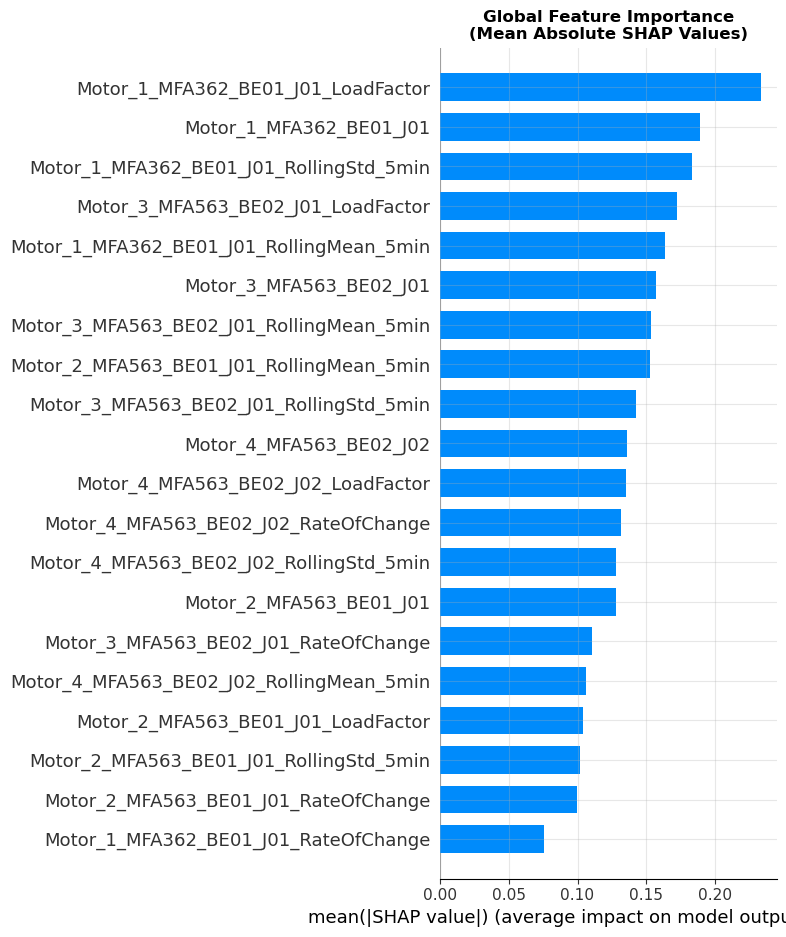

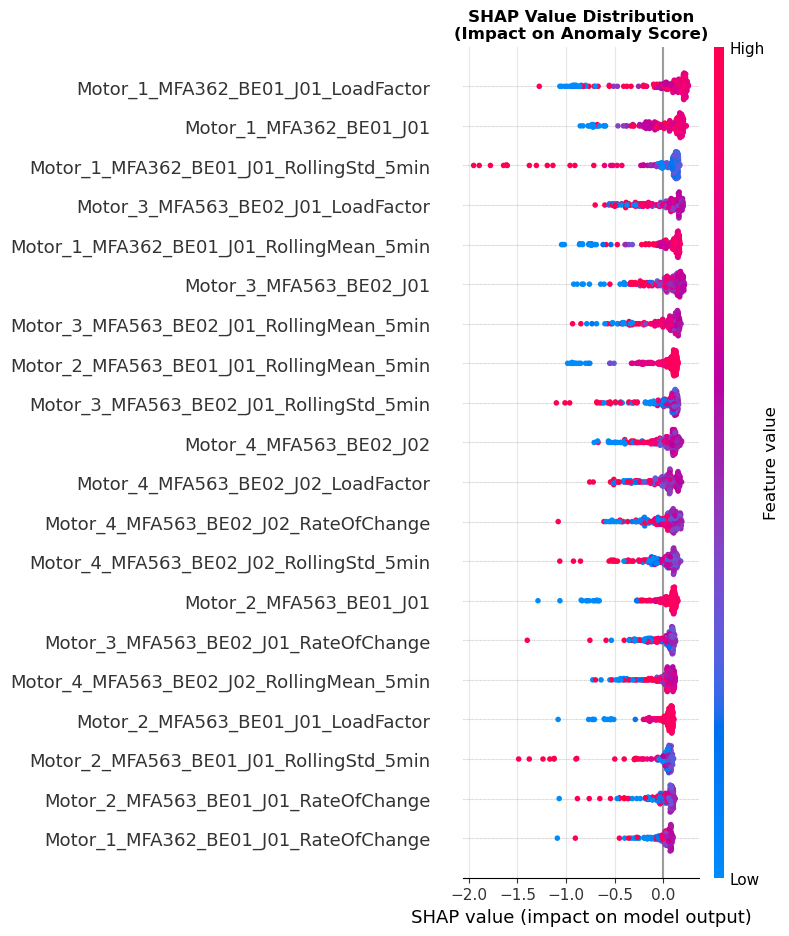

Global SHAP summary plots complete.


In [87]:
# Plot 1 — Bar chart (Global Feature Importance)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_scaled_df, 
    feature_names=feature_columns,
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance\n(Mean Absolute SHAP Values)', 
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2 — Dot/Beeswarm chart (SHAP Value Distribution)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_scaled_df,
    feature_names=feature_columns,
    plot_type='dot',
    show=False
)
plt.title('SHAP Value Distribution\n(Impact on Anomaly Score)', 
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("Global SHAP summary plots complete.")

In [76]:
anomaly_indices = cement_mill_ml_features[cement_mill_ml_features['IF_Final_Anomaly'] == 'ANOMALY'].index.tolist()

critical_high_indices = cement_mill_hybrid[
    cement_mill_hybrid['Hybrid_Severity_v2'].isin(['CRITICAL', 'HIGH'])
].index.tolist()

print("SHAP Local Explanation - Critical and High Severity Events")
print("=" * 80)

for idx in critical_high_indices[:5]:
    timestamp = cement_mill_hybrid.loc[idx, 'Timestamp']
    severity = cement_mill_hybrid.loc[idx, 'Hybrid_Severity_v2']
    hybrid_score = cement_mill_hybrid.loc[idx, 'Hybrid_Score_v2']
    if_score = cement_mill_hybrid.loc[idx, 'IF_Score']
    
    sample_shap = shap_df.loc[idx, feature_columns].values
    
    shap_contribution = pd.DataFrame({
        'Feature': feature_columns,
        'SHAP_Value': sample_shap,
        'Abs_SHAP': np.abs(sample_shap)
    }).sort_values('Abs_SHAP', ascending=False)
    
    print(f"\n{'='*80}")
    print(f"Timestamp    : {timestamp}")
    print(f"Severity     : {severity}")
    print(f"Hybrid Score : {hybrid_score:.4f}")
    print(f"IF Score     : {if_score:.4f}")
    print(f"\nTop 5 Contributing Features:")
    for _, row in shap_contribution.head(5).iterrows():
        direction = 'INCREASES anomaly' if row['SHAP_Value'] > 0 else 'DECREASES anomaly'
        print(f"  {row['Feature']:45s}: {row['SHAP_Value']:+.6f} ({direction})")

SHAP Local Explanation - Critical and High Severity Events

Timestamp    : 2026-05-04 12:53:00
Severity     : HIGH
Hybrid Score : 0.5016
IF Score     : 0.6146

Top 5 Contributing Features:
  Motor_4_MFA563_BE02_J02_LoadFactor           : -0.757040 (DECREASES anomaly)
  Motor_3_MFA563_BE02_J01_LoadFactor           : -0.700580 (DECREASES anomaly)
  Motor_4_MFA563_BE02_J02                      : -0.670901 (DECREASES anomaly)
  Motor_3_MFA563_BE02_J01_RateOfChange         : -0.588590 (DECREASES anomaly)
  Motor_3_MFA563_BE02_J01                      : -0.549081 (DECREASES anomaly)

Timestamp    : 2026-05-04 13:30:00
Severity     : HIGH
Hybrid Score : 0.5036
IF Score     : 0.7706

Top 5 Contributing Features:
  Motor_2_MFA563_BE01_J01_RollingMean_5min     : -0.933031 (DECREASES anomaly)
  Motor_2_MFA563_BE01_J01                      : -0.785321 (DECREASES anomaly)
  Motor_2_MFA563_BE01_J01_LoadFactor           : -0.607445 (DECREASES anomaly)
  Motor_4_MFA563_BE02_J02                      : 

In [77]:
def explain_load_factor_violation(motor_name, status, load_factor, rated_power, actual_power):
    explanations = []
    
    if status == 'CRITICAL_OVERLOAD':
        explanations.append(
            f"{motor_name} is operating at {load_factor:.1f}% of its rated capacity "
            f"({actual_power:.2f} kW actual vs {rated_power} kW rated). "
            f"This exceeds the 105% critical overload threshold. "
            f"Sustained operation at this level risks motor burnout and insulation failure."
        )
    elif status == 'OVERLOAD_ALERT':
        explanations.append(
            f"{motor_name} is operating at {load_factor:.1f}% of its rated capacity "
            f"({actual_power:.2f} kW actual vs {rated_power} kW rated). "
            f"This exceeds the 100% rated limit. "
            f"Immediate load reduction is recommended to prevent thermal damage."
        )
    elif status == 'HIGH_LOAD_WARNING':
        explanations.append(
            f"{motor_name} is operating at {load_factor:.1f}% of its rated capacity "
            f"({actual_power:.2f} kW actual vs {rated_power} kW rated). "
            f"Operating above 95% rated power. Monitor closely for further increase."
        )
    elif status == 'LOW_LOAD_WARNING':
        explanations.append(
            f"{motor_name} is drawing only {load_factor:.1f}% of its rated capacity "
            f"({actual_power:.2f} kW actual vs {rated_power} kW rated). "
            f"Abnormally low power draw. Possible causes: belt slip, material shortage, "
            f"or partial mechanical failure."
        )
    elif status == 'CRITICAL_UNDERLOAD':
        explanations.append(
            f"{motor_name} is drawing only {load_factor:.1f}% of its rated capacity "
            f"({actual_power:.2f} kW actual vs {rated_power} kW rated). "
            f"Critically low power draw. Motor may be running empty or belt may have failed."
        )
    elif status == 'MOTOR_STOPPED':
        explanations.append(
            f"{motor_name} is reading zero power ({actual_power:.2f} kW). "
            f"Motor appears to be stopped or sensor has failed. "
            f"Immediate physical inspection required."
        )
    elif status == 'SENSOR_DROPOUT':
        explanations.append(
            f"{motor_name} has no power reading available (sensor dropout). "
            f"Communication failure or sensor malfunction detected. "
            f"Verify sensor connection and data historian integrity."
        )
    
    return explanations

def explain_spc_violation(motor_name, spc_status, z_score, mean_power, std_power, actual_power):
    explanations = []
    
    if spc_status == 'OUT_OF_CONTROL_3SIGMA':
        direction = 'above' if actual_power > mean_power else 'below'
        explanations.append(
            f"{motor_name} has exceeded the 3-sigma statistical control limit "
            f"(Z-score: {z_score:.2f}). "
            f"Current power {actual_power:.2f} kW is {direction} the process mean of {mean_power:.2f} kW "
            f"by more than 3 standard deviations ({std_power:.2f} kW). "
            f"Statistical probability of this occurring by chance: less than 0.3%."
        )
    elif spc_status == 'WARNING_2SIGMA':
        direction = 'above' if actual_power > mean_power else 'below'
        explanations.append(
            f"{motor_name} has entered the 2-sigma warning zone "
            f"(Z-score: {z_score:.2f}). "
            f"Current power {actual_power:.2f} kW is {direction} the process mean of {mean_power:.2f} kW. "
            f"Statistical probability of this occurring by chance: less than 5%."
        )
    
    return explanations

def explain_if_anomaly(shap_contributions, top_n=3):
    explanations = []
    
    top_features = shap_contributions.head(top_n)
    
    for _, row in top_features.iterrows():
        feature = row['Feature']
        shap_val = row['SHAP_Value']
        
        motor_match = [m for m in motor_cols if m in feature]
        if not motor_match:
            continue
        motor = motor_match[0]
        
        if 'RateOfChange' in feature:
            direction = 'sudden increase' if shap_val > 0 else 'sudden decrease'
            explanations.append(
                f"Multivariate analysis detected a {direction} in power consumption "
                f"on {motor} that deviates from the learned normal pattern."
            )
        elif 'RollingMean' in feature:
            direction = 'elevated' if shap_val > 0 else 'depressed'
            explanations.append(
                f"The 5-minute rolling average power on {motor} is {direction} "
                f"compared to historical normal behavior across all motors."
            )
        elif 'RollingStd' in feature:
            direction = 'high' if shap_val > 0 else 'low'
            explanations.append(
                f"Power consumption volatility on {motor} is unusually {direction}, "
                f"indicating unstable or erratic motor behavior."
            )
        elif 'LoadFactor' in feature:
            direction = 'overloaded' if shap_val > 0 else 'underloaded'
            explanations.append(
                f"The load factor pattern on {motor} is {direction} "
                f"relative to the normal operating profile learned from historical data."
            )
        else:
            direction = 'higher' if shap_val > 0 else 'lower'
            explanations.append(
                f"Raw power consumption on {motor} is significantly {direction} "
                f"than the normal multivariate operating envelope."
            )
    
    return explanations

def generate_recommendation(severity, lf_statuses, spc_violations, if_anomaly):
    recommendations = []
    
    if severity == 'CRITICAL':
        recommendations.append(
            "IMMEDIATE ACTION REQUIRED: Dispatch maintenance team to inspect "
            "affected equipment without delay."
        )
    elif severity == 'HIGH':
        recommendations.append(
            "URGENT: Schedule maintenance inspection within the current shift. "
            "Increase monitoring frequency."
        )
    elif severity == 'MEDIUM':
        recommendations.append(
            "ADVISORY: Schedule inspection at next available maintenance window. "
            "Continue monitoring."
        )
    elif severity == 'LOW':
        recommendations.append(
            "MONITOR: Log this event and track trend. No immediate action required "
            "unless condition persists or worsens."
        )
    
    for motor in motor_cols:
        status = lf_statuses.get(motor, 'NORMAL')
        
        if status in ['CRITICAL_OVERLOAD', 'OVERLOAD_ALERT']:
            recommendations.append(
                f"Reduce load on {motor} immediately. Check for material blockage, "
                f"belt tension, and bearing condition."
            )
        elif status == 'MOTOR_STOPPED':
            recommendations.append(
                f"Physically inspect {motor}. Check motor starter, circuit breaker, "
                f"and control panel for trip indication."
            )
        elif status == 'SENSOR_DROPOUT':
            recommendations.append(
                f"Check sensor wiring and communication for {motor}. "
                f"Verify data historian connection. Replace sensor if fault persists."
            )
        elif status in ['CRITICAL_UNDERLOAD', 'LOW_LOAD_WARNING']:
            recommendations.append(
                f"Inspect {motor} for belt slip, empty bucket condition, "
                f"or upstream material feed interruption."
            )
    
    return recommendations

print("Rule-based explanation engine built successfully.")
print(f"Functions defined:")
print(f"  explain_load_factor_violation()")
print(f"  explain_spc_violation()")
print(f"  explain_if_anomaly()")
print(f"  generate_recommendation()")

Rule-based explanation engine built successfully.
Functions defined:
  explain_load_factor_violation()
  explain_spc_violation()
  explain_if_anomaly()
  generate_recommendation()


In [84]:
def generate_full_explanation(idx, df_hybrid, df_spc, shap_df, 
                               spc_summary, feature_columns, motor_cols,
                               rated_powers, motor_config):
    
    timestamp = cement_mill_hybrid.loc[idx, 'Timestamp']
    severity = cement_mill_hybrid.loc[idx, 'Hybrid_Severity_v2']
    hybrid_score = cement_mill_hybrid.loc[idx, 'Hybrid_Score_v2']
    if_score = cement_mill_hybrid.loc[idx, 'IF_Score']
    lf_score = cement_mill_hybrid.loc[idx, 'LF_Score_v2']
    spc_score = cement_mill_hybrid.loc[idx, 'SPC_Score']
    if_anomaly = cement_mill_hybrid.loc[idx, 'IF_Final_Anomaly']
    
    explanation_report = {
        'timestamp': timestamp,
        'severity': severity,
        'hybrid_score': hybrid_score,
        'component_scores': {
            'isolation_forest': if_score,
            'load_factor': lf_score,
            'statistical_process_control': spc_score
        },
        'motor_readings': {},
        'lf_explanations': [],
        'spc_explanations': [],
        'if_explanations': [],
        'recommendations': [],
        'summary': ''
    }
    
    lf_statuses = {}
    for motor in motor_cols:
        actual_power = cement_mill_hybrid.loc[idx, motor]
        rated_power = rated_powers[motor]
        load_factor = cement_mill_hybrid.loc[idx, f'{motor}_LoadFactor']
        status = cement_mill_hybrid.loc[idx, f'{motor}_Status']
        spc_status = cement_mill_spc.loc[idx, f'{motor}_SPC_Violation']
        z_score = cement_mill_spc.loc[idx, f'{motor}_ZScore']
        mean_power = spc_summary[motor]['mean']
        std_power = spc_summary[motor]['std']
        
        lf_statuses[motor] = status
        
        explanation_report['motor_readings'][motor] = {
            'actual_power_kw': round(actual_power, 4),
            'rated_power_kw': rated_power,
            'load_factor_pct': round(load_factor, 2),
            'status': status,
            'spc_status': spc_status,
            'z_score': round(z_score, 4)
        }
        
        lf_expl = explain_load_factor_violation(
            motor, status, load_factor, rated_power, actual_power
        )
        explanation_report['lf_explanations'].extend(lf_expl)
        
        spc_expl = explain_spc_violation(
            motor, spc_status, z_score, mean_power, std_power, actual_power
        )
        explanation_report['spc_explanations'].extend(spc_expl)
    
    if if_anomaly == 'ANOMALY':
        sample_shap = shap_df.loc[idx, feature_columns].values
        shap_contribution = pd.DataFrame({
            'Feature': feature_columns,
            'SHAP_Value': sample_shap,
            'Abs_SHAP': np.abs(sample_shap)
        }).sort_values('Abs_SHAP', ascending=False)
        
        if_expl = explain_if_anomaly(shap_contribution, top_n=3)
        explanation_report['if_explanations'].extend(if_expl)
    
    recommendations = generate_recommendation(
        severity, lf_statuses, 
        {m: df_spc.loc[idx, f'{m}_SPC_Violation'] for m in motor_cols},
        if_anomaly
    )
    explanation_report['recommendations'] = recommendations
    
    active_issues = []
    for motor in motor_cols:
        status = lf_statuses[motor]
        if status not in ['NORMAL']:
            active_issues.append(f"{motor} ({status})")
    
    if active_issues:
        explanation_report['summary'] = (
            f"At {timestamp.strftime('%H:%M on %d %b %Y')}, a {severity} severity anomaly "
            f"was detected with a composite score of {hybrid_score:.4f}. "
            f"Affected motors: {', '.join(active_issues)}. "
            f"Detection confidence: IF={if_score:.2f}, "
            f"Load Factor={lf_score:.2f}, SPC={spc_score:.2f}."
        )
    else:
        explanation_report['summary'] = (
            f"At {timestamp.strftime('%H:%M on %d %b %Y')}, a {severity} severity anomaly "
            f"was detected with a composite score of {hybrid_score:.4f} "
            f"based on multivariate pattern deviation. "
            f"Detection confidence: IF={if_score:.2f}, "
            f"Load Factor={lf_score:.2f}, SPC={spc_score:.2f}."
        )
    
    return explanation_report

def print_explanation_report(report):
    sep = "=" * 80
    thin_sep = "-" * 80
    
    print(sep)
    print(f"ANOMALY EXPLANATION REPORT")
    print(sep)
    print(f"Timestamp      : {report['timestamp']}")
    print(f"Severity Level : {report['severity']}")
    print(f"Composite Score: {report['hybrid_score']:.4f}")
    print(f"\nComponent Scores:")
    for component, score in report['component_scores'].items():
        print(f"  {component:35s}: {score:.4f}")
    
    print(f"\n{thin_sep}")
    print(f"MOTOR READINGS AT TIME OF EVENT")
    print(thin_sep)
    for motor, readings in report['motor_readings'].items():
        print(f"\n{motor}:")
        print(f"  Actual Power  : {readings['actual_power_kw']:.4f} kW")
        print(f"  Rated Power   : {readings['rated_power_kw']} kW")
        print(f"  Load Factor   : {readings['load_factor_pct']:.2f}%")
        print(f"  Status        : {readings['status']}")
        print(f"  SPC Status    : {readings['spc_status']}")
        print(f"  Z-Score       : {readings['z_score']:.4f}")
    
    print(f"\n{thin_sep}")
    print(f"SUMMARY")
    print(thin_sep)
    print(report['summary'])
    
    if report['lf_explanations']:
        print(f"\n{thin_sep}")
        print(f"ENGINEERING THRESHOLD ANALYSIS")
        print(thin_sep)
        for i, expl in enumerate(report['lf_explanations'], 1):
            print(f"\n[{i}] {expl}")
    
    if report['spc_explanations']:
        print(f"\n{thin_sep}")
        print(f"STATISTICAL PROCESS CONTROL ANALYSIS")
        print(thin_sep)
        for i, expl in enumerate(report['spc_explanations'], 1):
            print(f"\n[{i}] {expl}")
    
    if report['if_explanations']:
        print(f"\n{thin_sep}")
        print(f"MULTIVARIATE PATTERN ANALYSIS (ISOLATION FOREST)")
        print(thin_sep)
        for i, expl in enumerate(report['if_explanations'], 1):
            print(f"\n[{i}] {expl}")
    
    print(f"\n{thin_sep}")
    print(f"MAINTENANCE RECOMMENDATIONS")
    print(thin_sep)
    for i, rec in enumerate(report['recommendations'], 1):
        print(f"\n[{i}] {rec}")
    
    print(f"\n{sep}")

print("Generating full explanation reports for all CRITICAL and HIGH severity events...")
print("=" * 80)

critical_high_idx = cement_mill_hybrid[
    cement_mill_hybrid['Hybrid_Severity_v2'].isin(['CRITICAL', 'HIGH'])
].index.tolist()

all_reports = {}

for idx in critical_high_idx:
    report = generate_full_explanation(
        idx, cement_mill_hybrid, cement_mill_spc, shap_df,
        spc_summary, feature_columns, motor_cols,
        rated_powers, motor_config
    )
    all_reports[idx] = report
    print_explanation_report(report)
    print("\n")

Generating full explanation reports for all CRITICAL and HIGH severity events...
ANOMALY EXPLANATION REPORT
Timestamp      : 2026-05-04 12:53:00
Severity Level : HIGH
Composite Score: 0.5016

Component Scores:
  isolation_forest                   : 0.6146
  load_factor                        : 0.5000
  statistical_process_control        : 0.2500

--------------------------------------------------------------------------------
MOTOR READINGS AT TIME OF EVENT
--------------------------------------------------------------------------------

Motor_1_MFA362_BE01_J01:
  Actual Power  : 15.6160 kW
  Rated Power   : 24 kW
  Load Factor   : 65.07%
  Status        : NORMAL
  SPC Status    : IN_CONTROL
  Z-Score       : 0.5834

Motor_2_MFA563_BE01_J01:
  Actual Power  : 38.6560 kW
  Rated Power   : 40 kW
  Load Factor   : 96.64%
  Status        : HIGH_LOAD_WARNING
  SPC Status    : IN_CONTROL
  Z-Score       : 0.2935

Motor_3_MFA563_BE02_J01:
  Actual Power  : 84.9920 kW
  Rated Power   : 81 kW
 

In [110]:
def explain_if_anomaly_v2(shap_contributions, cement_mill_hybrid_row, motor_cols, 
                           rated_powers, top_n=3):
    explanations = []
    
    top_features = shap_contributions.head(top_n)
    
    for _, row in top_features.iterrows():
        feature = row['Feature']
        shap_val = row['SHAP_Value']
        
        motor_match = [m for m in motor_cols if m in feature]
        if not motor_match:
            continue
        motor = motor_match[0]
        
        actual_power = cement_mill_hybrid_row[motor]
        rated_power = rated_powers[motor]
        load_factor = (actual_power / rated_power * 100) if rated_power > 0 else 0
        
        if 'RateOfChange' in feature:
            roc_value = cement_mill_hybrid_row.get(f'{motor}_RateOfChange', 0)
            if roc_value is None:
                roc_value = 0
            direction = 'sudden surge' if roc_value > 0 else 'sudden drop'
            magnitude = abs(roc_value) if roc_value else 0
            explanations.append(
                f"Multivariate analysis detected a {direction} of {magnitude:.2f} kW/min "
                f"on {motor}, which deviates significantly from the learned normal "
                f"rate of change pattern."
            )
        elif 'RollingMean' in feature:
            if load_factor > 100:
                condition = f"elevated (currently at {load_factor:.1f}% of rated power)"
            elif load_factor < 40:
                condition = f"severely depressed (currently at {load_factor:.1f}% of rated power)"
            elif actual_power == 0:
                condition = "absent (zero reading detected)"
            else:
                condition = f"abnormal (currently at {load_factor:.1f}% of rated power)"
            explanations.append(
                f"The 5-minute rolling average power trend on {motor} is {condition}, "
                f"deviating from historical normal operating behavior."
            )
        elif 'RollingStd' in feature:
            rolling_std = cement_mill_hybrid_row.get(f'{motor}_RollingStd_5min', 0)
            if rolling_std and rolling_std > 2.0:
                volatility = 'unusually high'
                interpretation = 'suggesting erratic or unstable operation'
            else:
                volatility = 'unusually low'
                interpretation = 'suggesting abnormally steady operation during a dynamic event'
            explanations.append(
                f"Power consumption volatility on {motor} is {volatility} "
                f"({rolling_std:.2f} kW std dev over 5 minutes), {interpretation}."
            )
        elif 'LoadFactor' in feature:
            if load_factor > 105:
                condition = f'critically overloaded at {load_factor:.1f}% of rated capacity'
            elif load_factor > 100:
                condition = f'overloaded at {load_factor:.1f}% of rated capacity'
            elif load_factor > 95:
                condition = f'near rated limit at {load_factor:.1f}% of rated capacity'
            elif load_factor < 20:
                condition = f'critically underloaded at {load_factor:.1f}% of rated capacity'
            elif load_factor < 40:
                condition = f'severely underloaded at {load_factor:.1f}% of rated capacity'
            elif actual_power == 0:
                condition = 'at zero (motor stopped or sensor failure)'
            else:
                condition = f'outside normal operating range at {load_factor:.1f}%'
            explanations.append(
                f"Load factor analysis on {motor} is {condition}. "
                f"This pattern is inconsistent with normal multivariate operating behavior "
                f"learned from historical data."
            )
        else:
            if actual_power == 0:
                condition = 'zero (motor stopped or sensor failure)'
            elif load_factor > 100:
                condition = f'{actual_power:.2f} kW ({load_factor:.1f}% of rated - overloaded)'
            elif load_factor < 40:
                condition = f'{actual_power:.2f} kW ({load_factor:.1f}% of rated - severely underloaded)'
            else:
                condition = f'{actual_power:.2f} kW ({load_factor:.1f}% of rated)'
            explanations.append(
                f"Raw power consumption on {motor} is {condition}, "
                f"which falls outside the normal multivariate operating envelope "
                f"established from historical data."
            )
    
    return explanations


import pandas as pd
import numpy as np

def generate_full_explanation_v2(idx, cement_mill_hybrid, cement_mill_spc, shap_df,
                                  spc_summary, feature_columns, motor_cols,
                                  rated_powers, motor_config):
    
    timestamp = cement_mill_hybrid.loc[idx, 'Timestamp']
    severity = cement_mill_hybrid.loc[idx, 'Hybrid_Severity_v2']
    hybrid_score = cement_mill_hybrid.loc[idx, 'Hybrid_Score_v2']
    if_score = cement_mill_hybrid.loc[idx, 'IF_Score']
    lf_score = cement_mill_hybrid.loc[idx, 'LF_Score_v2']
    spc_score = cement_mill_hybrid.loc[idx, 'SPC_Score']
    if_anomaly = cement_mill_hybrid.loc[idx, 'IF_Final_Anomaly']
    
    explanation_report = {
        'timestamp': timestamp,
        'severity': severity,
        'hybrid_score': hybrid_score,
        'component_scores': {
            'isolation_forest': if_score,
            'load_factor': lf_score,
            'statistical_process_control': spc_score
        },
        'motor_readings': {},
        'lf_explanations': [],
        'spc_explanations': [],
        'if_explanations': [],
        'recommendations': [],
        'summary': ''
    }
    
    lf_statuses = {}
    for motor in motor_cols:
        actual_power = cement_mill_hybrid.loc[idx, motor]
        rated_power = rated_powers[motor]
        
        if actual_power == 0 or pd.isna(actual_power) or rated_power == 0:
            load_factor = None  # Use None to indicate not available
        else:
            load_factor = (actual_power / rated_power) * 100
        
        status = cement_mill_hybrid.loc[idx, f'{motor}_Status']
        spc_status = cement_mill_spc.loc[idx, f'{motor}_SPC_Violation']
        z_score = cement_mill_spc.loc[idx, f'{motor}_ZScore']
        mean_power = spc_summary[motor]['mean']
        std_power = spc_summary[motor]['std']
        
        lf_statuses[motor] = status
        
        explanation_report['motor_readings'][motor] = {
            'actual_power_kw': round(float(actual_power), 4) if not pd.isna(actual_power) else None,
            'rated_power_kw': rated_power,
            'load_factor_pct': load_factor,
            'status': status,
            'spc_status': spc_status,
            'z_score': round(float(z_score), 4) if not pd.isna(z_score) else None
        }
        
        lf_expl = explain_load_factor_violation(
            motor, status, load_factor if load_factor is not None else 0, rated_power, actual_power
        )
        explanation_report['lf_explanations'].extend(lf_expl)
        
        spc_expl = explain_spc_violation(
            motor, spc_status, z_score, mean_power, std_power, actual_power
        )
        explanation_report['spc_explanations'].extend(spc_expl)
    
    if if_anomaly == 'ANOMALY':
        sample_shap = shap_df.loc[idx, feature_columns].values
        shap_contribution = pd.DataFrame({
            'Feature': feature_columns,
            'SHAP_Value': sample_shap,
            'Abs_SHAP': np.abs(sample_shap)
        }).sort_values('Abs_SHAP', ascending=False)
        
        cement_mill_hybrid_row = cement_mill_hybrid.loc[idx]
        if_expl = explain_if_anomaly_v2(
            shap_contribution, cement_mill_hybrid_row, motor_cols, rated_powers, top_n=3
        )
        explanation_report['if_explanations'].extend(if_expl)
    
    recommendations = generate_recommendation(
        severity, lf_statuses,
        {m: cement_mill_spc.loc[idx, f'{m}_SPC_Violation'] for m in motor_cols},
        if_anomaly
    )
    explanation_report['recommendations'] = recommendations
    
    active_issues = []
    for motor in motor_cols:
        status = lf_statuses[motor]
        if status != 'NORMAL':
            active_issues.append(f"{motor} ({status})")
    
    if active_issues:
        explanation_report['summary'] = (
            f"At {timestamp.strftime('%H:%M on %d %b %Y')}, a {severity} severity anomaly "
            f"was detected with a composite score of {hybrid_score:.4f}. "
            f"Affected motors: {', '.join(active_issues)}. "
            f"Detection confidence: IF={if_score:.2f}, "
            f"Load Factor={lf_score:.2f}, SPC={spc_score:.2f}."
        )
    else:
        explanation_report['summary'] = (
            f"At {timestamp.strftime('%H:%M on %d %b %Y')}, a {severity} severity anomaly "
            f"was detected with a composite score of {hybrid_score:.4f} "
            f"based on multivariate pattern deviation. "
            f"Detection confidence: IF={if_score:.2f}, "
            f"Load Factor={lf_score:.2f}, SPC={spc_score:.2f}."
        )
    
    return explanation_report

def print_explanation_report(report):
    print("=" * 79)
    print("ANOMALY EXPLANATION REPORT")
    print("=" * 79)
    
    print(f"Timestamp      : {report['timestamp']}")
    print(f"Severity Level : {report['severity']}")
    print(f"Composite Score: {report['hybrid_score']:.4f}\n")
    
    print("Component Scores:")
    for k, v in report['component_scores'].items():
        print(f"  {k:<30} : {v:.4f}")
    print("\n" + "-"*75)
    
    print("MOTOR READINGS AT TIME OF EVENT")
    print("-"*75)
    
    for motor, readings in report['motor_readings'].items():
        print(f"\n{motor}:")
        actual_power = readings['actual_power_kw']
        rated_power = readings['rated_power_kw']
        load_factor = readings['load_factor_pct']  # this is float or None
        
        actual_power_str = f"{actual_power:.4f} kW" if actual_power is not None else "N/A"
        rated_power_str = f"{rated_power} kW" if rated_power is not None else "N/A"
        if load_factor is None:
            load_factor_str = "N/A"
        else:
            load_factor_str = f"{load_factor:.2f}%"
        
        print(f"  Actual Power  : {actual_power_str}")
        print(f"  Rated Power   : {rated_power_str}")
        print(f"  Load Factor   : {load_factor_str}")
        print(f"  Status        : {readings['status']}")
        print(f"  SPC Status    : {readings['spc_status']}")
    
    # ... print other parts of the report as needed ...

print("Regenerating explanation reports with corrected SHAP direction logic...")
print("=" * 80)

critical_high_idx = cement_mill_hybrid[
    cement_mill_hybrid['Hybrid_Severity_v2'].isin(['CRITICAL', 'HIGH'])
].index.tolist()

all_reports_v2 = {}

for idx in critical_high_idx:
    report = generate_full_explanation_v2(
        idx, cement_mill_hybrid, cement_mill_spc, shap_df,
        spc_summary, feature_columns, motor_cols,
        rated_powers, motor_config
    )
    all_reports_v2[idx] = report
    print_explanation_report(report)
    print("\n")

print(f"\nTotal reports generated: {len(all_reports_v2)}")
print(f"CRITICAL events explained: {sum(1 for r in all_reports_v2.values() if r['severity'] == 'CRITICAL')}")
print(f"HIGH events explained: {sum(1 for r in all_reports_v2.values() if r['severity'] == 'HIGH')}")

Regenerating explanation reports with corrected SHAP direction logic...
ANOMALY EXPLANATION REPORT
Timestamp      : 2026-05-04 12:53:00
Severity Level : HIGH
Composite Score: 0.5016

Component Scores:
  isolation_forest               : 0.6146
  load_factor                    : 0.5000
  statistical_process_control    : 0.2500

---------------------------------------------------------------------------
MOTOR READINGS AT TIME OF EVENT
---------------------------------------------------------------------------

Motor_1_MFA362_BE01_J01:
  Actual Power  : 15.6160 kW
  Rated Power   : 24 kW
  Load Factor   : 65.07%
  Status        : NORMAL
  SPC Status    : IN_CONTROL

Motor_2_MFA563_BE01_J01:
  Actual Power  : 38.6560 kW
  Rated Power   : 40 kW
  Load Factor   : 96.64%
  Status        : HIGH_LOAD_WARNING
  SPC Status    : IN_CONTROL

Motor_3_MFA563_BE02_J01:
  Actual Power  : 84.9920 kW
  Rated Power   : 81 kW
  Load Factor   : 104.93%
  Status        : OVERLOAD_ALERT
  SPC Status    : WARNI

In [121]:
# SAVING THE ISOLATION FOREST MODEL AND SPC PARAMETERS

import joblib
import json
import os

# Create a folder to save everything neatly
save_dir = "model_output_2"
os.makedirs(save_dir, exist_ok=True)

# Saving the Isolation Forest Model

joblib.dump(iso_forest_final, f"{save_dir}/isolation_forest_model.pkl")
print(f"Isolation Forest model saved")

# Saving the Scaler (MUST be saved alongside the model)
# Without this you cannot transform new data the same way

joblib.dump(scaler, f"{save_dir}/standard_scaler.pkl")
print(f"Standard scaler saved")

# Saving  the SPC Parameters (mean, std, control limits)
# Saved as JSON so it is human readable and easy to inspect

spc_to_save = {}

for motor in motor_cols:
    spc_to_save[motor] = {
        'mean'       : round(spc_summary[motor]['mean'], 6),
        'std'        : round(spc_summary[motor]['std'], 6),
        'ucl_3sigma' : round(spc_summary[motor]['ucl_3sigma'], 6),
        'lcl_3sigma' : round(spc_summary[motor]['lcl_3sigma'], 6),
        'ucl_2sigma' : round(spc_summary[motor]['ucl_2sigma'], 6),
        'lcl_2sigma' : round(spc_summary[motor]['lcl_2sigma'], 6)
    }

with open(f"{save_dir}/spc_parameters.json", 'w') as f:
    json.dump(spc_to_save, f, indent=4)

print(f"SPC parameters saved")

# Saving the Motor Configuration and Thresholds
# Saves rated powers and threshold percentages for reference

config_to_save = {
    'motor_config'     : {
        motor: {
            'rated_power_kw': config['rated_power_kw'],
            'description'   : config['description']
        }
        for motor, config in motor_config.items()
    },
    'threshold_config' : threshold_config,
    'feature_columns'  : feature_columns,
    'contamination_rate': optimal_contamination
}

with open(f"{save_dir}/model_config.json", 'w') as f:
    json.dump(config_to_save, f, indent=4)

print(f"Motor config and thresholds saved")

# Saving the Hybrid Scoring Weights


hybrid_config = {
    'weight_isolation_forest' : 0.45,
    'weight_load_factor'      : 0.35,
    'weight_spc'              : 0.20,
    'severity_thresholds'     : {
        'CRITICAL' : round(float(p98), 6),
        'HIGH'     : round(float(p95), 6),
        'MEDIUM'   : round(float(p88), 6),
        'LOW'      : round(float(p80), 6)
    }
}

with open(f"{save_dir}/hybrid_config.json", 'w') as f:
    json.dump(hybrid_config, f, indent=4)

print(f"Hybrid scoring weights saved")

# VERIFICATION — Confirm everything saved correctly

print(f"\n{'='*60}")
print(f"SAVE SUMMARY")
print(f"{'='*60}")
print(f"Save location: {os.path.abspath(save_dir)}")
print(f"\nFiles saved:")

for file in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{file}")
    print(f"  {file:45s} {size:>10,} bytes")

# VERIFICATION — Reload and test the model works correctly

print(f"\n{'='*60}")
print(f"RELOAD TEST — Verifying saved model works")
print(f"{'='*60}")

loaded_model  = joblib.load(f"{save_dir}/isolation_forest_model.pkl")
loaded_scaler = joblib.load(f"{save_dir}/standard_scaler.pkl")

with open(f"{save_dir}/spc_parameters.json", 'r') as f:
    loaded_spc = json.load(f)

# Run a quick prediction with the loaded model
X_test         = cement_mill_hybrid[feature_columns].fillna(0).values
X_test_scaled  = loaded_scaler.transform(X_test)
test_preds     = loaded_model.predict(X_test_scaled)
anomaly_count  = (test_preds == -1).sum()

print(f"\n Model reloaded and tested successfully")
print(f"   Anomalies detected on reload: {anomaly_count}")
print(f"   Should match original       : {(cement_mill_hybrid['IF_Final_Anomaly'] == 'ANOMALY').sum()}")
print(f"\n SPC parameters reloaded")
print(f"   Motors saved: {list(loaded_spc.keys())}")
print(f"\nAll files verified — model is ready for deployment")

Isolation Forest model saved
Standard scaler saved
SPC parameters saved
Motor config and thresholds saved
Hybrid scoring weights saved

SAVE SUMMARY
Save location: C:\Users\Lenovo\Desktop\Cement_mill_3\model_output_2

Files saved:
  hybrid_config.json                                   248 bytes
  isolation_forest_model.pkl                       987,017 bytes
  model_config.json                                  1,956 bytes
  spc_parameters.json                                  926 bytes
  standard_scaler.pkl                                1,095 bytes

RELOAD TEST — Verifying saved model works

 Model reloaded and tested successfully
   Anomalies detected on reload: 29
   Should match original       : 29

 SPC parameters reloaded
   Motors saved: ['Motor_1_MFA362_BE01_J01', 'Motor_2_MFA563_BE01_J01', 'Motor_3_MFA563_BE02_J01', 'Motor_4_MFA563_BE02_J02']

All files verified — model is ready for deployment
